In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/Operational_risk/modules')

In [ ]:
from typing import Union

import granger_analysis
import graphs
import hill_plot_new_patched

import recent_lag

import l1_l2_gpd_patched_new_catprune

#Total

In [ ]:
import numpy as np
import pandas as pd
from functools import reduce
from sklearn.preprocessing import MinMaxScaler
from scipy.optimize import minimize
from scipy.stats import genpareto
import copy

#############################################
# 1. 데이터 전처리
#############################################
# (1) 엑셀 파일 읽기 및 날짜 정리
# 실제 파일 경로로 수정하세요.
sasop_path = '/content/drive/MyDrive/sasop.xlsx'
# 손실 데이터 (미국 사건만 선택)
df1 = pd.read_excel(sasop_path)



In [ ]:
df=df1.copy()

In [ ]:
us_df = df[df['Country of Incident'] == 'United States']
loss_df = us_df[['First Year of Event','Industry Sector Code','Basel Business Line - Level 2','Event Risk Category','Loss Amount ($M)']].copy()
loss_df.rename(columns={'First Year of Event':'Date', 'Loss Amount ($M)':'Current Value of Loss'}, inplace=True)
loss_df['Date'] = pd.to_datetime(loss_df['Date']).dt.strftime('%Y')
loss_df.sort_values(by='Date', inplace=True)
loss_df = loss_df[loss_df['Date'] >= '1979']


In [ ]:
loss_df_finance=loss_df

In [ ]:
loss_df['Event Risk Category'].unique()

array(['Clients, Products & Business Practices',
       'Employment Practices and Workplace Safety',
       'Damage to Physical Assets', 'Internal Fraud', 'External Fraud',
       'Execution, Delivery & Process Management',
       'Business Disruption and System Failures'], dtype=object)

In [ ]:
loss_df_finance.rename(columns={"Basel Business Line - Level 2":"Business"},inplace=True)
loss_df_finance.drop(columns=['Industry Sector Code'],inplace=True)

In [ ]:
loss_df_finance['Business'].unique()

array(['Professional, Scientific and Technical Services',
       'Commercial Banking', 'Manufacturing',
       'Transportation and Warehousing',
       'Professional Liability/Fidelity Coverage', 'Construction',
       'Wholesale Trade', 'Retail Banking', 'Utilities',
       'Educational Services', 'Information', 'Private Banking',
       'Property and Casualty Insurance', 'Market Making',
       'Retail Brokerage', 'Mining', 'Arts, Entertainment and Recreation',
       'Life Insurance and Benefit Plans', 'Retail Trade',
       'Agriculture, Forestry, Fishing and Hunting', 'Corporate Trust',
       'Brokerage and Advisory', 'Discretionary Fund Management',
       'Other Services (except Public Administration)',
       'Health Care and Social Assistance',
       'Administrative and Support, Waste Management and Remediation Services',
       'Custody', 'Card Services', 'Real Estate, Rental and Leasing',
       'Non-Profit Organizations', 'Corporate Finance',
       'Accommodation and Foo

In [ ]:
import re
import pandas as pd

# 입력 컬럼
SOURCE_COL = 'Business'

def _norm(x):
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    # 정규화: & -> and, / -> space, -, , -> space, 괄호 제거, 다중공백 축소
    s = s.replace('&', ' and ')
    s = re.sub(r'[\/,\-]', ' ', s)
    s = re.sub(r'[\(\)\[\]]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    # 특수 케이스 보정
    s = s.replace('foodservices', 'food services')
    s = s.replace('non discretionary', 'non-discretionary')
    return s

# -------------------------------
# 1) 금융 도메인 상위 라인 매핑
# -------------------------------
FIN_MAP = {
    # Banking
    'retail banking': 'Banking',
    'commercial banking': 'Banking',
    'private banking': 'Banking',
    'card services': 'Banking',
    # Markets & Treasury
    'market making': 'Markets & Treasury',
    'sales': 'Markets & Treasury',
    'proprietary positions': 'Markets & Treasury',
    'treasury': 'Markets & Treasury',
    # Investment Banking
    'corporate finance': 'Investment Banking',
    'municipal government finance': 'Investment Banking',  # 슬래시 정규화 반영
    # Brokerage & Advisory
    'retail brokerage': 'Brokerage & Advisory',
    'brokerage and advisory': 'Brokerage & Advisory',
    'advisory services': 'Brokerage & Advisory',
    # Asset & Wealth Mgmt
    'discretionary fund management': 'Asset & Wealth Mgmt',
    'non-discretionary fund management': 'Asset & Wealth Mgmt',
    'merchant banking': 'Asset & Wealth Mgmt',
    # Asset Servicing & Trust
    'custody': 'Asset Servicing & Trust',
    'corporate trust': 'Asset Servicing & Trust',
    # Insurance
    'property and casualty insurance': 'Insurance',
    'life insurance and benefit plans': 'Insurance',
    'health insurance': 'Insurance',
    'reinsurance': 'Insurance',
    'corporate agency': 'Insurance',
    'professional liability fidelity coverage': 'Insurance',
    # Others
    'external clients': 'Others',
    'others': 'Others',
}

# -------------------------------
# 2) 비금융(NAICS류) 상위 그룹 매핑
# -------------------------------
NONFIN_MAP = {
    'manufacturing': 'Manufacturing',
    'construction': 'Construction',
    'utilities': 'Utilities',
    'mining': 'Mining',
    'retail trade': 'Retail Trade',
    'wholesale trade': 'Wholesale Trade',
    'transportation and warehousing': 'Transportation & Warehousing',
    'information': 'Information',
    'educational services': 'Educational Services',
    'health care and social assistance': 'Health Care & Social Assistance',
    'agriculture forestry fishing and hunting': 'Agriculture, Forestry, Fishing & Hunting',
    'real estate rental and leasing': 'Real Estate, Rental & Leasing',
    'accommodation and food services': 'Accommodation & Food Services',
    'arts entertainment and recreation': 'Arts, Entertainment & Recreation',
    'public administration': 'Public Administration',
    'professional scientific and technical services': 'Professional Services',
    'administrative and support waste management and remediation services': 'Admin & Support, Waste Mgmt',
    'management of companies and enterprises': 'Mgmt of Companies & Enterprises',
    'other services except public administration': 'Other Services',
    'non-profit organizations': 'Non-Profit',
}

# -------------------------------
# 3) 키워드 휴리스틱 (미지정 값 보조 분류)
# -------------------------------
def _heuristic_fin(key: str):
    if any(w in key for w in ['bank', 'card']):
        return 'Banking'
    if any(w in key for w in ['market making', 'treasury', 'proprietary', 'sales']):
        return 'Markets & Treasury'
    if any(w in key for w in ['broker', 'advisory']):
        return 'Brokerage & Advisory'
    if any(w in key for w in ['fund', 'asset', 'merchant banking', 'wealth']):
        return 'Asset & Wealth Mgmt'
    if any(w in key for w in ['custody', 'trust']):
        return 'Asset Servicing & Trust'
    if 'insurance' in key or 'reinsurance' in key or 'liability' in key:
        return 'Insurance'
    if 'finance' in key:
        return 'Investment Banking'
    return None

def _heuristic_nonfin(key: str):
    # 순서 중요(특정성이 높은 것부터)
    if 'retail trade' in key or (('retail' in key) and ('trade' in key)):
        return 'Retail Trade'
    if 'wholesale' in key:
        return 'Wholesale Trade'
    if 'manufactur' in key:
        return 'Manufacturing'
    if 'construction' in key:
        return 'Construction'
    if 'transportation' in key or 'warehousing' in key:
        return 'Transportation & Warehousing'
    if 'utilities' in key:
        return 'Utilities'
    if any(w in key for w in ['agriculture','forestry','fishing','hunting']):
        return 'Agriculture, Forestry, Fishing & Hunting'
    if 'information' in key:
        return 'Information'
    if 'educational' in key or 'education' in key:
        return 'Educational Services'
    if 'health care' in key or 'social assistance' in key or 'healthcare' in key:
        return 'Health Care & Social Assistance'
    if 'real estate' in key or 'rental' in key or 'leasing' in key:
        return 'Real Estate, Rental & Leasing'
    if 'accommodation' in key or 'food services' in key:
        return 'Accommodation & Food Services'
    if any(w in key for w in ['arts','entertainment','recreation']):
        return 'Arts, Entertainment & Recreation'
    if 'public administration' in key:
        return 'Public Administration'
    if 'professional scientific' in key or 'technical services' in key:
        return 'Professional Services'
    if 'administrative and support' in key or 'waste management' in key or 'remediation' in key:
        return 'Admin & Support, Waste Mgmt'
    if 'management of companies' in key:
        return 'Mgmt of Companies & Enterprises'
    if 'non profit' in key or 'nonprofit' in key:
        return 'Non-Profit'
    if 'other services' in key:
        return 'Other Services'
    return None

# -------------------------------
# 4) 최종 분류 함수
# -------------------------------
def classify_sector_and_line(val):
    key = _norm(val)
    if key is None or key == '':
        return pd.Series(['Unknown', 'Others'])

    # 1) 직접 매핑
    if key in FIN_MAP:
        return pd.Series(['Finance', FIN_MAP[key]])
    if key in NONFIN_MAP:
        return pd.Series(['Non-Finance', NONFIN_MAP[key]])

    # 2) 휴리스틱(금융 → 비금융 순서)
    fin_guess = _heuristic_fin(key)
    if fin_guess:
        return pd.Series(['Finance', fin_guess])
    nonfin_guess = _heuristic_nonfin(key)
    if nonfin_guess:
        return pd.Series(['Non-Finance', nonfin_guess])

    # 3) 최종 기본값
    return pd.Series(['Unknown', 'Others'])

# 적용: 두 컬럼 생성
loss_df_finance[['SectorType', 'Business_line']] = (
    loss_df_finance[SOURCE_COL].apply(classify_sector_and_line)
)


In [ ]:
loss_df_finance=loss_df_finance.drop(columns=['Business','SectorType'])

In [ ]:
# Encode 'Event Risk Category'
df_encoded_a = pd.get_dummies(loss_df_finance, columns=['Event Risk Category'], prefix='Category')

# Use the result of the first encoding as input for the second encoding
df_encoded_b = pd.get_dummies(df_encoded_a, columns=['Business_line'], prefix='Category')

# Final encoded DataFrame
loss_df_finance = df_encoded_b.copy()


In [ ]:
import re

# ① CSV 읽기
cpu = pd.read_csv('/content/drive/MyDrive/CPU index.csv')[['date', 'cpu_index']]

# ② 전처리 ── 공백 제거
cpu['date'] = cpu['date'].str.strip()

# ③ 'YY-Mon' → 'Mon-YY' 로 재배열
cpu['date'] = cpu['date'].str.replace(
    r'^(\d{2})-([A-Za-z]{3})$',   # 2자리 연도-3자리 월
    r'\2-\1',                     # 월-연도로 바꾸기
    regex=True, flags=re.IGNORECASE
)

# ④ datetime 파싱
cpu['date'] = pd.to_datetime(cpu['date'], format='%b-%y', errors='coerce')

# ⑤ 원하는 포맷(문자열)으로 출력하거나, 월 Period 로도 사용 가능
cpu['date'] = cpu['date'].dt.strftime('%Y-%m')      # 문자열 형태


In [ ]:
import pandas as pd
import numpy as np
from functools import reduce

file_paths = {
    "us_cpi": "/content/drive/MyDrive/us_cpi.csv",
    "us_unemp": "/content/drive/MyDrive/us_unemp.csv",
    "us_vix": "/content/drive/MyDrive/us_vix.csv",
    "us_m1": "/content/drive/MyDrive/us_m1.csv",
    "us_home_price": "/content/drive/MyDrive/us_home price index.csv",
    "us_T10Y2Y": "/content/drive/MyDrive/us_T10Y2Y.csv",
    "sp500": "/content/drive/MyDrive/sp500_monthly.csv",
}

# Load
us_cpi = pd.read_csv(file_paths["us_cpi"])
us_unemp = pd.read_csv(file_paths["us_unemp"])
us_m1 = pd.read_csv(file_paths["us_m1"])
us_home_price = pd.read_csv(file_paths["us_home_price"])
us_T10Y2Y = pd.read_csv(file_paths["us_T10Y2Y"])
sp500 = pd.read_csv(file_paths["sp500"], skiprows=2)

# Rename columns
us_T10Y2Y.rename(columns={'T10Y2Y': '10_2'}, inplace=True)
us_home_price.rename(columns={'USSTHPI': 'House Price Index'}, inplace=True)
us_m1.rename(columns={'WM1NS': 'M1'}, inplace=True)
us_cpi.rename(columns={'CPIAUCSL': 'CPI'}, inplace=True)
us_unemp.rename(columns={'UNRATE': 'Unemployment Rate'}, inplace=True)
sp500.rename(columns={'Unnamed: 1': 'Close'}, inplace=True)
sp500 = sp500.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4", "Unnamed: 5"])
cpu.rename(columns={'date': 'Date'}, inplace=True)


# Date 처리 및 연 단위 평균
for df in [us_cpi, us_unemp, us_m1, us_home_price, us_T10Y2Y, sp500,cpu]:
    df.rename(columns={df.columns[0]: "Date"}, inplace=True)
    df["Date"] = pd.to_datetime(df["Date"]).dt.year

us_T10Y2Y = us_T10Y2Y.groupby("Date").mean().reset_index()
us_home_price = us_home_price.groupby("Date").mean().reset_index()
us_m1 = us_m1.groupby("Date").mean().reset_index()
us_cpi = us_cpi.groupby("Date").mean().reset_index()
us_unemp = us_unemp.groupby("Date").mean().reset_index()
sp500 = sp500.groupby("Date").mean().reset_index()
cpu = cpu.groupby("Date").mean().reset_index()


# log-diff 처리
macro_dfs = {

    'Close_diff': (sp500, 'Close'),
}

# diff 열 추가
for diff_col, (df, col) in macro_dfs.items():
    df[diff_col] = np.log(df[col]).diff()

# sp500의 첫 번째 NaN만 특정 값으로 채움
sp500['Close_diff'].fillna(0.1635259493925565, inplace=True)

# 병합
dfs = [us_T10Y2Y, us_home_price, us_m1, us_cpi, us_unemp, sp500,cpu]
df_merged_macro = reduce(lambda left, right: pd.merge(left, right, on="Date", how="inner"), dfs)

# 최종 lag 데이터
df_merged_macro_lag = df_merged_macro[df_merged_macro["Date"] >= 1980].copy()
df_merged_macro_lag['Date'] = df_merged_macro_lag['Date'].astype(str)


/tmp/ipython-input-852055941.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sp500['Close_diff'].fillna(0.1635259493925565, inplace=True)


In [ ]:
import numpy as np
import pandas as pd
from functools import reduce
from sklearn.preprocessing import MinMaxScaler
from scipy.optimize import minimize
from scipy.stats import genpareto
import copy
#1986부터 사용
#############################################
# 1. 데이터 전처리 (연 단위)
#############################################
# (1) 엑셀 파일 읽기 및 날짜 정리
# 실제 파일 경로로 수정하세요.

epu_kr_path = '/content/drive/MyDrive/Korea_Overall_EPU.xlsx'
epu_kr_cat_path = '/content/drive/MyDrive/Korea_Categorical_PU_Indices.xlsx'
epu_usa_path = '/content/drive/MyDrive/US_Policy_Uncertainty_Data.xlsx'
epu_usa_cat_path = '/content/drive/MyDrive/Categorical_EPU_Data.xlsx'


# 미국 EPU 데이터
epu_usa = pd.read_excel(epu_usa_path)
epu_usa_cat = pd.read_excel(epu_usa_cat_path)
# 연도만 추출 (datetime 변환 후 정수형으로)
epu_usa['Year'] = pd.to_datetime(epu_usa['Year'], format='%Y').dt.year.astype(int)
epu_usa_cat['Year'] = pd.to_datetime(epu_usa_cat['Year'], format='%Y').dt.year.astype(int)
# 연도 필터링 (1985~2022)
epu_usa_cl = epu_usa[(epu_usa['Year'] < 2023)].copy()
epu_usa_cat_cl = epu_usa_cat[ (epu_usa_cat['Year'] < 2023)].copy()
# 최종적으로 'Date' 컬럼에 연도만(문자형) 저장
epu_usa_cl['Date'] = epu_usa_cl['Year'].astype(str)
epu_usa_cat_cl['Date'] = epu_usa_cat_cl['Year'].astype(str)
epu_usa_cl_lag = epu_usa_cl.copy()
epu_usa_cat_cl_lag = epu_usa_cat_cl.copy()


epu_usa_cl['Date'] = epu_usa_cl['Year'].astype(str)

epu_overall = (
    epu_usa_cl
    .groupby('Date')[['Three_Component_Index','News_Based_Policy_Uncert_Index']]
    .mean()
    .reset_index()
)

# 2) 범주형 EPU 연평균 집계
# ————————
cat_cols = [
    '1. Economic Policy Uncertainty','2. Monetary policy',
    'Fiscal Policy (Taxes OR Spending)','3. Taxes',
    '4. Government spending','5. Health care',
    '6. National security','7. Entitlement programs',
    '8. Regulation','Financial Regulation',
    '9. Trade policy','10. Sovereign debt, currency crises'
]
epu_usa_cat_cl['Date'] = epu_usa_cat_cl['Year'].astype(str)

epu_cats = (
    epu_usa_cat_cl
    .groupby('Date')[cat_cols]
    .mean()
    .reset_index()
)

# 3) 매크로 + EPU(전체+범주) 병합
# ———————————————
df_macro_epu = (
    df_merged_macro_lag
    .merge(epu_overall, on='Date', how='inner')
    .merge(epu_cats,    on='Date', how='inner')
)

# 4) 최종: 이벤트 손실(≈433행)과 1:1 병합
# ——————————————————————
final_df = df_macro_epu.merge(loss_df_finance, on='Date', how='inner')




In [ ]:
df_merged=final_df.copy()
df_merged['Exceedance']=df_merged['Current Value of Loss']

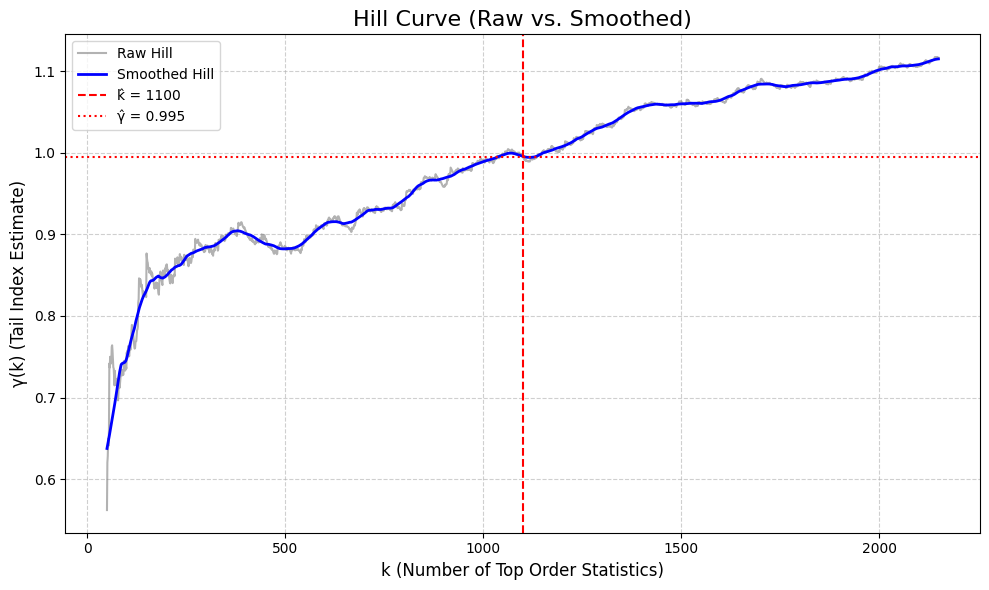

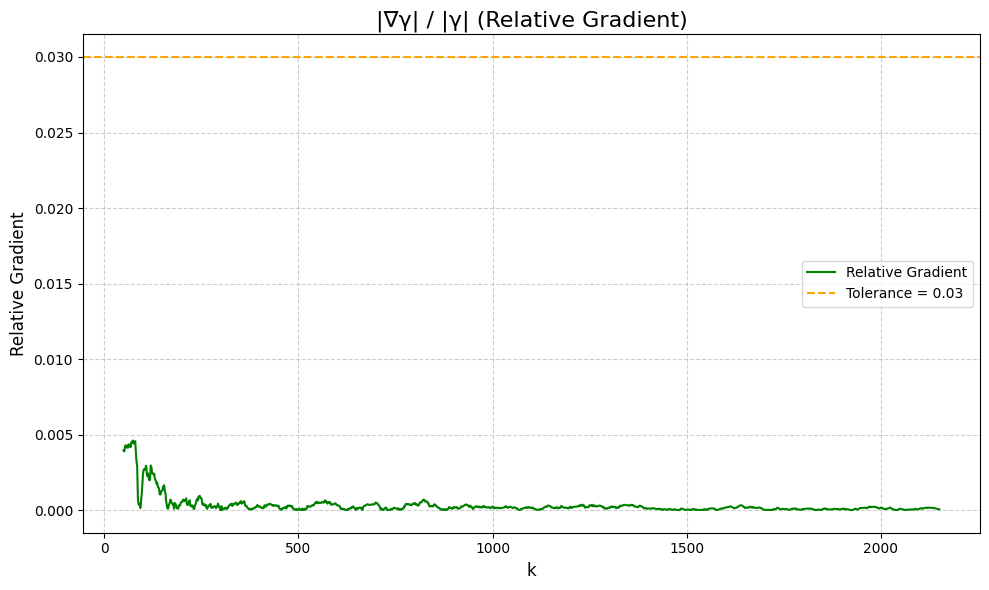

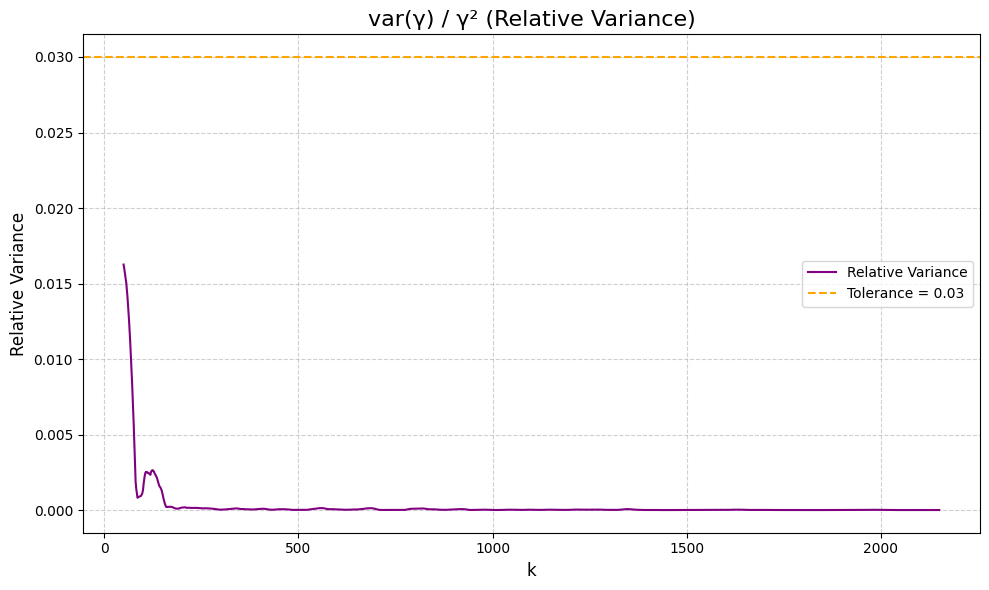

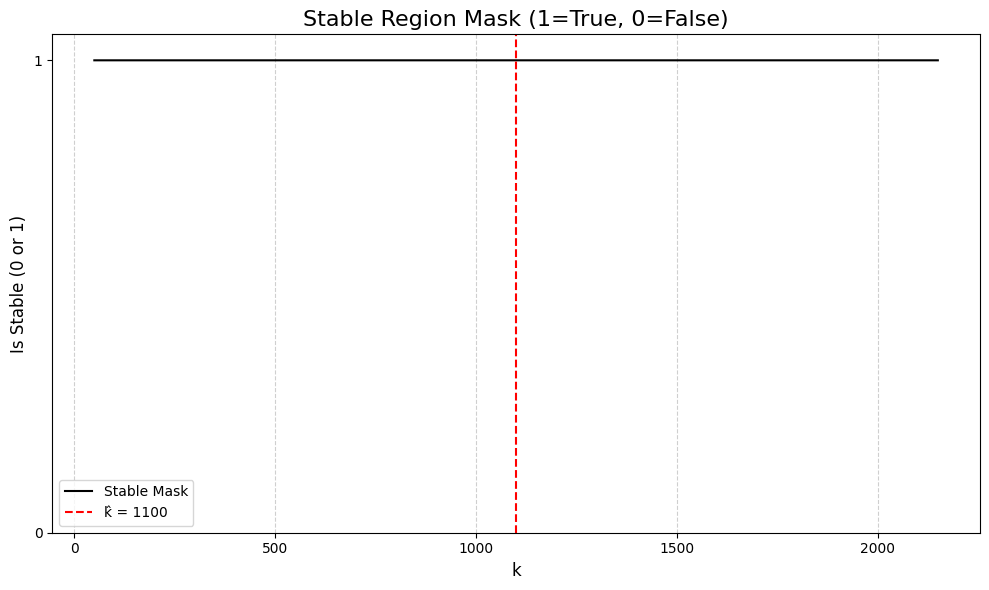


--- Results ---
Estimated Threshold (u_hat): 240.0430
Number of Exceedances (k_hat): 1100
Estimated Tail Index (gamma_hat): 0.9948
----------------


In [ ]:
# hill_plots.py ─────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple, Dict, Any

# It's assumed that the 'thresholding' module you created is in the same folder.
from hill_plot_new_patched import select_threshold, HillDiag

def _compute_hill_raw_curve(y: np.ndarray, ks: np.ndarray) -> np.ndarray:
    """
    Computes the raw (unsmoothed) Hill curve.
    γ_k = mean( log Y_(1..k) - log Y_(k+1) ), where Y are sorted positive values.
    """
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]
    y_desc = np.sort(y)[::-1]
    y_pos = y_desc[y_desc > 0]
    if y_pos.size < 2 or ks.size == 0: # Need at least 2 points to compute log-differences
        return np.array([])

    # Ensure k does not exceed valid index
    max_k = y_pos.size - 1
    valid_ks = ks[ks < max_k]
    if valid_ks.size == 0:
        return np.array([])

    return np.array([np.mean(np.log(y_pos[:k]) - np.log(y_pos[k])) for k in valid_ks], dtype=float)

def plot_hill_curve(
    y: np.ndarray,
    diag: HillDiag,
    k_hat: int,
    gamma_hat: float,
    *,
    title: str = "Hill Curve (Raw vs. Smoothed)",
) -> None:
    """
    Plots the Hill curve (raw vs. smoothed) and the estimated point (k_hat, gamma_hat).
    """
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot Hill curve.")
        return

    gamma_raw = _compute_hill_raw_curve(y, diag.k_grid)

    plt.figure(figsize=(10, 6))
    if gamma_raw.size:
        # Match raw curve to its valid k-grid
        max_k_raw = y.size - 1
        valid_ks_raw = diag.k_grid[diag.k_grid < max_k_raw]
        plt.plot(valid_ks_raw, gamma_raw, label="Raw Hill", alpha=0.6, color='gray')

    plt.plot(diag.k_grid, diag.gamma_hat, label="Smoothed Hill", color='blue', linewidth=2)
    plt.axvline(k_hat, linestyle="--", color='red', label=f"k̂ = {k_hat}")
    plt.axhline(gamma_hat, linestyle=":", color='red', label=f"γ̂ = {gamma_hat:.3f}")

    plt.title(title, fontsize=16)
    # CHANGED: Korean -> English
    plt.xlabel("k (Number of Top Order Statistics)", fontsize=12)
    plt.ylabel("γ(k) (Tail Index Estimate)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_grad_norm(
    diag: HillDiag,
    *,
    rel_grad_tol: float,
    title: str = "|∇γ| / |γ| (Relative Gradient)"
) -> None:
    """Plots the relative gradient and the tolerance line."""
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot grad_norm.")
        return

    plt.figure(figsize=(10, 6))
    plt.plot(diag.k_grid, diag.grad_norm, label="Relative Gradient", color='green')
    plt.axhline(rel_grad_tol, linestyle="--", color='orange', label=f"Tolerance = {rel_grad_tol}")
    plt.title(title, fontsize=16)
    plt.xlabel("k", fontsize=12)
    plt.ylabel("Relative Gradient", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_var_rel(
    diag: HillDiag,
    *,
    rel_var_tol: float,
    title: str = "var(γ) / γ² (Relative Variance)"
) -> None:
    """Plots the relative variance and the tolerance line."""
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot var_rel.")
        return

    plt.figure(figsize=(10, 6))
    plt.plot(diag.k_grid, diag.var_rel, label="Relative Variance", color='purple')
    plt.axhline(rel_var_tol, linestyle="--", color='orange', label=f"Tolerance = {rel_var_tol}")
    plt.title(title, fontsize=16)
    plt.xlabel("k", fontsize=12)
    plt.ylabel("Relative Variance", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_stable_mask(
    diag: HillDiag,
    *,
    rel_grad_tol: float,
    rel_var_tol: float,
    gamma_min: float,
    k_hat: int,
    title: str = "Stable Region Mask (1=True, 0=False)"
) -> None:
    """
    Visualizes the stable region mask:
    stable = (grad_norm < rel_grad_tol) & (var_rel < rel_var_tol) & (gamma_hat > gamma_min)
    """
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot stable mask.")
        return

    stable = (diag.grad_norm < rel_grad_tol) & (diag.var_rel < rel_var_tol) & (diag.gamma_hat > gamma_min)

    plt.figure(figsize=(10, 6))
    plt.step(diag.k_grid, stable.astype(int), where="mid", label="Stable Mask", color='black')
    plt.axvline(k_hat, linestyle="--", color='red', label=f"k̂ = {k_hat}")
    plt.title(title, fontsize=16)
    plt.xlabel("k", fontsize=12)
    plt.ylabel("Is Stable (0 or 1)", fontsize=12)
    plt.yticks([0, 1])
    plt.legend()
    plt.grid(True, axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_hill_diagnostics(
    y: np.ndarray,
    *,
    # Parameters for thresholding._auto_hill
    k_min: int = 50,
    k_max_prop: float = 0.1,
    window: int = 61,
    rel_grad_tol: float = 0.04,
    rel_var_tol: float = 0.03,
    gamma_min: float = 0.02,
    min_plateau_len: int = 10,
    plateau_strategy: str = "longest",
    min_excess: Optional[int] = None,
    max_excess: Optional[int] = None,
    # Optional titles for individual plots
    titles: Optional[Dict[str, str]] = None,
    # For passing extra args to select_threshold
    extra_hill_kwargs: Optional[Dict[str, Any]] = None,
) -> Tuple[float, int, float, HillDiag]:
    """
    In a single call, this function:
      1) Runs select_threshold to get (u_hat, k_hat, gamma_hat, diag).
      2) Generates separate plots for Hill curve, grad_norm, var_rel, and stable mask.

    Returns: (u_hat, k_hat, gamma_hat, diag)
    """
    if titles is None:
        titles = {}
    if extra_hill_kwargs is None:
        extra_hill_kwargs = {}

    # Call select_threshold requesting the diagnostic data
    u_hat, k_hat, gamma_hat, diag = select_threshold(
        y,
        return_diag=True,
        k_min=k_min,
        k_max_prop=k_max_prop,
        window=window,
        rel_grad_tol=rel_grad_tol,
        rel_var_tol=rel_var_tol,
        gamma_min=gamma_min,
        min_plateau_len=min_plateau_len,
        plateau_strategy=plateau_strategy,
        min_excess=min_excess,
        max_excess=max_excess,
        **extra_hill_kwargs,
    )

    # 1) Hill Curve
    plot_hill_curve(
        y, diag, k_hat, gamma_hat,
        title=titles.get("hill", "Hill Curve (Raw vs. Smoothed)")
    )

    # 2) grad_norm
    plot_grad_norm(
        diag,
        rel_grad_tol=rel_grad_tol,
        title=titles.get("grad", "|∇γ| / |γ| (Relative Gradient)")
    )

    # 3) var_rel
    plot_var_rel(
        diag,
        rel_var_tol=rel_var_tol,
        title=titles.get("var", "var(γ) / γ² (Relative Variance)")
    )

    # 4) stable mask
    plot_stable_mask(
        diag,
        rel_grad_tol=rel_grad_tol,
        rel_var_tol=rel_var_tol,
        gamma_min=gamma_min,
        k_hat=k_hat,
        title=titles.get("stable", "Stable Region Mask (1=True, 0=False)")
    )

    return u_hat, k_hat, gamma_hat, diag


if __name__ == "__main__":

    # Run the diagnostic plotting function
    u_hat, k_hat, gamma_hat, diag = plot_hill_diagnostics(
        df_merged['Exceedance'],
        k_min=50,
        k_max_prop=0.1, # Use a larger proportion for better visualization
        window=61,
        rel_grad_tol=0.03,
        rel_var_tol=0.03, # Loosen var tolerance slightly for demo
        gamma_min=0.02,
        min_plateau_len=20,
        plateau_strategy="longest",
    )

    print("\n--- Results ---")
    print(f"Estimated Threshold (u_hat): {u_hat:.4f}")
    print(f"Number of Exceedances (k_hat): {k_hat}")
    print(f"Estimated Tail Index (gamma_hat): {gamma_hat:.4f}")
    print("----------------")

In [ ]:
n = len(df_merged['Exceedance'])
top_percent = (k_hat / n) * 100
print(f"Top {top_percent:.2f}% of data exceed threshold {u_hat:.2f}")


Top 5.11% of data exceed threshold 240.04


#ADF

##Comparision

In [ ]:

df = df_merged.copy()

# 1) 연도 만들기
if not pd.api.types.is_integer_dtype(df['Date']):
    df['Year'] = pd.to_datetime(df['Date']).dt.year
else:
    df['Year'] = df['Date']

# 2) 대상/피처/카테고리 정의
target_col = 'Exceedance'  # 타깃은 연도 총합으로 집계
base_vars = ['10_2','House Price Index','M1','CPI','Unemployment Rate',
             'Close','Close_diff','Three_Component_Index',
             'News_Based_Policy_Uncert_Index','1. Economic Policy Uncertainty',
             '2. Monetary policy','Fiscal Policy (Taxes OR Spending)','3. Taxes',
             '4. Government spending','5. Health care','6. National security',
             '7. Entitlement programs','8. Regulation','Financial Regulation',
             '9. Trade policy','10. Sovereign debt, currency crises','cpu_index']

# 이미 차분된 컬럼(예: Close_diff)은 이중 차분 방지를 위해 제외 권장
base_vars_clean = [c for c in base_vars if c in df.columns and not c.endswith('_diff') and c != target_col]
cat_cols = [c for c in df.columns if c.startswith('Category_')]

# 3) 집계 규칙: 타깃=sum, 매크로(이미 연평균된 값)=first, 카테고리 더미=max
agg_dict = {
    target_col: 'sum',
    **{c: 'first' for c in base_vars_clean},
    **{c: 'max' for c in cat_cols}
}

# 4) 연도 단위로 집계 -> 정렬 -> 인덱스 리셋
df_year = (df.groupby('Year', as_index=False)
             .agg(agg_dict)
             .sort_values('Year')
             .reset_index(drop=True))

# 4-1) 연도별 사건 수(N_t) 계산 후 병합 (원하면 나중에 그랜저에 포함해서 테스트 가능)
cnt = df.groupby('Year').size().rename('N_t').reset_index()
df_year = df_year.merge(cnt, on='Year', how='left')

# 5) 타깃 안정화 (합은 스케일이 커서 log1p 권장; 음수 없을 때만)
if (df_year[target_col] >= 0).all():
    df_year[target_col] = np.log1p(df_year[target_col])

# 6) 숫자형 보정 및 결측 제거(Granger는 NaN 불가)
cols_to_numeric = [target_col] + base_vars_clean + cat_cols + ['N_t']
for col in cols_to_numeric:
    if col in df_year.columns:
        df_year[col] = pd.to_numeric(df_year[col], errors='coerce')

# 그랜저에 쓸 핵심 컬럼만 NaN 제거
df_granger = df_year.dropna(subset=[target_col] + base_vars_clean)

# 7) 그랜저 파이프라인 실행 (연 단위이므로 max_lag를 3으로 낮춤 권장)
res = granger_analysis.run_granger_analysis_pipeline(
    df_granger,
    base_vars=base_vars_clean,      # N_t도 원하면 base_vars에 추가해서 N_t→타깃 테스트 가능
    target_col=target_col,
    transform='auto',
    max_lag=3
)

summary_df = recent_lag.get_most_recent_granger_lags(
    granger_df=res,
    target_variable=target_col
)

print("--- 변수별 가장 빠른 유의미한 시차 (Lag) 요약 ---")
print(summary_df)


--- 1. Starting Analysis Pipeline ---

--- 2. Checking variable stationarity (ADF Test) ---
Stationary variables: ['10_2', '1. Economic Policy Uncertainty', '2. Monetary policy', 'Fiscal Policy (Taxes OR Spending)', '3. Taxes', '4. Government spending', '6. National security', '8. Regulation', '10. Sovereign debt, currency crises']
Non-stationary variables to be differenced: ['House Price Index', 'M1', 'CPI', 'Unemployment Rate', 'Close', 'Three_Component_Index', 'News_Based_Policy_Uncert_Index', '5. Health care', '7. Entitlement programs', 'Financial Regulation', '9. Trade policy', 'cpu_index', 'Exceedance']

--- 3. Applying 'auto' differencing ---

--- 4. Running Granger Causality Test on processed data ---
Base variables: ['10_2', 'House Price Index_diff', 'M1_diff', 'CPI_diff', 'Unemployment Rate_diff', 'Close_diff', 'Three_Component_Index_diff', 'News_Based_Policy_Uncert_Index_diff', '1. Economic Policy Uncertainty', '2. Monetary policy', 'Fiscal Policy (Taxes OR Spending)', '3. T

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print resul


--- 5. Analysis Complete ---
'Exceedance'에 영향을 미치는 유의미한 변수를 찾지 못했습니다.
--- 변수별 가장 빠른 유의미한 시차 (Lag) 요약 ---
Empty DataFrame
Columns: [Causal_Var, Most_Recent_Lag]
Index: []


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


#Trainning

In [ ]:
import numpy as np
from scipy.optimize import minimize
from scipy import stats
import warnings

def gpd_gam_comparison(X_tail, y_tail, gpd_tail_tree_pruned, feature_names_list, u_threshold):
    """
    Mathematically accurate comparison of GPD methods replicating Table 6 from the paper.
    Uses the same GPD negative log-likelihood formulation as your existing code.
    """

    print("\n" + "="*70)
    print("GPD MODEL COMPARISON - REPLICATING TABLE 6")
    print("="*70)

    results = {}
    n_tail = len(y_tail)

    # 1. Classical GPD (no covariates) - baseline
    print(f"\n1. Classical GPD (single distribution, n={n_tail}):")

    # Use your existing gpd_nll function for consistency
    def objective_classical(params):
        sigma, gamma = params
        return l1_l2_gpd_patched_new_catprune.gpd_nll(y_tail, sigma, gamma)

    # Initialize with your existing GPD MLE function
    try:
        init_params = l1_l2_gpd_patched_new_catprune.fit_gpd_mle(y_tail)
        bounds = [(1e-6, None), (0.01, 3.0)]  # Same bounds as your code

        result = minimize(objective_classical, init_params, method='L-BFGS-B', bounds=bounds)

        if result.success:
            sigma_classical, gamma_classical = result.x
            ll_classical = -result.fun
            aic_classical = 2 * 2 - 2 * ll_classical

            print(f"   σ̂ = {sigma_classical:.0f}")
            print(f"   γ̂ = {gamma_classical:.3f}")
            print(f"   Log-likelihood: {ll_classical:.1f}")
            print(f"   AIC: {aic_classical:.0f}")

            results['Classical GPD'] = {
                'LL': ll_classical,
                'AIC': aic_classical,
                'n_params': 2,
                'sigma': sigma_classical,
                'gamma': gamma_classical
            }
        else:
            raise ValueError("Classical GPD optimization failed")

    except Exception as e:
        print(f"   Classical GPD fitting failed: {e}")
        results['Classical GPD'] = {'LL': -np.inf, 'AIC': np.inf}

    # 2. GPD GAM (simplified version following Chavez-Demoulin et al.)
    print(f"\n2. GPD GAM (covariate-dependent parameters):")

    try:
        # Standardize covariates
        X_std = (X_tail - np.mean(X_tail, axis=0)) / (np.std(X_tail, axis=0) + 1e-8)
        X_design = np.column_stack([np.ones(len(X_std)), X_std])  # Add intercept
        n_features = X_design.shape[1]

        def objective_gam(params):
            # Split parameters: first n_features for log(sigma), next n_features for gamma
            log_sigma_params = params[:n_features]
            gamma_params = params[n_features:]

            # Linear predictors
            log_sigma = X_design @ log_sigma_params
            gamma = X_design @ gamma_params

            # Transform to valid parameter space
            sigma = np.exp(np.clip(log_sigma, -10, 10))
            gamma = np.clip(gamma, 0.01, 3.0)

            # Calculate total negative log-likelihood
            total_nll = 0
            for i in range(len(y_tail)):
                nll_i = l1_l2_gpd_patched_new_catprune.gpd_nll(
                    np.array([y_tail[i]]), sigma[i], gamma[i]
                )
                if np.isfinite(nll_i):
                    total_nll += nll_i
                else:
                    return 1e10

            return total_nll

        # Initialize parameters
        init_log_sigma = np.array([np.log(sigma_classical)] + [0.01] * (n_features-1))
        init_gamma = np.array([gamma_classical] + [0.01] * (n_features-1))
        init_params_gam = np.concatenate([init_log_sigma, init_gamma])

        # Optimize
        result_gam = minimize(objective_gam, init_params_gam, method='L-BFGS-B')

        if result_gam.success:
            ll_gam = -result_gam.fun
            n_params_gam = 2 * n_features
            aic_gam = 2 * n_params_gam - 2 * ll_gam

            # Get fitted parameters for a few examples
            log_sigma_params = result_gam.x[:n_features]
            gamma_params = result_gam.x[n_features:]

            sample_log_sigma = X_design[:3] @ log_sigma_params
            sample_gamma = X_design[:3] @ gamma_params
            sample_sigma = np.exp(sample_log_sigma)

            print(f"   Sample σ̂ estimates: {sample_sigma}")
            print(f"   Sample γ̂ estimates: {sample_gamma}")
            print(f"   Log-likelihood: {ll_gam:.1f}")
            print(f"   AIC: {aic_gam:.0f}")
            print(f"   Parameters: {n_params_gam}")

            results['GPD GAM'] = {
                'LL': ll_gam,
                'AIC': aic_gam,
                'n_params': n_params_gam
            }
        else:
            raise ValueError("GAM optimization failed")

    except Exception as e:
        print(f"   GPD GAM fitting failed: {e}")
        results['GPD GAM'] = {'LL': -np.inf, 'AIC': np.inf}

    # 3. GPD CART (your existing tree)
    print(f"\n3. GPD CART (regression tree):")

    try:
        # Use your existing functions to calculate tree log-likelihood
        ll_cart = calculate_tree_loglikelihood_accurate(gpd_tail_tree_pruned, X_tail, y_tail)
        n_leaves = count_tree_leaves(gpd_tail_tree_pruned)
        n_params_cart = 2 * n_leaves  # 2 parameters per leaf
        aic_cart = 2 * n_params_cart - 2 * ll_cart

        print(f"   Number of leaves: {n_leaves}")
        print(f"   Parameters: {n_params_cart} (2 per leaf)")
        print(f"   Log-likelihood: {ll_cart:.1f}")
        print(f"   AIC: {aic_cart:.0f}")

        results['GPD CART'] = {
            'LL': ll_cart,
            'AIC': aic_cart,
            'n_params': n_params_cart,
            'n_leaves': n_leaves
        }

    except Exception as e:
        print(f"   GPD CART evaluation failed: {e}")
        results['GPD CART'] = {'LL': -np.inf, 'AIC': np.inf}

    # 4. Summary Table (replicating Table 6 format)
    print("\n" + "="*70)
    print("COMPARISON SUMMARY (Table 6 Replication)")
    print("="*70)
    print(f"{'Method':<20} {'Covariates σ':<15} {'Covariates γ':<15} {'LL':<10} {'AIC':<10}")
    print("-" * 70)

    method_info = {
        'Classical GPD': ('–', '–'),
        'GPD GAM': ('Organization+Source', 'Date+Organization'),
        'GPD CART': ('Type+Source', 'Type+Source')
    }

    for method, res in results.items():
        if 'LL' in res and 'AIC' in res and res['LL'] != -np.inf:
            cov_sigma, cov_gamma = method_info.get(method, ('–', '–'))
            print(f"{method:<20} {cov_sigma:<15} {cov_gamma:<15} {res['LL']:<10.0f} {res['AIC']:<10.0f}")

    # Best model identification
    valid_results = {k: v for k, v in results.items()
                    if 'AIC' in v and np.isfinite(v['AIC'])}

    if valid_results:
        best_method = min(valid_results.keys(), key=lambda k: valid_results[k]['AIC'])
        print(f"\nBest model by AIC: {best_method}")
        print(f"AIC improvement over Classical GPD: {results['Classical GPD']['AIC'] - valid_results[best_method]['AIC']:.1f}")

    return results

def calculate_tree_loglikelihood_accurate(tree, X, y_excess):
    """
    Calculate log-likelihood for GPD tree using your existing functions.
    This matches the mathematical formulation in your code.
    """
    if tree is None or len(y_excess) == 0:
        return -np.inf

    total_ll = 0.0

    # Use your existing find_leaf function
    for i in range(len(X)):
        leaf = l1_l2_gpd_patched_new_catprune.find_leaf(tree, X[i])

        if hasattr(leaf, 'gpd_params') and leaf.gpd_params is not None:
            sigma, gamma = leaf.gpd_params
            # Use your existing gpd_nll function for single observation
            nll_i = l1_l2_gpd_patched_new_catprune.gpd_nll(
                np.array([y_excess[i]]), sigma, gamma
            )
            if np.isfinite(nll_i):
                total_ll -= nll_i  # Convert NLL to LL
            else:
                return -np.inf
        else:
            return -np.inf

    return total_ll

def count_tree_leaves(node):
    """
    Count leaves in tree using your existing structure.
    Compatible with your NodeGPD class.
    """
    if node is None:
        return 0

    if hasattr(node, 'is_leaf') and node.is_leaf:
        return 1

    left_count = count_tree_leaves(getattr(node, 'left', None))
    right_count = count_tree_leaves(getattr(node, 'right', None))

    return left_count + right_count

def run_gpd_comparison():
    """
    Main function to run the comparison.
    Add this at the end of your existing script.
    """

    # Check that required variables exist
    required_vars = ['gpd_tail_tree_pruned', 'X_tail', 'y_tail', 'feature_names_list', 'u_threshold']
    missing_vars = [var for var in required_vars if var not in globals()]

    if missing_vars:
        print(f"Missing required variables: {missing_vars}")
        return None

    if gpd_tail_tree_pruned is not None and len(y_tail) > 0:
        print(f"\nRunning comparison with {len(y_tail)} tail observations...")
        results = gpd_gam_comparison(
            X_tail,
            y_tail,
            gpd_tail_tree_pruned,
            feature_names_list,
            u_threshold
        )
        return results
    else:
        print("GPD tree not available or no tail data for comparison")
        return None

# Usage: Add this single line at the end of your main script:
# comparison_results = run_gpd_comparison()

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
from typing import Callable, List, Any, Optional, Tuple, Dict

# ---------------------------------------------------------------------
# API 타입: 외부 트리 모듈의 함수를 주입받아 의존성/이름충돌 제거
# find_leaf(tree, x) -> leaf
# get_leaves(tree)   -> List[leaf]
# leaf 속성:
#   - for LN:  lognorm_mu, lognorm_sigma, n_samples
#   - for GPD: gpd_params=(sigma, gamma), n_samples
# ---------------------------------------------------------------------

# 1) Truncated LogNormal logpdf (bulk 구간)
def ln_trunc_logpdf(y: float, mu: float, sigma: float,
                    trunc_left: float = 0.0,
                    trunc_right: Optional[float] = None) -> float:
    if y <= 0:
        return -np.inf
    cdf_l = 0.0 if trunc_left <= 0 else stats.lognorm.cdf(trunc_left, s=sigma, scale=np.exp(mu))
    cdf_r = 1.0 if trunc_right is None else stats.lognorm.cdf(trunc_right, s=sigma, scale=np.exp(mu))
    norm_const = max(cdf_r - cdf_l, 1e-12)
    return stats.lognorm.logpdf(y, s=sigma, scale=np.exp(mu)) - np.log(norm_const)

# 2) 한 점 log-likelihood
def point_loglik_ln_only(y: float, ln_leaf: Any) -> float:
    if y <= 0:
        return -np.inf
    return stats.lognorm.logpdf(y, s=ln_leaf.lognorm_sigma, scale=np.exp(ln_leaf.lognorm_mu))

def point_loglik_ln_gpd(y: float, u: float, ln_leaf: Any, gpd_leaf: Optional[Any]) -> float:
    if y <= u:
        # 🔧 수정: 바디 구간은 "무절단" logpdf 그대로 사용
        return stats.lognorm.logpdf(
            y, s=ln_leaf.lognorm_sigma, scale=np.exp(ln_leaf.lognorm_mu)
        )
    # y > u: tail
    if (gpd_leaf is None) or (getattr(gpd_leaf, "gpd_params", None) is None):
        return -np.inf
    excess = y - u
    sigma, gamma = gpd_leaf.gpd_params
    if sigma <= 0:
        return -np.inf
    # 조건부 tail 질량: 1 - F_B(u | leaf of bulk)
    log_tail_weight = np.log(
        1.0 - stats.lognorm.cdf(u, s=ln_leaf.lognorm_sigma, scale=np.exp(ln_leaf.lognorm_mu))
    )
    log_gpd = stats.genpareto.logpdf(excess, c=gamma, scale=sigma)
    return log_tail_weight + log_gpd


# 3) 모델 전체 logL / AIC / BIC
def model_loglik_aic_bic(
    tree_ln: Any,
    tree_gpd: Optional[Any],
    X_bulk: np.ndarray, y_bulk: np.ndarray,
    X_tail: np.ndarray, y_tail_raw: np.ndarray,
    u_threshold: float,
    *,
    find_leaf: Callable[[Any, np.ndarray], Any],
    get_leaves: Callable[[Any], List[Any]]
) -> Tuple[float, int, float, float]:
    """
    LN-only인 경우 tree_gpd=None로 호출.
    y_tail_raw: 원자료(초과치가 아니라 원값). 내부에서 excess=y-u 사용.
    """
    loglik = 0.0

    # bulk 구간
    for xi, yi in zip(X_bulk, y_bulk):
        ln_leaf = find_leaf(tree_ln, xi)
        if tree_gpd is None:   # LN-only
            loglik += point_loglik_ln_only(float(yi), ln_leaf)
        else:
            loglik += point_loglik_ln_gpd(float(yi), u_threshold, ln_leaf, None)

    # tail 구간
    for xi, yi in zip(X_tail, y_tail_raw):
        if tree_gpd is None:   # LN-only
            ln_leaf = find_leaf(tree_ln, xi)
            loglik += point_loglik_ln_only(float(yi), ln_leaf)
        else:
            ln_leaf  = find_leaf(tree_ln,  xi)
            gpd_leaf = find_leaf(tree_gpd, xi)
            loglik  += point_loglik_ln_gpd(float(yi), u_threshold, ln_leaf, gpd_leaf)

    # 파라미터 수 (리프당 2개씩: LN(μ,σ), GPD(σ,γ))
    n_ln_params  = 2 * len(get_leaves(tree_ln))
    n_gpd_params = 0 if tree_gpd is None else 2 * len(get_leaves(tree_gpd))
    k = n_ln_params + n_gpd_params

    n = len(y_bulk) + len(y_tail_raw)
    aic = 2 * k - 2 * loglik
    bic = np.log(max(n, 1)) * k - 2 * loglik
    return float(loglik), int(k), float(aic), float(bic)

# 4) 무조건부 VaR/ES (LN-only)
def unconditional_var_ln(
    tree_ln: Any, *,
    get_leaves: Callable[[Any], List[Any]],
    alpha: float = 0.99, n_sim: int = 1_000_00
) -> float:
    leaves = get_leaves(tree_ln)
    if not leaves:
        return np.nan
    w = np.array([max(getattr(lf, "n_samples", 0), 0) for lf in leaves], dtype=float)
    if w.sum() <= 0:
        return np.nan
    w /= w.sum()
    # 샘플링 (혼합 LN)
    sizes = np.maximum(1, np.floor(w * n_sim).astype(int))
    draws = [np.exp(lf.lognorm_mu + lf.lognorm_sigma * np.random.normal(size=s))
             for lf, s in zip(leaves, sizes)]
    samples = np.concatenate(draws)
    return float(np.quantile(samples, alpha))

def unconditional_es_ln(
    tree_ln: Any, *,
    get_leaves: Callable[[Any], List[Any]],
    alpha: float = 0.99, n_sim: int = 1_000_00
) -> float:
    leaves = get_leaves(tree_ln)
    if not leaves:
        return np.nan
    w = np.array([max(getattr(lf, "n_samples", 0), 0) for lf in leaves], dtype=float)
    if w.sum() <= 0:
        return np.nan
    w /= w.sum()
    sizes = np.maximum(1, np.floor(w * n_sim).astype(int))
    draws = [np.exp(lf.lognorm_mu + lf.lognorm_sigma * np.random.normal(size=s))
             for lf, s in zip(leaves, sizes)]
    samples = np.concatenate(draws)
    var_a = np.quantile(samples, alpha)
    tail = samples[samples >= var_a]
    return float(np.mean(tail)) if tail.size else np.nan

# 5) 무조건부 VaR/ES (LN+GPD 혼합) — 효율적 절단 LN 샘플링 + GPD 샘플링
def _ln_bulk_mass_per_leaf(leaves_ln: List[Any], u: float) -> Tuple[np.ndarray, np.ndarray, float]:
    """각 LN 리프의 F_i(u)와 가중치 w_i(샘플비중) → p_bulk = Σ w_i F_i(u)"""
    w = np.array([max(getattr(lf, "n_samples", 0), 0) for lf in leaves_ln], dtype=float)
    if w.sum() <= 0:
        w = np.ones(len(leaves_ln), dtype=float)
    w /= w.sum()
    F_u = np.array([
        stats.lognorm.cdf(u, s=lf.lognorm_sigma, scale=np.exp(lf.lognorm_mu))
        for lf in leaves_ln
    ], dtype=float)
    p_bulk = float(np.clip(np.sum(w * F_u), 0.0, 1.0))
    return F_u, w, p_bulk

def _sample_truncated_lognorm_per_leaf(lf: Any, u: float, n: int) -> np.ndarray:
    """각 리프에서 U~Unif(0, F(u)) 후 PPF(U)로 절단 LN 샘플 n개."""
    F_u = stats.lognorm.cdf(u, s=lf.lognorm_sigma, scale=np.exp(lf.lognorm_mu))
    F_u = float(np.clip(F_u, 1e-12, 1.0 - 1e-12))
    u_unif = np.random.uniform(low=0.0, high=F_u, size=n)
    return stats.lognorm.ppf(u_unif, s=lf.lognorm_sigma, scale=np.exp(lf.lognorm_mu))

def unconditional_var_mix(
    tree_ln: Any, tree_gpd: Any, u: float, *,
    get_leaves: Callable[[Any], List[Any]],
    alpha: float = 0.99, n_sim: int = 400_000
) -> float:
    leaves_ln  = get_leaves(tree_ln)
    leaves_gpd = get_leaves(tree_gpd)
    if (not leaves_ln) or (not leaves_gpd):
        return np.nan

    # (1) bulk 질량 p_bulk (LN 혼합만으로 계산)
    F_u, w_ln, p_bulk = _ln_bulk_mass_per_leaf(leaves_ln, u)

    if alpha <= p_bulk:
        # bulk 내부 분위수: 절단 LN 혼합에서 샘플링(역변환)
        # 리프별 조건부 가중치: w_i' ∝ w_i * F_i(u)
        weights_bulk = w_ln * F_u
        if weights_bulk.sum() <= 0:
            return u  # 극단 케이스
        weights_bulk /= weights_bulk.sum()
        counts = np.maximum(1, np.floor(weights_bulk * n_sim).astype(int))
        samples = [ _sample_truncated_lognorm_per_leaf(lf, u, n)
                    for lf, n in zip(leaves_ln, counts) ]
        samples = np.concatenate(samples)
        target_q = alpha / p_bulk
        return float(np.quantile(samples, target_q))

    # (2) tail 분위수: α_tail = (α - p_bulk) / (1 - p_bulk)
    alpha_tail = (alpha - p_bulk) / max(1.0 - p_bulk, 1e-12)
    w_g = np.array([max(getattr(lf, "n_samples", 0), 0) for lf in leaves_gpd], dtype=float)
    if w_g.sum() <= 0:
        w_g = np.ones(len(leaves_gpd), dtype=float)
    w_g /= w_g.sum()
    counts = np.maximum(1, np.floor(w_g * n_sim).astype(int))
    g_draws = []
    for lf, n in zip(leaves_gpd, counts):
        sigma, gamma = lf.gpd_params
        if sigma <= 0:
            continue
        exc = stats.genpareto.ppf(np.random.uniform(size=n), c=gamma, scale=sigma)
        g_draws.append(exc + u)
    if not g_draws:
        return np.nan
    tail_samples = np.concatenate(g_draws)
    return float(np.quantile(tail_samples, alpha_tail))

def unconditional_es_mix(
    tree_ln: Any, tree_gpd: Any, u: float, *,
    get_leaves: Callable[[Any], List[Any]],
    alpha: float = 0.99, n_sim: int = 400_000
) -> float:
    leaves_ln  = get_leaves(tree_ln)
    leaves_gpd = get_leaves(tree_gpd)
    if (not leaves_ln) or (not leaves_gpd):
        return np.nan

    # bulk 질량
    F_u, w_ln, p_bulk = _ln_bulk_mass_per_leaf(leaves_ln, u)

    # 🔧 추가: α가 테일에서 결정되고, γ≥1 리프가 양의 비중이면 ES는 ∞
    if alpha > p_bulk:
        w_g = np.array([max(getattr(lf, "n_samples", 0), 0) for lf in leaves_gpd], dtype=float)
        if w_g.sum() <= 0:
            w_g = np.ones(len(leaves_gpd), dtype=float)
        w_g /= w_g.sum()
        if any((getattr(lf, "gpd_params", (None, None))[1] is not None) and
               (lf.gpd_params[1] >= 1.0 - 1e-12) and
               (wg > 0) for lf, wg in zip(leaves_gpd, w_g)):
            return float("inf")  # ← 보고 단계에서 플래그 처리 권장

    # (이하 기존 샘플링 로직 유지)
    n_bulk = int(np.round(p_bulk * n_sim))
    n_tail = max(1, n_sim - n_bulk)

    # bulk 샘플
    weights_bulk = w_ln * F_u
    if weights_bulk.sum() > 0:
        weights_bulk /= weights_bulk.sum()
        counts_b = np.maximum(1, np.floor(weights_bulk * n_bulk).astype(int))
        b_draws = [ _sample_truncated_lognorm_per_leaf(lf, u, nb)
                    for lf, nb in zip(leaves_ln, counts_b) ]
        bulk_samples = np.concatenate(b_draws) if b_draws else np.empty(0)
    else:
        bulk_samples = np.empty(0)

    # tail 샘플
    w_g = np.array([max(getattr(lf, "n_samples", 0), 0) for lf in leaves_gpd], dtype=float)
    if w_g.sum() <= 0:
        w_g = np.ones(len(leaves_gpd), dtype=float)
    w_g /= w_g.sum()
    counts_t = np.maximum(1, np.floor(w_g * n_tail).astype(int))
    t_draws = []
    for lf, nt in zip(leaves_gpd, counts_t):
        sigma, gamma = lf.gpd_params
        if sigma <= 0:
            continue
        exc = stats.genpareto.rvs(c=gamma, scale=sigma, size=nt)
        t_draws.append(exc + u)
    tail_samples = np.concatenate(t_draws) if t_draws else np.empty(0)

    samples = np.concatenate([bulk_samples, tail_samples]) if (bulk_samples.size or tail_samples.size) else np.empty(0)
    if samples.size == 0:
        return np.nan
    var_a = np.quantile(samples, alpha)
    tail = samples[samples >= var_a]
    return float(np.mean(tail)) if tail.size else np.nan


# 6) GPD 리프별 GOF (KS & AD) — DataFrame 반환
def gpd_gof_leafwise(
    tree_gpd: Any,
    X_tail: np.ndarray, y_tail_excess: np.ndarray,   # excess = y - u
    *,
    find_leaf: Callable[[Any, np.ndarray], Any],
    get_leaves: Callable[[Any], List[Any]],
    method: str = "both"
) -> pd.DataFrame:
    leaves = get_leaves(tree_gpd)
    if not leaves:
        return pd.DataFrame(columns=["leaf_id","n","sigma","gamma","KS stat","KS p","AD stat","AD p"])

    # 각 tail 포인트를 리프에 매핑
    leaf_ids = [id(find_leaf(tree_gpd, xi)) for xi in X_tail]
    df_map = pd.DataFrame({"leaf_id": leaf_ids, "excess": y_tail_excess})

    rows = []
    for lf in leaves:
        lid = id(lf)
        ex = df_map.loc[df_map["leaf_id"] == lid, "excess"].to_numpy()
        if ex.size == 0:
            continue
        sigma, gamma = lf.gpd_params
        # 6.1 KS
        ks_stat, ks_p = np.nan, np.nan
        if method in ("ks", "both"):
            ks_stat, ks_p = stats.kstest(rvs=ex, cdf="genpareto", args=(gamma, 0, sigma))
        # 6.2 AD(Uniform 변환 후 Anderson–Darling)
        ad_stat, ad_p = np.nan, np.nan
        if method in ("ad", "both"):
            try:
                u = stats.genpareto.cdf(ex, c=gamma, scale=sigma)
                ad_stat, crit, sig = stats.anderson(u, dist="uniform")
                ad_p = float(np.interp(ad_stat, crit[::-1], (1 - sig/100)[::-1]))
            except Exception:
                # 간단 근사 (fallback)
                u = np.sort(stats.genpareto.cdf(ex, c=gamma, scale=sigma))
                n = len(u)
                i = np.arange(1, n+1)
                ad_stat = float(-n - np.sum((2*i - 1)/n * (np.log(u + 1e-12) + np.log(1 - u[::-1] + 1e-12))))
                ad_p = float(np.clip(np.exp(1.2937 - 5.709*ad_stat + 0.0186*ad_stat**2), 0, 1))

        rows.append({
            "leaf_id": lid,
            "n": int(ex.size),
            "sigma": float(sigma),
            "gamma": float(gamma),
            "KS stat": float(ks_stat),
            "KS p": float(ks_p),
            "AD stat": float(ad_stat),
            "AD p": float(ad_p),
        })
    return (pd.DataFrame(rows)
              .sort_values(["leaf_id"])
              .reset_index(drop=True))

# 7) 단일분포 적합 + 점수 + VaR/ES (비교 테이블용)
def compute_es_from_dist(dist, params, alpha=0.99, n_mc=300_000):
    var_a = dist.ppf(alpha, *params)
    samp  = dist.rvs(*params, size=n_mc)
    tail  = samp[samp >= var_a]
    return float(np.mean(tail)) if tail.size else np.nan

def fit_score_var_es(
    dist, data: np.ndarray, name: str,
    fix_loc0: bool = True, alpha: float = 0.99, n_es_mc: int = 300_000
) -> Dict[str, Any]:
    try:
        data = np.asarray(data, dtype=float)
        if fix_loc0:
            params = dist.fit(data, floc=0)
            k = len(params) - 1
        else:
            params = dist.fit(data)
            k = len(params)
        logpdf = dist.logpdf(data, *params)
        logpdf = logpdf[np.isfinite(logpdf)]
        logL = float(np.sum(logpdf))
        n = data.size
        aic = 2*k - 2*logL
        bic = np.log(max(n, 1)) * k - 2*logL
        var_a = float(dist.ppf(alpha, *params))
        es_a  = compute_es_from_dist(dist, params, alpha, n_es_mc)
        return {"Distribution": name, "k": int(k), "Log-Likelihood": logL,
                "AIC": float(aic), "BIC": float(bic),
                f"VaR {int(alpha*100)}%": var_a, f"ES  {int(alpha*100)}%": float(es_a)}
    except Exception as e:
        return {"Distribution": name, "k": np.nan, "Log-Likelihood": f"Fit failed: {e}",
                "AIC": np.nan, "BIC": np.nan,
                f"VaR {int(alpha*100)}%": np.nan, f"ES  {int(alpha*100)}%": np.nan}


In [ ]:
M = l1_l2_gpd_patched_new_catprune

# ---------- Main ----------
if __name__ == "__main__":

    # --- Configuration ---
    TARGET_VARIABLE = "Exceedance"
    DATE_COLUMN = "Date"
    START_YEAR = 1985


    selected_lags_dict = {

    }

    # Categorical features (assumed to be 0/1 dummy encoded)
    categorical_cols_list = [
'Category_Business Disruption and System Failures',
       'Category_Clients, Products & Business Practices',
       'Category_Damage to Physical Assets',
       'Category_Employment Practices and Workplace Safety',
       'Category_Execution, Delivery & Process Management',
       'Category_External Fraud', 'Category_Internal Fraud',
       'Category_Accommodation & Food Services',
       'Category_Admin & Support, Waste Mgmt',
       'Category_Agriculture, Forestry, Fishing & Hunting',
       'Category_Arts, Entertainment & Recreation',
       'Category_Asset & Wealth Mgmt', 'Category_Asset Servicing & Trust',
       'Category_Banking', 'Category_Brokerage & Advisory',
       'Category_Construction', 'Category_Educational Services',
       'Category_Health Care & Social Assistance', 'Category_Information',
       'Category_Insurance', 'Category_Investment Banking',
       'Category_Manufacturing', 'Category_Markets & Treasury',
       'Category_Mgmt of Companies & Enterprises', 'Category_Mining',
       'Category_Non-Profit', 'Category_Other Services', 'Category_Others',
       'Category_Professional Services', 'Category_Public Administration',
       'Category_Real Estate, Rental & Leasing', 'Category_Retail Trade',
       'Category_Transportation & Warehousing', 'Category_Utilities',
       'Category_Wholesale Trade'
    ]

    # --- Data Loading and Preparation ---
    # If df_merged is not defined, make a synthetic demo
    if 'df_merged' not in locals() or not isinstance(df_merged, pd.DataFrame):
        l1_l2_gpd_patched_new_catprune.logging.warning("'df_merged' DataFrame not found. Generating synthetic data.")
        n_years = 40
        dates = pd.date_range(start='1980-01-01', periods=n_years, freq='YS')
        data = {'Date': dates}
        all_needed_cols = list(selected_lags_dict.keys()) + categorical_cols_list + [TARGET_VARIABLE]
        rng = np.random.default_rng(42)
        for col in all_needed_cols:
            if col == TARGET_VARIABLE:  # positive, heavy-tailed-ish
                data[col] = rng.pareto(a=1.5, size=n_years) * 1000 + 1.0
            elif col.startswith("Category_"):
                data[col] = rng.integers(0, 2, size=n_years)
            else:
                data[col] = rng.standard_normal(n_years).cumsum() + 100.0
        df_merged = pd.DataFrame(data)

    # Create the dataset with lagged features
    try:
        df_model_ready, feature_names_list = l1_l2_gpd_patched_new_catprune.create_lagged_features(
            df=df_merged,
            target_col=TARGET_VARIABLE,
            lag_config=selected_lags_dict,
            date_col=DATE_COLUMN,
            start_year=START_YEAR,
            additional_features=categorical_cols_list
        )
    except Exception as e:
        l1_l2_gpd_patched_new_catprune.logging.error(f"Error creating lagged features: {e}")
        raise

    if df_model_ready.empty:
        l1_l2_gpd_patched_new_catprune.logging.error(
            "Resulting DataFrame is empty after processing. Check input data and parameters."
        )
        raise SystemExit(1)

        # ---------- Matrix build ----------
    features_df = (
        df_model_ready[feature_names_list]
          .apply(pd.to_numeric, errors='coerce')           # "0"/"1" → 0/1, non-numeric → NaN
          .replace([np.inf, -np.inf], np.nan)
    )

    # 간단한 결측 처리(중앙값 대체). 필요 시 본인 로직으로 교체 가능
    if features_df.isna().any().any():
        features_df = features_df.fillna(features_df.median(numeric_only=True))

    # 최종 설계: float 행렬로 강제
    X_all_data = features_df.to_numpy(dtype=float)

    # 타깃도 안전 변환
    y_all_data = (
        pd.to_numeric(df_model_ready[TARGET_VARIABLE], errors='coerce')
          .replace([np.inf, -np.inf], np.nan)
          .fillna(df_model_ready[TARGET_VARIABLE].median())
          .to_numpy(dtype=float)
    )

    # (선택) 디버그: 여전히 object가 섞였는지 체크
    if X_all_data.dtype != float:
        raise TypeError(f"Design matrix dtype must be float, got {X_all_data.dtype}")

    # ---------- Threshold (AS-IS from user) ----------
    # Do NOT touch user's threshold estimator; we expect u_hat to be defined by user.
    u_threshold = u_hat  # <-- as requested: use user-supplied threshold

    # ---------- Bulk / Tail split ----------
    mask_bulk = y_all_data <= u_threshold
    mask_tail = ~mask_bulk

    X_bulk, y_bulk = X_all_data[mask_bulk], y_all_data[mask_bulk]
    X_tail = X_all_data[mask_tail]
    y_tail = y_all_data[mask_tail] - u_threshold  # excesses for GPD

    l1_l2_gpd_patched_new_catprune.logging.info(
        f"Data split: Bulk = {len(y_bulk)} samples, Tail (Excesses) = {len(y_tail)} samples."
    )

    # Check tail size
    MIN_TAIL_SAMPLES = 50
    if len(y_tail) < MIN_TAIL_SAMPLES:
        l1_l2_gpd_patched_new_catprune.logging.warning(
            f"Tail dataset size ({len(y_tail)}) is small. GPD results may be unreliable."
        )

    # ---------- Model Fitting ----------

    # 1) L1 CART (Median) + LogNormal for Bulk
    l1_l2_gpd_patched_new_catprune.logging.info("Fitting L1 CART (Median) for Bulk Data...")
    l1_bulk_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l1(
        X_bulk, y_bulk, feature_names_list, min_leaf=20, max_depth=3
    )
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(l1_bulk_tree, X_bulk, y_bulk, trunc_right=u_threshold)

    print("\n===== L1 CART (Bulk, Median-based) =====")
    l1_l2_gpd_patched_new_catprune.print_tree_structure(l1_bulk_tree, feature_names_list)
    l1_l2_gpd_patched_new_catprune.validate_tree_structure(l1_bulk_tree)

    # 2) L2 CART (Mean) + LogNormal for Bulk
    l1_l2_gpd_patched_new_catprune.logging.info("Fitting L2 CART (Mean) for Bulk Data...")
    l2_bulk_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l2(
        X_bulk, y_bulk, feature_names_list, min_leaf=30, max_depth=4
    )
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(l2_bulk_tree, X_bulk, y_bulk, trunc_right=u_threshold)

    print("\n===== L2 CART (Bulk, Mean-based) =====")
    l1_l2_gpd_patched_new_catprune.print_tree_structure(l2_bulk_tree, feature_names_list)
    l1_l2_gpd_patched_new_catprune.validate_tree_structure(l2_bulk_tree)

    # 3) GPD CART for Tail (Excesses)
    gpd_tail_tree_pruned = None
    if len(y_tail) >= MIN_TAIL_SAMPLES:
        l1_l2_gpd_patched_new_catprune.logging.info("Fitting GPD CART for Tail Data (Excesses)...")

        # Grow initial large tree
        gpd_tail_tree_raw = l1_l2_gpd_patched_new_catprune.grow_tree_gpd(
            X_tail, y_tail, feature_names_list, min_leaf=max(30, int(0.05 * len(y_tail))), max_depth=4
        )

        # Repair, print, validate
        if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
            l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_raw)

        print("\n===== Raw GPD CART (Tail, Excesses) =====")
        l1_l2_gpd_patched_new_catprune.print_tree_structure(gpd_tail_tree_raw, feature_names_list)
        l1_l2_gpd_patched_new_catprune.validate_tree_structure(gpd_tail_tree_raw, min_samples_leaf=10)

        # CV pruning
        l1_l2_gpd_patched_new_catprune.logging.info("Pruning GPD CART using Cross-Validation...")
        try:
            cv_folds = min(5, max(2, len(y_tail) // 10))
            gpd_tail_tree_pruned, best_alpha_gpd = l1_l2_gpd_patched_new_catprune.prune_gpd_with_cv(
                gpd_tail_tree_raw, X_tail, y_tail,
                n_folds=cv_folds,
                cv_min_leaf_ratio=0.02,
                cv_min_leaf_floor=max(20, int(0.05 * len(y_tail))),  # robust floor
                use_one_se=True,
                use_mean_nll=True,
                guard_root=True
            )
            l1_l2_gpd_patched_new_catprune.logging.info(
                f"GPD CART Pruning complete. Best alpha = {best_alpha_gpd:.4g}"
            )

            if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
                l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_pruned)

            print("\n===== Pruned GPD CART (Tail, Excesses) =====")
            l1_l2_gpd_patched_new_catprune.print_tree_structure(gpd_tail_tree_pruned, feature_names_list)
            l1_l2_gpd_patched_new_catprune.validate_tree_structure(gpd_tail_tree_pruned, min_samples_leaf=10)

        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.error(
                f"GPD Tree Pruning failed: {e}. Using raw tree."
            )
            gpd_tail_tree_pruned = gpd_tail_tree_raw
            if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
                l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_pruned)
    else:
        l1_l2_gpd_patched_new_catprune.logging.warning(
            "Skipping GPD CART fitting due to insufficient tail data."
        )

    # ---------- Diagnostics: Moments, CI, Importance ----------
    if gpd_tail_tree_pruned is not None:
        # Warn if some leaves imply infinite mean (gamma >= 1)
        if hasattr(l1_l2_gpd_patched_new_catprune, "warn_leaf_moments"):
            l1_l2_gpd_patched_new_catprune.warn_leaf_moments(gpd_tail_tree_pruned, mean_guard=1.0, near_tol=0.95)

        # Leaf-wise CI for gamma
        try:
            # Many implementations use callbacks; we pass module's helpers if present
            ci_kwargs = {}
            if hasattr(l1_l2_gpd_patched_new_catprune, "find_leaf"):
                ci_kwargs["find_leaf"] = l1_l2_gpd_patched_new_catprune.find_leaf
            if hasattr(l1_l2_gpd_patched_new_catprune, "_get_all_leaves"):
                ci_kwargs["get_leaves"] = l1_l2_gpd_patched_new_catprune._get_all_leaves
            # Fallback getter for leaf params
            def _get_leaf_params(leaf):
                gp = getattr(leaf, "gpd_params", None)
                if gp is None:
                    return (np.nan, np.nan)
                return (float(gp[0]), float(gp[1]))
            ci_kwargs.setdefault("get_leaf_params", _get_leaf_params)

            cis = l1_l2_gpd_patched_new_catprune.leaf_confidence_intervals(
                gpd_tail_tree_pruned, X_tail, y_tail, **ci_kwargs
            )
            l1_l2_gpd_patched_new_catprune.logging.info(f"Leaf γ 95% CI (sample): {cis[:5] if isinstance(cis, list) else cis}")
        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.warning(f"Leaf CI computation skipped: {e}")

        # Permutation variable importance over tail
        try:
            imp_kwargs = {}
            if hasattr(l1_l2_gpd_patched_new_catprune, "find_leaf"):
                imp_kwargs["find_leaf"] = l1_l2_gpd_patched_new_catprune.find_leaf
            def _get_leaf_params2(leaf):
                gp = getattr(leaf, "gpd_params", None)
                if gp is None:
                    raise ValueError("Leaf has no GPD params")
                return (float(gp[0]), float(gp[1]))
            imp_kwargs["get_leaf_params"] = _get_leaf_params2

            importances = l1_l2_gpd_patched_new_catprune.permutation_variable_importance(
                gpd_tail_tree_pruned, X_tail, y_tail, feature_names_list, **imp_kwargs
            )
            # Sort & print top-10
            try:
                importances_sorted = sorted(importances, key=lambda t: t[1], reverse=True)
                topk = importances_sorted[:10]
                print("\n===== Permutation Variable Importance (Tail, top-10) =====")
                for name, score in topk:
                    print(f"{name:>40s} : {score: .6f}")
            except Exception:
                print("\n===== Permutation Variable Importance (Tail) =====")
                print(importances)
        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.warning(f"Permutation importance skipped: {e}")

    l1_l2_gpd_patched_new_catprune.logging.info("Script finished.")



    ln_only_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l1(
            X_all_data, y_all_data, feature_names_list,
            min_leaf=30, max_depth=4)
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(
            ln_only_tree, X_all_data, y_all_data, trunc_right=0.0)
    if gpd_tail_tree_pruned is not None:
      comparison_results =run_gpd_comparison()


===== L1 CART (Bulk, Median-based) =====
[Category_Clients, Products & Business Practices ≤ 0.5] (Gain=6956.299) N=20407
  [Category_Damage to Physical Assets ≤ 0.5] (Gain=1703.862) N=9875
    [Category_Employment Practices and Workplace Safety ≤ 0.5] (Gain=688.807) N=7288
      Leaf: N=6057, median=1.83, LN(mu=0.74, sigma=1.70)
      Leaf: N=1231, median=4.80, LN(mu=1.66, sigma=1.57)
    [Category_Admin & Support, Waste Mgmt ≤ 0.5] (Gain=36.785) N=2587
      Leaf: N=2536, median=6.08, LN(mu=1.99, sigma=1.55)
      Leaf: N=51, median=2.66, LN(mu=1.32, sigma=1.10)
  [Category_Brokerage & Advisory ≤ 0.5] (Gain=2441.353) N=10532
    [Category_Manufacturing ≤ 0.5] (Gain=646.335) N=9601
      Leaf: N=7006, median=8.87, LN(mu=2.34, sigma=1.89)
      Leaf: N=2595, median=12.62, LN(mu=2.70, sigma=1.64)
    Leaf: N=931, median=1.89, LN(mu=0.86, sigma=1.99)

===== L2 CART (Bulk, Mean-based) =====
[Category_Clients, Products & Business Practices ≤ 0.5] (Gain=1089938.446) N=20407
  [Category_Dama


===== Pruned GPD CART (Tail, Excesses) =====
[Category_Damage to Physical Assets ≤ 0.5] (PenalizedGain=6.272) N=1100
  [Category_Manufacturing ≤ 0.5] (PenalizedGain=3.346) N=961
    [Category_Banking ≤ 0.5] (PenalizedGain=3.440) N=699
      [Category_Markets & Treasury ≤ 0.5] (PenalizedGain=3.204) N=579
        Leaf: N=439, GPD(σ=231.955, γ=0.797), NLL=3179.9
        Leaf: N=140, GPD(σ=343.967, γ=0.795), NLL=1069.0
      Leaf: N=120, GPD(σ=400.603, γ=0.752), NLL=929.4
    Leaf: N=262, GPD(σ=347.126, γ=0.477), NLL=1919.5
  Leaf: N=139, GPD(σ=279.247, γ=1.264), NLL=1097.5

===== Permutation Variable Importance (Tail) =====
[{'name': 'Category_Damage to Physical Assets', 'importance': 0.001821500209773666}, {'name': 'Category_Manufacturing', 'importance': 0.001470308805358631}, {'name': 'Category_Banking', 'importance': 0.0010755418586382108}, {'name': 'Category_Markets & Treasury', 'importance': 0.0006335598527797074}, {'name': 'Category_Business Disruption and System Failures', 'import

In [ ]:
graphs.gp_tree_lrt(gpd_tail_tree_pruned, X_tail, y_tail)

GP 트리 vs 단일 GP 적합 LRT 결과:
  GP 트리 로그우도 합: -8195.38
  단일 GP 로그우도: -8211.64
  LRT statistic = 32.52 (df = 8)
  p‑value = 7.509e-05 -> reject single GP model
  AIC (GP 트리) = 16410.76, AIC (단일 GP) = 16427.28


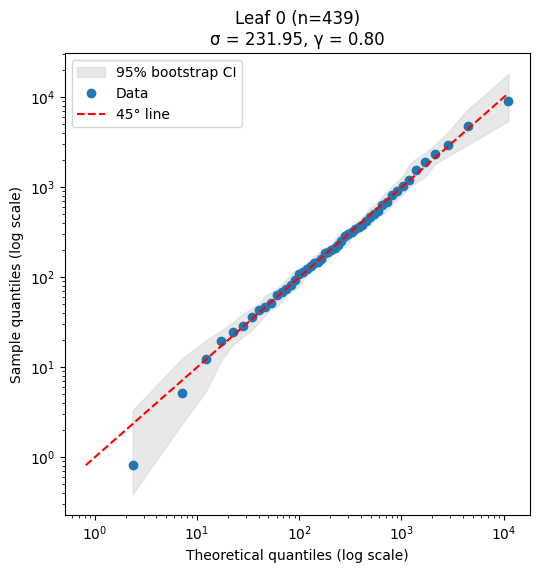

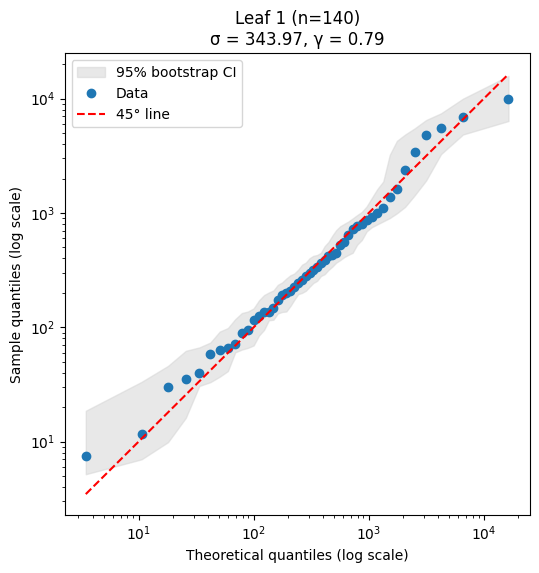

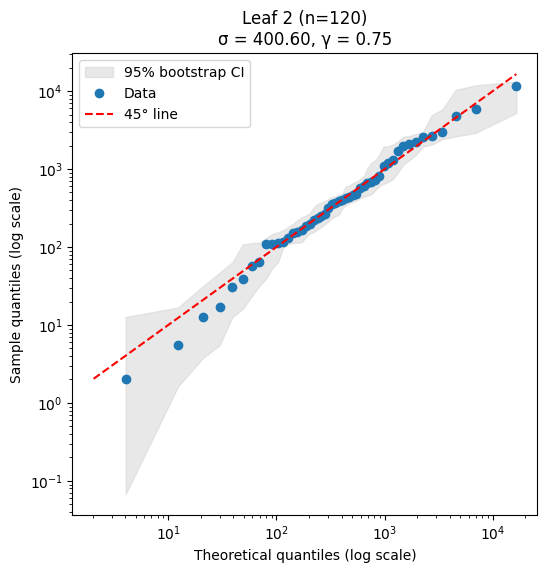

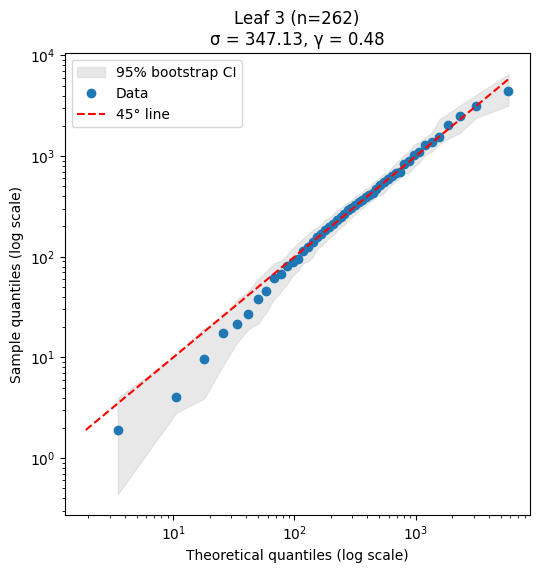

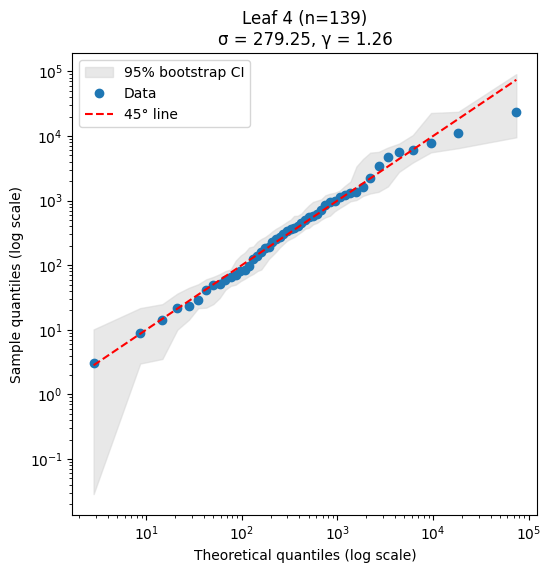

In [ ]:
graphs.plot_gp_tree_qq(gpd_tail_tree_pruned, X_tail, y_tail)


In [ ]:
importance=pd.DataFrame(importances)
importance.head()

,name,importance
0,Category_Damage to Physical Assets,0.001822
1,Category_Manufacturing,0.001470
2,Category_Banking,0.001076
3,Category_Markets & Treasury,0.000634
4,Category_Business Disruption and System Failures,0.000000


In [ ]:
# 모듈 헬퍼 준비
find_leaf = M.find_leaf
get_leaves = M._get_all_leaves

def _get_leaf_params(leaf):
    gp = getattr(leaf, "gpd_params", None)
    return (np.nan, np.nan) if gp is None else (float(gp[0]), float(gp[1]))

# CI 계산
cis = M.leaf_confidence_intervals(
    gpd_tail_tree_pruned, X_tail, y_tail,
    find_leaf=find_leaf, get_leaves=get_leaves, get_leaf_params=_get_leaf_params
)

# 보기 좋게 출력 (+ 리프별 샘플 수)
leaf_objs = np.array([find_leaf(gpd_tail_tree_pruned, X_tail[i]) for i in range(len(X_tail))], dtype=object)
leaves = get_leaves(gpd_tail_tree_pruned)

print("\n===== Leaf-wise γ 95% CI =====")
for i, rec in enumerate(cis):
    gamma = rec.get("gamma", np.nan)
    lo, hi = (rec.get("ci_95", [np.nan, np.nan]) + [np.nan, np.nan])[:2]
    n_i = int(np.sum(leaf_objs == leaves[i])) if i < len(leaves) else 0
    print(f"Leaf#{i:02d}  N={n_i:4d}   γ={gamma: .3f}   CI95=[{lo: .3f}, {hi: .3f}]")



===== Leaf-wise γ 95% CI =====
Leaf#00  N= 439   γ= 0.797   CI95=[ 0.629,  0.965]
Leaf#01  N= 140   γ= 0.795   CI95=[ 0.506,  1.084]
Leaf#02  N= 120   γ= 0.752   CI95=[ 0.425,  1.079]
Leaf#03  N= 262   γ= 0.477   CI95=[ 0.286,  0.668]
Leaf#04  N= 139   γ= 1.264   CI95=[ 0.869,  1.658]


In [ ]:
import numpy as np
import scipy.stats as st

def hill_ci(gamma_hat, n_exceed, alpha=0.05):
    """Asymptotic normal CI for Hill estimator"""
    se = gamma_hat / np.sqrt(n_exceed)
    z = st.norm.ppf(1 - alpha/2)
    return gamma_hat - z*se, gamma_hat + z*se

print("\n===== Leaf-wise γ 95% CI (Asymptotic) =====")
for i, rec in enumerate(cis):
    gamma = rec.get("gamma", np.nan)
    n_i = int(np.sum(leaf_objs == leaves[i])) if i < len(leaves) else 0
    if np.isnan(gamma) or n_i < 30:  # 샘플 적으면 skip
        lo, hi = np.nan, np.nan
    else:
        lo, hi = hill_ci(gamma, n_i, alpha=0.05)
    print(f"Leaf#{i:02d}  N={n_i:4d}   γ={gamma: .3f}   CI95=[{lo: .3f}, {hi: .3f}]")



===== Leaf-wise γ 95% CI (Asymptotic) =====
Leaf#00  N= 439   γ= 0.797   CI95=[ 0.722,  0.872]
Leaf#01  N= 140   γ= 0.795   CI95=[ 0.663,  0.927]
Leaf#02  N= 120   γ= 0.752   CI95=[ 0.618,  0.887]
Leaf#03  N= 262   γ= 0.477   CI95=[ 0.419,  0.535]
Leaf#04  N= 139   γ= 1.264   CI95=[ 1.054,  1.474]


##AIC

In [ ]:
# ================== POST-FIT EVAL: AIC/BIC, VaR, ES, GOF ==================

# ★ 1) raw y (초과치 아님) 준비
y_tail_raw = y_all_data[mask_tail]        # raw tail values
y_tail_excess = y_tail                    # (이미 있음) excess = y - u_threshold

# ★ 2) 네임스페이스 통일 (patched 모듈 함수 바인딩)
find_leaf_fn  = l1_l2_gpd_patched_new_catprune.find_leaf
get_leaves_fn = l1_l2_gpd_patched_new_catprune._get_all_leaves

# ★ 3) LN-only 트리도 patched 모듈로 생성 + 파라미터 부여
ln_only_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l1(
    X_all_data, y_all_data, feature_names_list, min_leaf=30, max_depth=4
)
l1_l2_gpd_patched_new_catprune.assign_lognorm_params(
    ln_only_tree, X_all_data, y_all_data, trunc_right=None
)

# 4) (선택) Bulk 모델로는 L2 트리 사용한 혼합 ln+gpd 성능을 보고 싶다면
tree_ln_for_mix  = l2_bulk_tree                      # bulk용 LN 트리
tree_gpd_for_mix = gpd_tail_tree_pruned              # tail용 GPD 트리 (없으면 None)

# 5) 모델 로그가능도/정보기준
ll_ln, k_ln, aic_ln, bic_ln = model_loglik_aic_bic(
    ln_only_tree, None,
    X_all_data, y_all_data,                      # LN-only: bulk=전체
    np.empty((0, X_all_data.shape[1])), np.empty(0),  # tail 없음
    u_threshold,
    find_leaf=find_leaf_fn, get_leaves=get_leaves_fn
)

if tree_gpd_for_mix is not None:
    ll_mix, k_mix, aic_mix, bic_mix = model_loglik_aic_bic(
        tree_ln_for_mix, tree_gpd_for_mix,
        X_bulk, y_bulk,                         # bulk set
        X_tail, y_tail_raw,                     # ★ raw tail 필요!
        u_threshold,
        find_leaf=find_leaf_fn, get_leaves=get_leaves_fn
    )
else:
    ll_mix, k_mix, aic_mix, bic_mix = (np.nan, np.nan, np.nan, np.nan)

print(f"[LN Only]  logL={ll_ln:.1f}, k={k_ln}, AIC={aic_ln:.1f}, BIC={bic_ln:.1f}")
if tree_gpd_for_mix is not None:
    print(f"[LN+GPD]  logL={ll_mix:.1f}, k={k_mix}, AIC={aic_mix:.1f}, BIC={bic_mix:.1f}")
else:
    print("[LN+GPD]  (tail 표본 부족으로 GPD 트리 없음)")

# 6) VaR / ES
var_ln  = unconditional_var_ln(ln_only_tree, get_leaves=get_leaves_fn, alpha=0.99)
es_ln   = unconditional_es_ln(ln_only_tree,  get_leaves=get_leaves_fn, alpha=0.99)

if tree_gpd_for_mix is not None:
    var_mix = unconditional_var_mix(tree_ln_for_mix, tree_gpd_for_mix, u_threshold,
                                    get_leaves=get_leaves_fn, alpha=0.99)
    es_mix  = unconditional_es_mix (tree_ln_for_mix, tree_gpd_for_mix, u_threshold,
                                    get_leaves=get_leaves_fn, alpha=0.99)
    print(f"99% VaR | LN Only = {var_ln:,.0f}   LN+GPD = {var_mix:,.0f}")
    print(f"99% ES  | LN Only = {es_ln:,.0f}   LN+GPD = {es_mix:,.0f}")
else:
    print(f"99% VaR | LN Only = {var_ln:,.0f}")
    print(f"99% ES  | LN Only = {es_ln:,.0f}")

# 7) GPD 리프별 GOF (KS/AD) — excess 필요
if tree_gpd_for_mix is not None:
    gof_df = gpd_gof_leafwise(
        tree_gpd_for_mix, X_tail, y_tail_excess,
        find_leaf=find_leaf_fn, get_leaves=get_leaves_fn, method="both"
    )
    pd.set_option('display.float_format', '{:,.3f}'.format)
    print("\n=== GPD Leaf-wise KS / AD Results ===")
    print(gof_df.to_string(index=False))


[LN Only]  logL=-84676.5, k=22, AIC=169397.0, BIC=169572.5
[LN+GPD]  logL=-84713.7, k=32, AIC=169491.4, BIC=169746.6
99% VaR | LN Only = 822   LN+GPD = 653
99% ES  | LN Only = 4,229   LN+GPD = inf

=== GPD Leaf-wise KS / AD Results ===
        leaf_id   n   sigma  gamma  KS stat  KS p  AD stat  AD p
132107665672896 139 279.247  1.264    0.059 0.698    0.391 0.393
132107680745024 120 400.603  0.752    0.062 0.729    0.493 0.219
132107680750144 262 347.126  0.477    0.043 0.702    0.709 0.064
132107680754880 140 343.967  0.795    0.044 0.936    0.392 0.390
132107688235200 439 231.955  0.797    0.022 0.981    0.274 0.766


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

# ──────────────────────────────────────────────
# 0) Monte-Carlo 기반 VaR/ES 계산 (ppf 사용 안 함)
# ──────────────────────────────────────────────
def mc_var_es(dist, params, alpha=0.99, n_mc=300_000, random_state=42):
    """
    dist   : scipy.stats 배포( .rvs 가능 )
    params : dist.fit(...) 결과 파라미터 (튜플)
    alpha  : 신뢰수준 (예: 0.99)
    n_mc   : MC 표본 수
    """
    rng = np.random.default_rng(random_state)
    samples = dist.rvs(*params, size=n_mc, random_state=rng)

    # 샘플 기반 VaR/ES
    var_alpha = np.quantile(samples, alpha)
    tail = samples[samples >= var_alpha]
    # tail이 비면 방어적 처리
    if tail.size == 0:
        k = max(1, int(np.ceil(0.001 * n_mc)))
        tail = np.partition(samples, -k)[-k:]
    es_alpha = float(tail.mean())
    return float(var_alpha), es_alpha

# ──────────────────────────────────────────────
# 1) 적합 + AIC/BIC + (MC) VaR + (MC) ES
# ──────────────────────────────────────────────
def fit_score_var_es(dist, data, name,
                     fix_loc0=True,    # NIG에는 False 권장
                     alpha=0.99,
                     n_es_mc=300_000,
                     random_state=42):
    """
    dist, data, name, alpha 동일.
    n_es_mc : ES/ VaR 추정을 위한 MC 표본 수
    """
    try:
        data = np.asarray(data, dtype=float)
        data = data[np.isfinite(data)]
        if data.size == 0:
            raise ValueError("No valid data points.")

        # ① 분포 적합 (MLE)
        if fix_loc0:
            params = dist.fit(data, floc=0)   # loc을 0으로 고정 (NIG에는 비권장)
            k = len(params) - 1
        else:
            params = dist.fit(data)           # loc/scale/shape 모두 추정
            k = len(params)

        # ② 로그 가능도
        logpdf = dist.logpdf(data, *params)
        logpdf = logpdf[np.isfinite(logpdf)]
        logL   = float(logpdf.sum())
        n      = int(data.size)

        # ③ AIC / BIC
        aic = 2*k - 2*logL
        bic = np.log(n)*k - 2*logL

        # ④~⑤ VaR/ES (모두 MC로 계산 → ppf 사용 안 함)
        var_alpha, es_alpha = mc_var_es(dist, params, alpha, n_es_mc, random_state)

        return {
            "Distribution": name,
            "Log-Likelihood": logL,
            "AIC": aic,
            "BIC": bic,
            f"VaR {int(alpha*100)}%": var_alpha,
            f"ES  {int(alpha*100)}%": es_alpha
        }

    except Exception as e:
        return {
            "Distribution": name,
            "Log-Likelihood": f"Fit failed: {e}",
            "AIC": np.nan,
            "BIC": np.nan,
            f"VaR {int(alpha*100)}%": np.nan,
            f"ES  {int(alpha*100)}%": np.nan
        }

# ──────────────────────────────────────────────
# 2) 후보 분포 지정 & 실행
# ──────────────────────────────────────────────
candidates = {
    "Log-Normal":     (stats.lognorm,     True),
    "Gamma":          (stats.gamma,       True),
    "Weibull":        (stats.weibull_min, True),
    # NIG는 scipy.stats.norminvgauss (shape: a, b; loc, scale)
    # ★ floc=0 고정하지 마세요 → 수치 불안정 완화
    "NIG":            (stats.norminvgauss, False),
}

alpha = 0.99
results = [fit_score_var_es(dist, y_all_data, name,
                            fix_loc0=fix_loc0,   # NIG는 False
                            alpha=alpha,
                            n_es_mc=300_000,
                            random_state=42)
           for name, (dist, fix_loc0) in candidates.items()]

results_df = (pd.DataFrame(results)
                .sort_values("AIC", key=lambda s: s.fillna(np.inf))
                .reset_index(drop=True))

print(results_df)


  Distribution  Log-Likelihood         AIC         BIC   VaR 99%   ES  99%
0   Log-Normal     -86,771.013 173,546.027 173,561.979   801.234 2,462.110
1          NIG     -87,014.825 174,037.650 174,069.554 1,745.448 3,821.186
2      Weibull     -89,635.315 179,274.630 179,290.582   557.017   889.182
3        Gamma     -94,796.281 189,596.561 189,612.513   762.340 1,012.920



================  Model Comparison  ================

  Distribution  Log-Likelihood         AIC         BIC   VaR 99%   ES  99%  \
0       LN+GPD     -84,713.706 169,491.412 169,746.648   652.828       inf   
1   Log-Normal     -86,771.013 173,546.027 173,561.979   801.234 2,462.110   
2          NIG     -87,014.825 174,037.650 174,069.554 1,745.448 3,821.186   
3      Weibull     -89,635.315 179,274.630 179,290.582   557.017   889.182   
4        Gamma     -94,796.281 189,596.561 189,612.513   762.340 1,012.920   

       k  
0 32.000  
1    NaN  
2    NaN  
3    NaN  
4    NaN  


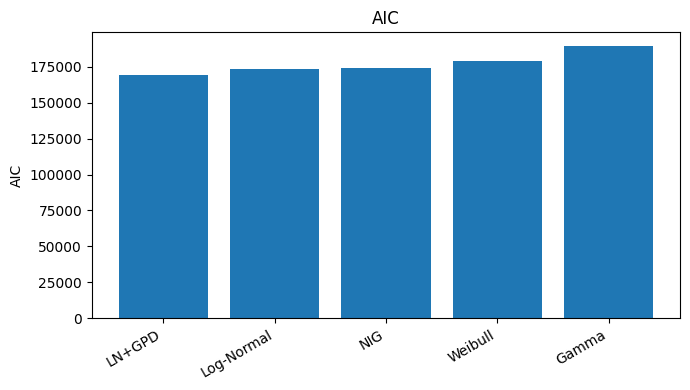

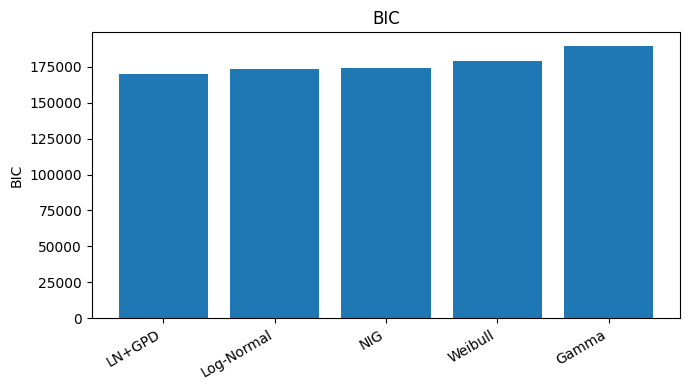

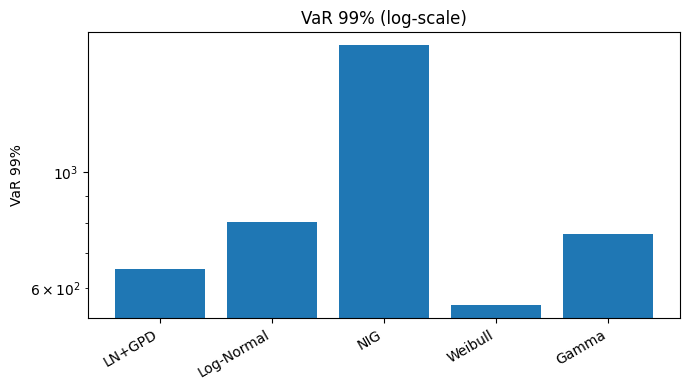

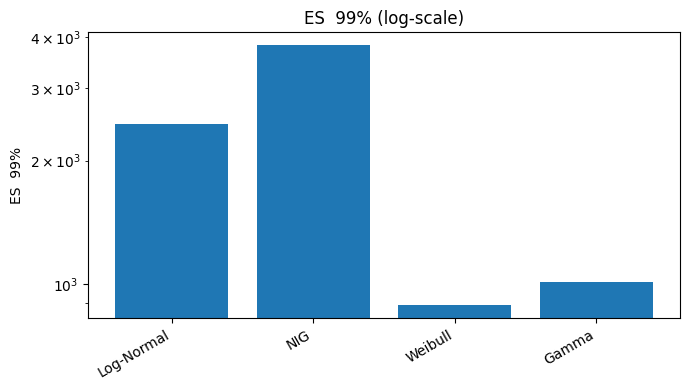

In [ ]:
# ──────────────────────────────────────────────
# 0) Tree 모델 행을 만들어 results_df 와 합치기
# ──────────────────────────────────────────────
tree_rows = pd.DataFrame([
#    {"Distribution": "LN‑Tree",  "Log-Likelihood": ll_ln,  "k": k_ln,
#     "AIC": aic_ln,  "BIC": bic_ln,
 #    "VaR 99%": var_ln,  "ES  99%": es_ln},
    {"Distribution": "LN+GPD",   "Log-Likelihood": ll_mix, "k": k_mix,
     "AIC": aic_mix, "BIC": bic_mix,
     "VaR 99%": var_mix, "ES  99%": es_mix}
])

full_df = (pd.concat([results_df, tree_rows], ignore_index=True)
             .sort_values("AIC")
             .reset_index(drop=True))

print("\n================  Model Comparison  ================\n")
print(full_df)

# ──────────────────────────────────────────────
# 1) AIC / BIC   (로그축 X)
# ──────────────────────────────────────────────
import matplotlib.pyplot as plt

for metric in ["AIC", "BIC"]:
    plt.figure(figsize=(7,4))
    plt.bar(full_df["Distribution"], full_df[metric])
    plt.title(f"{metric}")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

# ──────────────────────────────────────────────
# 2) VaR / ES   (log‑scale로 값 차이를 보기 좋게)
# ──────────────────────────────────────────────
for metric in ["VaR 99%", "ES  99%"]:
    y = pd.to_numeric(full_df[metric], errors="coerce").to_numpy(dtype=float)
    y_plot = np.where(np.isfinite(y) & (y > 0), y, np.nan)  # 🔧 inf/<=0 → NaN
    plt.figure(figsize=(7,4))
    plt.bar(full_df["Distribution"], y_plot)
    plt.yscale("log")
    plt.title(f"{metric} (log-scale)")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()



In [ ]:
import pickle

# --- __main__ 블록 마지막에 추가 ---
save_path = '/content/drive/MyDrive/Operational_risk/'
# 1) 저장할 객체들 모으기
output = {
    # Bulk 트리
    'l1_bulk_tree' : l1_bulk_tree,
    'l2_bulk_tree' : l2_bulk_tree,
    # Tail 트리
    'gpd_raw_tree' : gpd_tail_tree_raw,
    'gpd_pruned_tree' : gpd_tail_tree_pruned,
    # 데이터
    'X_bulk'       : X_bulk,
    'y_bulk'       : y_bulk,
    'X_tail'       : X_tail,
    'y_tail'       : y_tail,
    'X_all_data'   : X_all_data,
    'y_all_data'   : y_all_data,
    'df_model_ready':df_model_ready,
    # (선택) 피처 이름
    'feature_names': feature_names_list,
    # (선택) 임계값
    'u_threshold'  : u_threshold
}

# 2) 피클 파일로 저장
with open(save_path + 'EPU_Total.pkl', 'wb') as f:
    pickle.dump(output, f)



#Category by Loss

In [ ]:
df=df1.copy()

In [ ]:
us_df = df[df['Country of Incident'] == 'United States']
loss_df = us_df[['First Year of Event','Industry Sector Code','Basel Business Line - Level 2','Event Risk Category','Loss Amount ($M)']].copy()
loss_df.rename(columns={'First Year of Event':'Date', 'Loss Amount ($M)':'Current Value of Loss'}, inplace=True)
loss_df['Date'] = pd.to_datetime(loss_df['Date']).dt.strftime('%Y')
loss_df.sort_values(by='Date', inplace=True)
loss_df = loss_df[loss_df['Date'] >= '1979']


In [ ]:
loss_df_finance=loss_df

In [ ]:
loss_df['Event Risk Category'].unique()

array(['Clients, Products & Business Practices',
       'Employment Practices and Workplace Safety',
       'Damage to Physical Assets', 'Internal Fraud', 'External Fraud',
       'Execution, Delivery & Process Management',
       'Business Disruption and System Failures'], dtype=object)

In [ ]:
loss_df_finance.rename(columns={"Basel Business Line - Level 2":"Business"},inplace=True)
loss_df_finance.drop(columns=['Industry Sector Code'],inplace=True)

In [ ]:
import re
import pandas as pd

# 입력 컬럼
SOURCE_COL = 'Business'

def _norm(x):
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    # 정규화: & -> and, / -> space, -, , -> space, 괄호 제거, 다중공백 축소
    s = s.replace('&', ' and ')
    s = re.sub(r'[\/,\-]', ' ', s)
    s = re.sub(r'[\(\)\[\]]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    # 특수 케이스 보정
    s = s.replace('foodservices', 'food services')
    s = s.replace('non discretionary', 'non-discretionary')
    return s

# -------------------------------
# 1) 금융 도메인 상위 라인 매핑
# -------------------------------
FIN_MAP = {
    # Banking
    'retail banking': 'Banking',
    'commercial banking': 'Banking',
    'private banking': 'Banking',
    'card services': 'Banking',
    # Markets & Treasury
    'market making': 'Markets & Treasury',
    'sales': 'Markets & Treasury',
    'proprietary positions': 'Markets & Treasury',
    'treasury': 'Markets & Treasury',
    # Investment Banking
    'corporate finance': 'Investment Banking',
    'municipal government finance': 'Investment Banking',  # 슬래시 정규화 반영
    # Brokerage & Advisory
    'retail brokerage': 'Brokerage & Advisory',
    'brokerage and advisory': 'Brokerage & Advisory',
    'advisory services': 'Brokerage & Advisory',
    # Asset & Wealth Mgmt
    'discretionary fund management': 'Asset & Wealth Mgmt',
    'non-discretionary fund management': 'Asset & Wealth Mgmt',
    'merchant banking': 'Asset & Wealth Mgmt',
    # Asset Servicing & Trust
    'custody': 'Asset Servicing & Trust',
    'corporate trust': 'Asset Servicing & Trust',
    # Insurance
    'property and casualty insurance': 'Insurance',
    'life insurance and benefit plans': 'Insurance',
    'health insurance': 'Insurance',
    'reinsurance': 'Insurance',
    'corporate agency': 'Insurance',
    'professional liability fidelity coverage': 'Insurance',
    # Others
    'external clients': 'Others',
    'others': 'Others',
}

# -------------------------------
# 2) 비금융(NAICS류) 상위 그룹 매핑
# -------------------------------
NONFIN_MAP = {
    'manufacturing': 'Manufacturing',
    'construction': 'Construction',
    'utilities': 'Utilities',
    'mining': 'Mining',
    'retail trade': 'Retail Trade',
    'wholesale trade': 'Wholesale Trade',
    'transportation and warehousing': 'Transportation & Warehousing',
    'information': 'Information',
    'educational services': 'Educational Services',
    'health care and social assistance': 'Health Care & Social Assistance',
    'agriculture forestry fishing and hunting': 'Agriculture, Forestry, Fishing & Hunting',
    'real estate rental and leasing': 'Real Estate, Rental & Leasing',
    'accommodation and food services': 'Accommodation & Food Services',
    'arts entertainment and recreation': 'Arts, Entertainment & Recreation',
    'public administration': 'Public Administration',
    'professional scientific and technical services': 'Professional Services',
    'administrative and support waste management and remediation services': 'Admin & Support, Waste Mgmt',
    'management of companies and enterprises': 'Mgmt of Companies & Enterprises',
    'other services except public administration': 'Other Services',
    'non-profit organizations': 'Non-Profit',
}

# -------------------------------
# 3) 키워드 휴리스틱 (미지정 값 보조 분류)
# -------------------------------
def _heuristic_fin(key: str):
    if any(w in key for w in ['bank', 'card']):
        return 'Banking'
    if any(w in key for w in ['market making', 'treasury', 'proprietary', 'sales']):
        return 'Markets & Treasury'
    if any(w in key for w in ['broker', 'advisory']):
        return 'Brokerage & Advisory'
    if any(w in key for w in ['fund', 'asset', 'merchant banking', 'wealth']):
        return 'Asset & Wealth Mgmt'
    if any(w in key for w in ['custody', 'trust']):
        return 'Asset Servicing & Trust'
    if 'insurance' in key or 'reinsurance' in key or 'liability' in key:
        return 'Insurance'
    if 'finance' in key:
        return 'Investment Banking'
    return None

def _heuristic_nonfin(key: str):
    # 순서 중요(특정성이 높은 것부터)
    if 'retail trade' in key or (('retail' in key) and ('trade' in key)):
        return 'Retail Trade'
    if 'wholesale' in key:
        return 'Wholesale Trade'
    if 'manufactur' in key:
        return 'Manufacturing'
    if 'construction' in key:
        return 'Construction'
    if 'transportation' in key or 'warehousing' in key:
        return 'Transportation & Warehousing'
    if 'utilities' in key:
        return 'Utilities'
    if any(w in key for w in ['agriculture','forestry','fishing','hunting']):
        return 'Agriculture, Forestry, Fishing & Hunting'
    if 'information' in key:
        return 'Information'
    if 'educational' in key or 'education' in key:
        return 'Educational Services'
    if 'health care' in key or 'social assistance' in key or 'healthcare' in key:
        return 'Health Care & Social Assistance'
    if 'real estate' in key or 'rental' in key or 'leasing' in key:
        return 'Real Estate, Rental & Leasing'
    if 'accommodation' in key or 'food services' in key:
        return 'Accommodation & Food Services'
    if any(w in key for w in ['arts','entertainment','recreation']):
        return 'Arts, Entertainment & Recreation'
    if 'public administration' in key:
        return 'Public Administration'
    if 'professional scientific' in key or 'technical services' in key:
        return 'Professional Services'
    if 'administrative and support' in key or 'waste management' in key or 'remediation' in key:
        return 'Admin & Support, Waste Mgmt'
    if 'management of companies' in key:
        return 'Mgmt of Companies & Enterprises'
    if 'non profit' in key or 'nonprofit' in key:
        return 'Non-Profit'
    if 'other services' in key:
        return 'Other Services'
    return None

# -------------------------------
# 4) 최종 분류 함수
# -------------------------------
def classify_sector_and_line(val):
    key = _norm(val)
    if key is None or key == '':
        return pd.Series(['Unknown', 'Others'])

    # 1) 직접 매핑
    if key in FIN_MAP:
        return pd.Series(['Finance', FIN_MAP[key]])
    if key in NONFIN_MAP:
        return pd.Series(['Non-Finance', NONFIN_MAP[key]])

    # 2) 휴리스틱(금융 → 비금융 순서)
    fin_guess = _heuristic_fin(key)
    if fin_guess:
        return pd.Series(['Finance', fin_guess])
    nonfin_guess = _heuristic_nonfin(key)
    if nonfin_guess:
        return pd.Series(['Non-Finance', nonfin_guess])

    # 3) 최종 기본값
    return pd.Series(['Unknown', 'Others'])

# 적용: 두 컬럼 생성
loss_df_finance[['SectorType', 'Business_line']] = (
    loss_df_finance[SOURCE_COL].apply(classify_sector_and_line)
)


In [ ]:
loss_df_finance=loss_df_finance.drop(columns=['Business','SectorType'])

In [ ]:
loss_df_finance['Business_line'].value_counts()

,count
Business_line,
Manufacturing,4957
Banking,4891
Insurance,1968
Brokerage & Advisory,1598
Markets & Treasury,1230
Information,959
Utilities,958
Health Care & Social Assistance,816
Retail Trade,709


In [ ]:
loss_df_finance['Event Risk Category'].value_counts()

,count
Event Risk Category,
"Clients, Products & Business Practices",12355
Damage to Physical Assets,3132
External Fraud,2835
Internal Fraud,2667
Employment Practices and Workplace Safety,1358
"Execution, Delivery & Process Management",846
Business Disruption and System Failures,105


##Banking

In [ ]:
loss_business_line = loss_df_finance[['Date', 'Current Value of Loss', 'Business_line']]

loss_by_business = (
    loss_business_line
    .groupby('Business_line', as_index=False)
    .agg({'Current Value of Loss': 'sum'}).sort_values('Current Value of Loss',ascending=False)  # Date 제외
)

print(loss_by_business)


                               Business_line  Current Value of Loss
14                             Manufacturing          560932.573185
6                                    Banking          302262.486954
15                        Markets & Treasury          213882.020350
12                                 Insurance          111524.404294
17                                    Mining          105680.455505
26                                 Utilities           92062.103355
11                               Information           90866.078612
4                        Asset & Wealth Mgmt           81127.211013
7                       Brokerage & Advisory           53847.653886
21                     Professional Services           45048.866263
20                                    Others           42964.901939
13                        Investment Banking           41731.369352
10           Health Care & Social Assistance           36589.189900
24                              Retail Trade    

In [ ]:
loss_manufacturing= loss_df_finance[loss_df_finance['Business_line'] == 'Banking'].copy()


In [ ]:
loss_manufacturing.head()

,Date,Event Risk Category,Current Value of Loss,Business_line
1799,1979,"Clients, Products & Business Practices",8.844700,Banking
1282,1979,Internal Fraud,2.304687,Banking
1654,1979,Internal Fraud,12.408634,Banking
1707,1979,"Clients, Products & Business Practices",6.328597,Banking
7302,1979,"Clients, Products & Business Practices",11.329346,Banking


In [ ]:
loss_manufacturing['Event Risk Category'].value_counts()

,count
Event Risk Category,
External Fraud,1880
"Clients, Products & Business Practices",1449
Internal Fraud,1282
Employment Practices and Workplace Safety,131
"Execution, Delivery & Process Management",103
Damage to Physical Assets,40
Business Disruption and System Failures,6


In [ ]:
# Encode 'Event Risk Category'
df_encoded_a = pd.get_dummies(loss_manufacturing, columns=['Event Risk Category'], prefix='Category')

# Use the result of the first encoding as input for the second encoding
df_encoded_b = df_encoded_a.copy()
df_encoded_b.drop(columns=['Business_line'], inplace=True)

# Final encoded DataFrame
loss_manufacturing = df_encoded_b.copy()


In [ ]:
import re

# ① CSV 읽기
cpu = pd.read_csv('/content/drive/MyDrive/CPU index.csv')[['date', 'cpu_index']]

# ② 전처리 ── 공백 제거
cpu['date'] = cpu['date'].str.strip()

# ③ 'YY-Mon' → 'Mon-YY' 로 재배열
cpu['date'] = cpu['date'].str.replace(
    r'^(\d{2})-([A-Za-z]{3})$',   # 2자리 연도-3자리 월
    r'\2-\1',                     # 월-연도로 바꾸기
    regex=True, flags=re.IGNORECASE
)

# ④ datetime 파싱
cpu['date'] = pd.to_datetime(cpu['date'], format='%b-%y', errors='coerce')

# ⑤ 원하는 포맷(문자열)으로 출력하거나, 월 Period 로도 사용 가능
cpu['date'] = cpu['date'].dt.strftime('%Y-%m')      # 문자열 형태


In [ ]:
import pandas as pd
import numpy as np
from functools import reduce

file_paths = {
    "us_cpi": "/content/drive/MyDrive/us_cpi.csv",
    "us_unemp": "/content/drive/MyDrive/us_unemp.csv",
    "us_vix": "/content/drive/MyDrive/us_vix.csv",
    "us_m1": "/content/drive/MyDrive/us_m1.csv",
    "us_home_price": "/content/drive/MyDrive/us_home price index.csv",
    "us_T10Y2Y": "/content/drive/MyDrive/us_T10Y2Y.csv",
    "sp500": "/content/drive/MyDrive/sp500_monthly.csv",
}

# Load
us_cpi = pd.read_csv(file_paths["us_cpi"])
us_unemp = pd.read_csv(file_paths["us_unemp"])
us_m1 = pd.read_csv(file_paths["us_m1"])
us_home_price = pd.read_csv(file_paths["us_home_price"])
us_T10Y2Y = pd.read_csv(file_paths["us_T10Y2Y"])
sp500 = pd.read_csv(file_paths["sp500"], skiprows=2)

# Rename columns
us_T10Y2Y.rename(columns={'T10Y2Y': '10_2'}, inplace=True)
us_home_price.rename(columns={'USSTHPI': 'House Price Index'}, inplace=True)
us_m1.rename(columns={'WM1NS': 'M1'}, inplace=True)
us_cpi.rename(columns={'CPIAUCSL': 'CPI'}, inplace=True)
us_unemp.rename(columns={'UNRATE': 'Unemployment Rate'}, inplace=True)
sp500.rename(columns={'Unnamed: 1': 'Close'}, inplace=True)
sp500 = sp500.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4", "Unnamed: 5"])
cpu.rename(columns={'date': 'Date'}, inplace=True)


# Date 처리 및 연 단위 평균
for df in [us_cpi, us_unemp, us_m1, us_home_price, us_T10Y2Y, sp500,cpu]:
    df.rename(columns={df.columns[0]: "Date"}, inplace=True)
    df["Date"] = pd.to_datetime(df["Date"]).dt.year

us_T10Y2Y = us_T10Y2Y.groupby("Date").mean().reset_index()
us_home_price = us_home_price.groupby("Date").mean().reset_index()
us_m1 = us_m1.groupby("Date").mean().reset_index()
us_cpi = us_cpi.groupby("Date").mean().reset_index()
us_unemp = us_unemp.groupby("Date").mean().reset_index()
sp500 = sp500.groupby("Date").mean().reset_index()
cpu = cpu.groupby("Date").mean().reset_index()


# log-diff 처리
macro_dfs = {

    'Close_diff': (sp500, 'Close'),
}

# diff 열 추가
for diff_col, (df, col) in macro_dfs.items():
    df[diff_col] = np.log(df[col]).diff()

# sp500의 첫 번째 NaN만 특정 값으로 채움
sp500['Close_diff'].fillna(0.1635259493925565, inplace=True)

# 병합
dfs = [us_T10Y2Y, us_home_price, us_m1, us_cpi, us_unemp, sp500,cpu]
df_merged_macro = reduce(lambda left, right: pd.merge(left, right, on="Date", how="inner"), dfs)

# 최종 lag 데이터
df_merged_macro_lag = df_merged_macro[df_merged_macro["Date"] >= 1980].copy()
df_merged_macro_lag['Date'] = df_merged_macro_lag['Date'].astype(str)


/tmp/ipython-input-852055941.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sp500['Close_diff'].fillna(0.1635259493925565, inplace=True)


In [ ]:
import numpy as np
import pandas as pd
from functools import reduce
from sklearn.preprocessing import MinMaxScaler
from scipy.optimize import minimize
from scipy.stats import genpareto
import copy
#1986부터 사용
#############################################
# 1. 데이터 전처리 (연 단위)
#############################################
# (1) 엑셀 파일 읽기 및 날짜 정리
# 실제 파일 경로로 수정하세요.

epu_kr_path = '/content/drive/MyDrive/Korea_Overall_EPU.xlsx'
epu_kr_cat_path = '/content/drive/MyDrive/Korea_Categorical_PU_Indices.xlsx'
epu_usa_path = '/content/drive/MyDrive/US_Policy_Uncertainty_Data.xlsx'
epu_usa_cat_path = '/content/drive/MyDrive/Categorical_EPU_Data.xlsx'


# 미국 EPU 데이터
epu_usa = pd.read_excel(epu_usa_path)
epu_usa_cat = pd.read_excel(epu_usa_cat_path)
# 연도만 추출 (datetime 변환 후 정수형으로)
epu_usa['Year'] = pd.to_datetime(epu_usa['Year'], format='%Y').dt.year.astype(int)
epu_usa_cat['Year'] = pd.to_datetime(epu_usa_cat['Year'], format='%Y').dt.year.astype(int)
# 연도 필터링 (1985~2022)
epu_usa_cl = epu_usa[(epu_usa['Year'] < 2023)].copy()
epu_usa_cat_cl = epu_usa_cat[ (epu_usa_cat['Year'] < 2023)].copy()
# 최종적으로 'Date' 컬럼에 연도만(문자형) 저장
epu_usa_cl['Date'] = epu_usa_cl['Year'].astype(str)
epu_usa_cat_cl['Date'] = epu_usa_cat_cl['Year'].astype(str)
epu_usa_cl_lag = epu_usa_cl.copy()
epu_usa_cat_cl_lag = epu_usa_cat_cl.copy()


epu_usa_cl['Date'] = epu_usa_cl['Year'].astype(str)

epu_overall = (
    epu_usa_cl
    .groupby('Date')[['Three_Component_Index','News_Based_Policy_Uncert_Index']]
    .mean()
    .reset_index()
)

# 2) 범주형 EPU 연평균 집계
# ————————
cat_cols = [
    '1. Economic Policy Uncertainty','2. Monetary policy',
    'Fiscal Policy (Taxes OR Spending)','3. Taxes',
    '4. Government spending','5. Health care',
    '6. National security','7. Entitlement programs',
    '8. Regulation','Financial Regulation',
    '9. Trade policy','10. Sovereign debt, currency crises'
]
epu_usa_cat_cl['Date'] = epu_usa_cat_cl['Year'].astype(str)

epu_cats = (
    epu_usa_cat_cl
    .groupby('Date')[cat_cols]
    .mean()
    .reset_index()
)

# 3) 매크로 + EPU(전체+범주) 병합
# ———————————————
df_macro_epu = (
    df_merged_macro_lag
    .merge(epu_overall, on='Date', how='inner')
    .merge(epu_cats,    on='Date', how='inner')
)

# 4) 최종: 이벤트 손실(≈433행)과 1:1 병합
# ——————————————————————
final_df = df_macro_epu.merge(loss_manufacturing, on='Date', how='inner')




In [ ]:
df_merged=final_df.copy()
df_merged['Exceedance']=df_merged['Current Value of Loss']

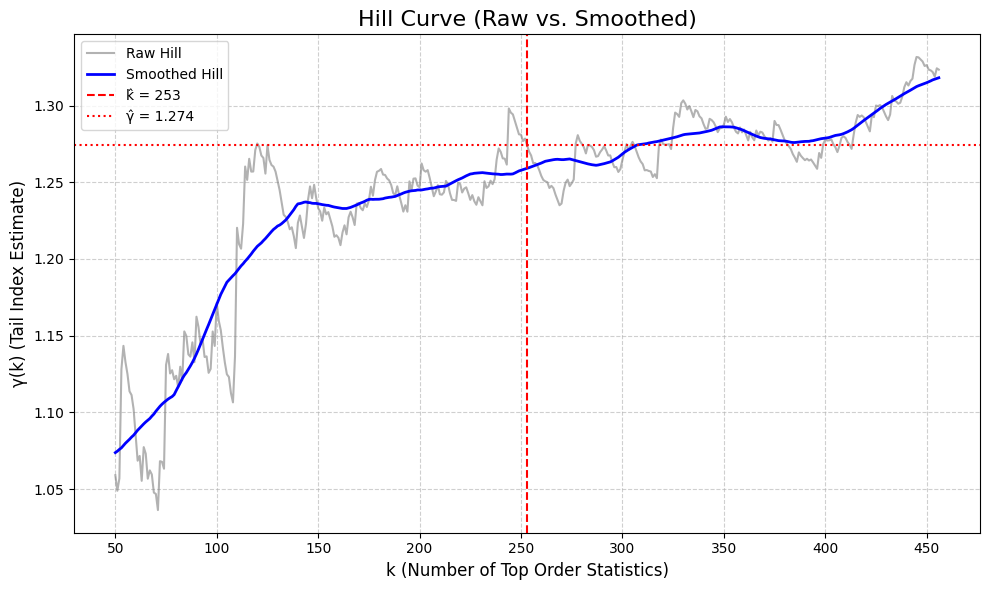

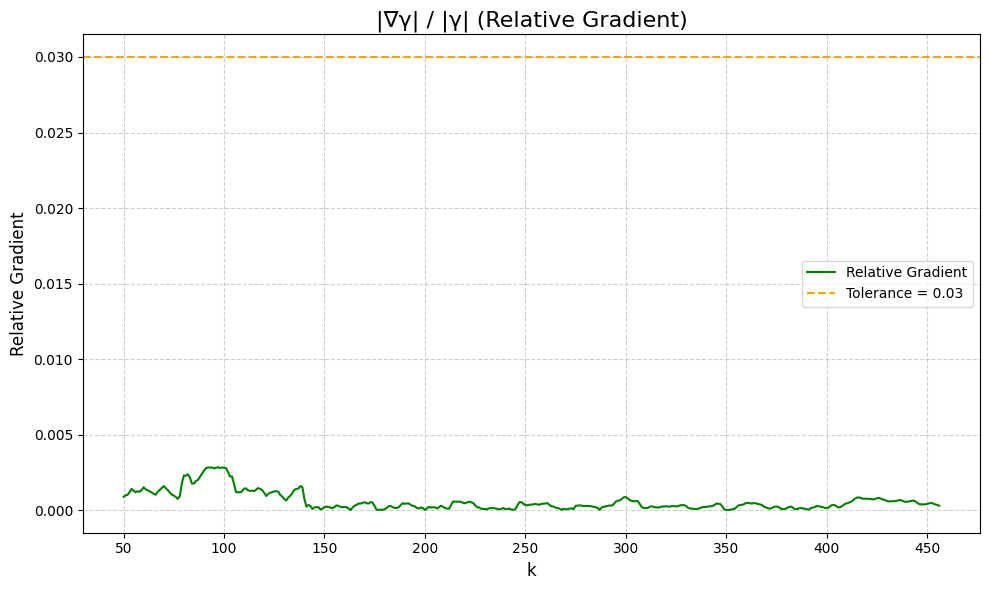

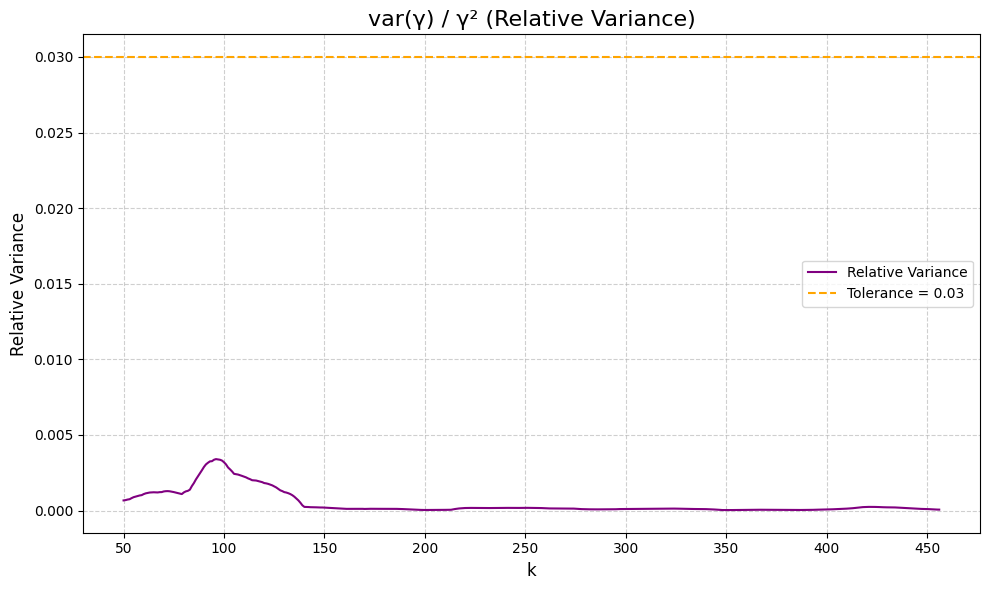

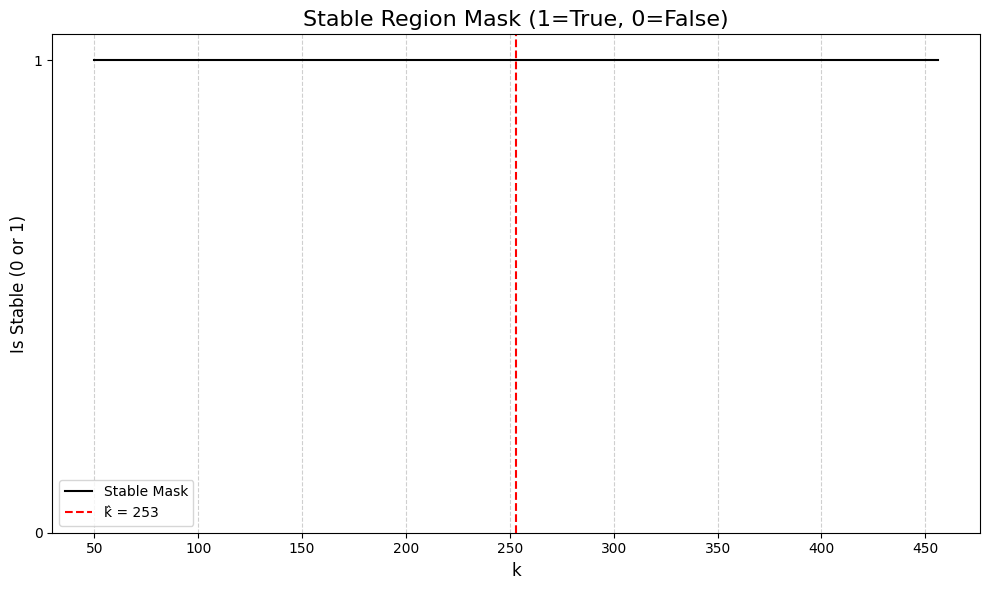


--- Results ---
Estimated Threshold (u_hat): 102.5392
Number of Exceedances (k_hat): 253
Estimated Tail Index (gamma_hat): 1.2741
----------------


In [ ]:
# hill_plots.py ─────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple, Dict, Any

# It's assumed that the 'thresholding' module you created is in the same folder.
from hill_plot_new_patched import select_threshold, HillDiag

def _compute_hill_raw_curve(y: np.ndarray, ks: np.ndarray) -> np.ndarray:
    """
    Computes the raw (unsmoothed) Hill curve.
    γ_k = mean( log Y_(1..k) - log Y_(k+1) ), where Y are sorted positive values.
    """
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]
    y_desc = np.sort(y)[::-1]
    y_pos = y_desc[y_desc > 0]
    if y_pos.size < 2 or ks.size == 0: # Need at least 2 points to compute log-differences
        return np.array([])

    # Ensure k does not exceed valid index
    max_k = y_pos.size - 1
    valid_ks = ks[ks < max_k]
    if valid_ks.size == 0:
        return np.array([])

    return np.array([np.mean(np.log(y_pos[:k]) - np.log(y_pos[k])) for k in valid_ks], dtype=float)

def plot_hill_curve(
    y: np.ndarray,
    diag: HillDiag,
    k_hat: int,
    gamma_hat: float,
    *,
    title: str = "Hill Curve (Raw vs. Smoothed)",
) -> None:
    """
    Plots the Hill curve (raw vs. smoothed) and the estimated point (k_hat, gamma_hat).
    """
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot Hill curve.")
        return

    gamma_raw = _compute_hill_raw_curve(y, diag.k_grid)

    plt.figure(figsize=(10, 6))
    if gamma_raw.size:
        # Match raw curve to its valid k-grid
        max_k_raw = y.size - 1
        valid_ks_raw = diag.k_grid[diag.k_grid < max_k_raw]
        plt.plot(valid_ks_raw, gamma_raw, label="Raw Hill", alpha=0.6, color='gray')

    plt.plot(diag.k_grid, diag.gamma_hat, label="Smoothed Hill", color='blue', linewidth=2)
    plt.axvline(k_hat, linestyle="--", color='red', label=f"k̂ = {k_hat}")
    plt.axhline(gamma_hat, linestyle=":", color='red', label=f"γ̂ = {gamma_hat:.3f}")

    plt.title(title, fontsize=16)
    # CHANGED: Korean -> English
    plt.xlabel("k (Number of Top Order Statistics)", fontsize=12)
    plt.ylabel("γ(k) (Tail Index Estimate)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_grad_norm(
    diag: HillDiag,
    *,
    rel_grad_tol: float,
    title: str = "|∇γ| / |γ| (Relative Gradient)"
) -> None:
    """Plots the relative gradient and the tolerance line."""
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot grad_norm.")
        return

    plt.figure(figsize=(10, 6))
    plt.plot(diag.k_grid, diag.grad_norm, label="Relative Gradient", color='green')
    plt.axhline(rel_grad_tol, linestyle="--", color='orange', label=f"Tolerance = {rel_grad_tol}")
    plt.title(title, fontsize=16)
    plt.xlabel("k", fontsize=12)
    plt.ylabel("Relative Gradient", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_var_rel(
    diag: HillDiag,
    *,
    rel_var_tol: float,
    title: str = "var(γ) / γ² (Relative Variance)"
) -> None:
    """Plots the relative variance and the tolerance line."""
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot var_rel.")
        return

    plt.figure(figsize=(10, 6))
    plt.plot(diag.k_grid, diag.var_rel, label="Relative Variance", color='purple')
    plt.axhline(rel_var_tol, linestyle="--", color='orange', label=f"Tolerance = {rel_var_tol}")
    plt.title(title, fontsize=16)
    plt.xlabel("k", fontsize=12)
    plt.ylabel("Relative Variance", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_stable_mask(
    diag: HillDiag,
    *,
    rel_grad_tol: float,
    rel_var_tol: float,
    gamma_min: float,
    k_hat: int,
    title: str = "Stable Region Mask (1=True, 0=False)"
) -> None:
    """
    Visualizes the stable region mask:
    stable = (grad_norm < rel_grad_tol) & (var_rel < rel_var_tol) & (gamma_hat > gamma_min)
    """
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot stable mask.")
        return

    stable = (diag.grad_norm < rel_grad_tol) & (diag.var_rel < rel_var_tol) & (diag.gamma_hat > gamma_min)

    plt.figure(figsize=(10, 6))
    plt.step(diag.k_grid, stable.astype(int), where="mid", label="Stable Mask", color='black')
    plt.axvline(k_hat, linestyle="--", color='red', label=f"k̂ = {k_hat}")
    plt.title(title, fontsize=16)
    plt.xlabel("k", fontsize=12)
    plt.ylabel("Is Stable (0 or 1)", fontsize=12)
    plt.yticks([0, 1])
    plt.legend()
    plt.grid(True, axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_hill_diagnostics(
    y: np.ndarray,
    *,
    # Parameters for thresholding._auto_hill
    k_min: int = 50,
    k_max_prop: float = 0.1,
    window: int = 61,
    rel_grad_tol: float = 0.04,
    rel_var_tol: float = 0.03,
    gamma_min: float = 0.02,
    min_plateau_len: int = 10,
    plateau_strategy: str = "longest",
    min_excess: Optional[int] = None,
    max_excess: Optional[int] = None,
    # Optional titles for individual plots
    titles: Optional[Dict[str, str]] = None,
    # For passing extra args to select_threshold
    extra_hill_kwargs: Optional[Dict[str, Any]] = None,
) -> Tuple[float, int, float, HillDiag]:
    """
    In a single call, this function:
      1) Runs select_threshold to get (u_hat, k_hat, gamma_hat, diag).
      2) Generates separate plots for Hill curve, grad_norm, var_rel, and stable mask.

    Returns: (u_hat, k_hat, gamma_hat, diag)
    """
    if titles is None:
        titles = {}
    if extra_hill_kwargs is None:
        extra_hill_kwargs = {}

    # Call select_threshold requesting the diagnostic data
    u_hat, k_hat, gamma_hat, diag = select_threshold(
        y,
        return_diag=True,
        k_min=k_min,
        k_max_prop=k_max_prop,
        window=window,
        rel_grad_tol=rel_grad_tol,
        rel_var_tol=rel_var_tol,
        gamma_min=gamma_min,
        min_plateau_len=min_plateau_len,
        plateau_strategy=plateau_strategy,
        min_excess=min_excess,
        max_excess=max_excess,
        **extra_hill_kwargs,
    )

    # 1) Hill Curve
    plot_hill_curve(
        y, diag, k_hat, gamma_hat,
        title=titles.get("hill", "Hill Curve (Raw vs. Smoothed)")
    )

    # 2) grad_norm
    plot_grad_norm(
        diag,
        rel_grad_tol=rel_grad_tol,
        title=titles.get("grad", "|∇γ| / |γ| (Relative Gradient)")
    )

    # 3) var_rel
    plot_var_rel(
        diag,
        rel_var_tol=rel_var_tol,
        title=titles.get("var", "var(γ) / γ² (Relative Variance)")
    )

    # 4) stable mask
    plot_stable_mask(
        diag,
        rel_grad_tol=rel_grad_tol,
        rel_var_tol=rel_var_tol,
        gamma_min=gamma_min,
        k_hat=k_hat,
        title=titles.get("stable", "Stable Region Mask (1=True, 0=False)")
    )

    return u_hat, k_hat, gamma_hat, diag


if __name__ == "__main__":

    # Run the diagnostic plotting function
    u_hat, k_hat, gamma_hat, diag = plot_hill_diagnostics(
        df_merged['Exceedance'],
        k_min=50,
        k_max_prop=0.1, # Use a larger proportion for better visualization
        window=61,
        rel_grad_tol=0.03,
        rel_var_tol=0.03, # Loosen var tolerance slightly for demo
        gamma_min=0.02,
        min_plateau_len=20,
        plateau_strategy="longest",
    )

    print("\n--- Results ---")
    print(f"Estimated Threshold (u_hat): {u_hat:.4f}")
    print(f"Number of Exceedances (k_hat): {k_hat}")
    print(f"Estimated Tail Index (gamma_hat): {gamma_hat:.4f}")
    print("----------------")

In [ ]:
n = len(df_merged['Exceedance'])
top_percent = (k_hat / n) * 100
print(f"Top {top_percent:.2f}% of data exceed threshold {u_hat:.2f}")


Top 5.55% of data exceed threshold 102.54


In [ ]:

df = df_merged.copy()

# 1) 연도 만들기
if not pd.api.types.is_integer_dtype(df['Date']):
    df['Year'] = pd.to_datetime(df['Date']).dt.year
else:
    df['Year'] = df['Date']

# 2) 대상/피처/카테고리 정의
target_col = 'Exceedance'  # 타깃은 연도 총합으로 집계
base_vars = ['10_2','House Price Index','M1','CPI','Unemployment Rate',
             'Close','Close_diff','Three_Component_Index',
             'News_Based_Policy_Uncert_Index','1. Economic Policy Uncertainty',
             '2. Monetary policy','Fiscal Policy (Taxes OR Spending)','3. Taxes',
             '4. Government spending','5. Health care','6. National security',
             '7. Entitlement programs','8. Regulation','Financial Regulation',
             '9. Trade policy','10. Sovereign debt, currency crises','cpu_index']

# 이미 차분된 컬럼(예: Close_diff)은 이중 차분 방지를 위해 제외 권장
base_vars_clean = [c for c in base_vars if c in df.columns and not c.endswith('_diff') and c != target_col]
cat_cols = [c for c in df.columns if c.startswith('Category_')]

# 3) 집계 규칙: 타깃=sum, 매크로(이미 연평균된 값)=first, 카테고리 더미=max
agg_dict = {
    target_col: 'sum',
    **{c: 'first' for c in base_vars_clean},
    **{c: 'max' for c in cat_cols}
}

# 4) 연도 단위로 집계 -> 정렬 -> 인덱스 리셋
df_year = (df.groupby('Year', as_index=False)
             .agg(agg_dict)
             .sort_values('Year')
             .reset_index(drop=True))

# 4-1) 연도별 사건 수(N_t) 계산 후 병합 (원하면 나중에 그랜저에 포함해서 테스트 가능)
cnt = df.groupby('Year').size().rename('N_t').reset_index()
df_year = df_year.merge(cnt, on='Year', how='left')

# 5) 타깃 안정화 (합은 스케일이 커서 log1p 권장; 음수 없을 때만)
if (df_year[target_col] >= 0).all():
    df_year[target_col] = np.log1p(df_year[target_col])

# 6) 숫자형 보정 및 결측 제거(Granger는 NaN 불가)
cols_to_numeric = [target_col] + base_vars_clean + cat_cols + ['N_t']
for col in cols_to_numeric:
    if col in df_year.columns:
        df_year[col] = pd.to_numeric(df_year[col], errors='coerce')

# 그랜저에 쓸 핵심 컬럼만 NaN 제거
df_granger = df_year.dropna(subset=[target_col] + base_vars_clean)

# 7) 그랜저 파이프라인 실행 (연 단위이므로 max_lag를 3으로 낮춤 권장)
res = granger_analysis.run_granger_analysis_pipeline(
    df_granger,
    base_vars=base_vars_clean,      # N_t도 원하면 base_vars에 추가해서 N_t→타깃 테스트 가능
    target_col=target_col,
    transform='auto',
    max_lag=3
)

summary_df = recent_lag.get_most_recent_granger_lags(
    granger_df=res,
    target_variable=target_col
)

print("--- 변수별 가장 빠른 유의미한 시차 (Lag) 요약 ---")
print(summary_df)


--- 1. Starting Analysis Pipeline ---

--- 2. Checking variable stationarity (ADF Test) ---
Stationary variables: ['10_2', '1. Economic Policy Uncertainty', '2. Monetary policy', 'Fiscal Policy (Taxes OR Spending)', '3. Taxes', '4. Government spending', '6. National security', '8. Regulation', '10. Sovereign debt, currency crises', 'Exceedance']
Non-stationary variables to be differenced: ['House Price Index', 'M1', 'CPI', 'Unemployment Rate', 'Close', 'Three_Component_Index', 'News_Based_Policy_Uncert_Index', '5. Health care', '7. Entitlement programs', 'Financial Regulation', '9. Trade policy', 'cpu_index']

--- 3. Applying 'auto' differencing ---

--- 4. Running Granger Causality Test on processed data ---
Base variables: ['10_2', 'House Price Index_diff', 'M1_diff', 'CPI_diff', 'Unemployment Rate_diff', 'Close_diff', 'Three_Component_Index_diff', 'News_Based_Policy_Uncert_Index_diff', '1. Economic Policy Uncertainty', '2. Monetary policy', 'Fiscal Policy (Taxes OR Spending)', '3. T

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print resul


--- 5. Analysis Complete ---
--- 변수별 가장 빠른 유의미한 시차 (Lag) 요약 ---
                          Causal_Var  Most_Recent_Lag
0     1. Economic Policy Uncertainty                1
1                           3. Taxes                1
2                      8. Regulation                1
3  Fiscal Policy (Taxes OR Spending)                1
4                            M1_diff                1


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print resul

In [ ]:
M = l1_l2_gpd_patched_new_catprune

# ---------- Main ----------
if __name__ == "__main__":

    # --- Configuration ---
    TARGET_VARIABLE = "Exceedance"
    DATE_COLUMN = "Date"
    START_YEAR = 1985

    # Granger Test based lags (example)
    selected_lags_dict = {
        '1. Economic Policy Uncertainty':[1],
        '3. Taxes':[1],
        '8. Regulation':[1],
        'Fiscal Policy (Taxes OR Spending)':[1],
        'M1_diff':[1]

    }

    # Categorical features (assumed to be 0/1 dummy encoded)
    categorical_cols_list = [
'Category_Business Disruption and System Failures',
       'Category_Clients, Products & Business Practices',
       'Category_Damage to Physical Assets',
       'Category_Employment Practices and Workplace Safety',
       'Category_Execution, Delivery & Process Management',
       'Category_External Fraud', 'Category_Internal Fraud'
    ]


    # --- Data Loading and Preparation ---
    # If df_merged is not defined, make a synthetic demo
    if 'df_merged' not in locals() or not isinstance(df_merged, pd.DataFrame):
        l1_l2_gpd_patched_new_catprune.logging.warning("'df_merged' DataFrame not found. Generating synthetic data.")
        n_years = 40
        dates = pd.date_range(start='1980-01-01', periods=n_years, freq='YS')
        data = {'Date': dates}
        all_needed_cols = list(selected_lags_dict.keys()) + categorical_cols_list + [TARGET_VARIABLE]
        rng = np.random.default_rng(42)
        for col in all_needed_cols:
            if col == TARGET_VARIABLE:  # positive, heavy-tailed-ish
                data[col] = rng.pareto(a=1.5, size=n_years) * 1000 + 1.0
            elif col.startswith("Category_"):
                data[col] = rng.integers(0, 2, size=n_years)
            else:
                data[col] = rng.standard_normal(n_years).cumsum() + 100.0
        df_merged = pd.DataFrame(data)

    # Create the dataset with lagged features
    try:
        df_model_ready, feature_names_list = l1_l2_gpd_patched_new_catprune.create_lagged_features(
            df=df_merged,
            target_col=TARGET_VARIABLE,
            lag_config=selected_lags_dict,
            date_col=DATE_COLUMN,
            start_year=START_YEAR,
            additional_features=categorical_cols_list
        )
    except Exception as e:
        l1_l2_gpd_patched_new_catprune.logging.error(f"Error creating lagged features: {e}")
        raise

    if df_model_ready.empty:
        l1_l2_gpd_patched_new_catprune.logging.error(
            "Resulting DataFrame is empty after processing. Check input data and parameters."
        )
        raise SystemExit(1)

        # ---------- Matrix build ----------
    features_df = (
        df_model_ready[feature_names_list]
          .apply(pd.to_numeric, errors='coerce')           # "0"/"1" → 0/1, non-numeric → NaN
          .replace([np.inf, -np.inf], np.nan)
    )

    # 간단한 결측 처리(중앙값 대체). 필요 시 본인 로직으로 교체 가능
    if features_df.isna().any().any():
        features_df = features_df.fillna(features_df.median(numeric_only=True))

    # 최종 설계: float 행렬로 강제
    X_all_data = features_df.to_numpy(dtype=float)

    # 타깃도 안전 변환
    y_all_data = (
        pd.to_numeric(df_model_ready[TARGET_VARIABLE], errors='coerce')
          .replace([np.inf, -np.inf], np.nan)
          .fillna(df_model_ready[TARGET_VARIABLE].median())
          .to_numpy(dtype=float)
    )

    # (선택) 디버그: 여전히 object가 섞였는지 체크
    if X_all_data.dtype != float:
        raise TypeError(f"Design matrix dtype must be float, got {X_all_data.dtype}")

    # ---------- Threshold (AS-IS from user) ----------
    # Do NOT touch user's threshold estimator; we expect u_hat to be defined by user.
    u_threshold = u_hat  # <-- as requested: use user-supplied threshold

    # ---------- Bulk / Tail split ----------
    mask_bulk = y_all_data <= u_threshold
    mask_tail = ~mask_bulk

    X_bulk, y_bulk = X_all_data[mask_bulk], y_all_data[mask_bulk]
    X_tail = X_all_data[mask_tail]
    y_tail = y_all_data[mask_tail] - u_threshold  # excesses for GPD

    l1_l2_gpd_patched_new_catprune.logging.info(
        f"Data split: Bulk = {len(y_bulk)} samples, Tail (Excesses) = {len(y_tail)} samples."
    )

    # Check tail size
    MIN_TAIL_SAMPLES = 50
    if len(y_tail) < MIN_TAIL_SAMPLES:
        l1_l2_gpd_patched_new_catprune.logging.warning(
            f"Tail dataset size ({len(y_tail)}) is small. GPD results may be unreliable."
        )

    # ---------- Model Fitting ----------

    # 1) L1 CART (Median) + LogNormal for Bulk
    l1_l2_gpd_patched_new_catprune.logging.info("Fitting L1 CART (Median) for Bulk Data...")
    l1_bulk_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l1(
        X_bulk, y_bulk, feature_names_list, min_leaf=20, max_depth=3
    )
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(l1_bulk_tree, X_bulk, y_bulk, trunc_right=u_threshold)

    print("\n===== L1 CART (Bulk, Median-based) =====")
    l1_l2_gpd_patched_new_catprune.print_tree_structure(l1_bulk_tree, feature_names_list)
    l1_l2_gpd_patched_new_catprune.validate_tree_structure(l1_bulk_tree)

    # 2) L2 CART (Mean) + LogNormal for Bulk
    l1_l2_gpd_patched_new_catprune.logging.info("Fitting L2 CART (Mean) for Bulk Data...")
    l2_bulk_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l2(
        X_bulk, y_bulk, feature_names_list, min_leaf=30, max_depth=4
    )
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(l2_bulk_tree, X_bulk, y_bulk, trunc_right=u_threshold)

    print("\n===== L2 CART (Bulk, Mean-based) =====")
    l1_l2_gpd_patched_new_catprune.print_tree_structure(l2_bulk_tree, feature_names_list)
    l1_l2_gpd_patched_new_catprune.validate_tree_structure(l2_bulk_tree)

    # 3) GPD CART for Tail (Excesses)
    gpd_tail_tree_pruned = None
    if len(y_tail) >= MIN_TAIL_SAMPLES:
        l1_l2_gpd_patched_new_catprune.logging.info("Fitting GPD CART for Tail Data (Excesses)...")

        # Grow initial large tree
        gpd_tail_tree_raw = l1_l2_gpd_patched_new_catprune.grow_tree_gpd(
            X_tail, y_tail, feature_names_list, min_leaf=max(30, int(0.05 * len(y_tail))), max_depth=4
        )

        # Repair, print, validate
        if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
            l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_raw)

        print("\n===== Raw GPD CART (Tail, Excesses) =====")
        l1_l2_gpd_patched_new_catprune.print_tree_structure(gpd_tail_tree_raw, feature_names_list)
        l1_l2_gpd_patched_new_catprune.validate_tree_structure(gpd_tail_tree_raw, min_samples_leaf=10)

        # CV pruning
        l1_l2_gpd_patched_new_catprune.logging.info("Pruning GPD CART using Cross-Validation...")
        try:
            cv_folds = min(5, max(2, len(y_tail) // 10))
            gpd_tail_tree_pruned, best_alpha_gpd = l1_l2_gpd_patched_new_catprune.prune_gpd_with_cv(
                gpd_tail_tree_raw, X_tail, y_tail,
                n_folds=cv_folds,
                cv_min_leaf_ratio=0.02,
                cv_min_leaf_floor=max(20, int(0.05 * len(y_tail))),  # robust floor
                use_one_se=True,
                use_mean_nll=True,
                guard_root=True
            )
            l1_l2_gpd_patched_new_catprune.logging.info(
                f"GPD CART Pruning complete. Best alpha = {best_alpha_gpd:.4g}"
            )

            if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
                l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_pruned)

            print("\n===== Pruned GPD CART (Tail, Excesses) =====")
            l1_l2_gpd_patched_new_catprune.print_tree_structure(gpd_tail_tree_pruned, feature_names_list)
            l1_l2_gpd_patched_new_catprune.validate_tree_structure(gpd_tail_tree_pruned, min_samples_leaf=10)

        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.error(
                f"GPD Tree Pruning failed: {e}. Using raw tree."
            )
            gpd_tail_tree_pruned = gpd_tail_tree_raw
            if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
                l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_pruned)
    else:
        l1_l2_gpd_patched_new_catprune.logging.warning(
            "Skipping GPD CART fitting due to insufficient tail data."
        )

    # ---------- Diagnostics: Moments, CI, Importance ----------
    if gpd_tail_tree_pruned is not None:
        # Warn if some leaves imply infinite mean (gamma >= 1)
        if hasattr(l1_l2_gpd_patched_new_catprune, "warn_leaf_moments"):
            l1_l2_gpd_patched_new_catprune.warn_leaf_moments(gpd_tail_tree_pruned, mean_guard=1.0, near_tol=0.95)

        # Leaf-wise CI for gamma
        try:
            # Many implementations use callbacks; we pass module's helpers if present
            ci_kwargs = {}
            if hasattr(l1_l2_gpd_patched_new_catprune, "find_leaf"):
                ci_kwargs["find_leaf"] = l1_l2_gpd_patched_new_catprune.find_leaf
            if hasattr(l1_l2_gpd_patched_new_catprune, "_get_all_leaves"):
                ci_kwargs["get_leaves"] = l1_l2_gpd_patched_new_catprune._get_all_leaves
            # Fallback getter for leaf params
            def _get_leaf_params(leaf):
                gp = getattr(leaf, "gpd_params", None)
                if gp is None:
                    return (np.nan, np.nan)
                return (float(gp[0]), float(gp[1]))
            ci_kwargs.setdefault("get_leaf_params", _get_leaf_params)

            cis = l1_l2_gpd_patched_new_catprune.leaf_confidence_intervals(
                gpd_tail_tree_pruned, X_tail, y_tail, **ci_kwargs
            )
            l1_l2_gpd_patched_new_catprune.logging.info(f"Leaf γ 95% CI (sample): {cis[:5] if isinstance(cis, list) else cis}")
        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.warning(f"Leaf CI computation skipped: {e}")

        # Permutation variable importance over tail
        try:
            imp_kwargs = {}
            if hasattr(l1_l2_gpd_patched_new_catprune, "find_leaf"):
                imp_kwargs["find_leaf"] = l1_l2_gpd_patched_new_catprune.find_leaf
            def _get_leaf_params2(leaf):
                gp = getattr(leaf, "gpd_params", None)
                if gp is None:
                    raise ValueError("Leaf has no GPD params")
                return (float(gp[0]), float(gp[1]))
            imp_kwargs["get_leaf_params"] = _get_leaf_params2

            importances = l1_l2_gpd_patched_new_catprune.permutation_variable_importance(
                gpd_tail_tree_pruned, X_tail, y_tail, feature_names_list, **imp_kwargs
            )
            # Sort & print top-10
            try:
                importances_sorted = sorted(importances, key=lambda t: t[1], reverse=True)
                topk = importances_sorted[:10]
                print("\n===== Permutation Variable Importance (Tail, top-10) =====")
                for name, score in topk:
                    print(f"{name:>40s} : {score: .6f}")
            except Exception:
                print("\n===== Permutation Variable Importance (Tail) =====")
                print(importances)
        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.warning(f"Permutation importance skipped: {e}")

    l1_l2_gpd_patched_new_catprune.logging.info("Script finished.")



    ln_only_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l1(
            X_all_data, y_all_data, feature_names_list,
            min_leaf=30, max_depth=4)
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(
            ln_only_tree, X_all_data, y_all_data, trunc_right=0.0)
    if gpd_tail_tree_pruned is not None:
      comparison_results =run_gpd_comparison()


===== L1 CART (Bulk, Median-based) =====
[Category_Clients, Products & Business Practices ≤ 0.5] (Gain=1698.460) N=4307
  [Category_Internal Fraud ≤ 0.5] (Gain=97.834) N=3188
    [Category_External Fraud ≤ 0.5] (Gain=86.082) N=2042
      Leaf: N=245, median=3.77, LN(mu=1.45, sigma=1.72)
      Leaf: N=1797, median=1.71, LN(mu=0.59, sigma=1.52)
    [3. Taxes_lag1 ≤ 117.1] (Gain=34.919) N=1146
      Leaf: N=718, median=1.32, LN(mu=0.43, sigma=1.64)
      Leaf: N=428, median=0.61, LN(mu=-0.20, sigma=1.40)
  [3. Taxes_lag1 ≤ 49.98] (Gain=100.177) N=1119
    [1. Economic Policy Uncertainty_lag1 ≤ 57.31] (Gain=9.131) N=118
      Leaf: N=59, median=5.89, LN(mu=2.13, sigma=1.95)
      Leaf: N=59, median=3.51, LN(mu=1.27, sigma=1.34)
    [8. Regulation_lag1 ≤ 105] (Gain=84.009) N=1001
      Leaf: N=511, median=9.90, LN(mu=2.58, sigma=1.73)
      Leaf: N=490, median=6.66, LN(mu=2.07, sigma=1.77)



===== L2 CART (Bulk, Mean-based) =====
[Category_Clients, Products & Business Practices ≤ 0.5] (Gain=104907.815) N=4307
  [Category_Employment Practices and Workplace Safety ≤ 0.5] (Gain=3767.651) N=3188
    [Category_Execution, Delivery & Process Management ≤ 0.5] (Gain=3007.205) N=3068
      [Fiscal Policy (Taxes OR Spending)_lag1 ≤ 46.98] (Gain=2139.384) N=2972
        Leaf: N=622, mean=3.67, LN(mu=0.11, sigma=1.41)
        Leaf: N=2350, mean=5.75, LN(mu=0.53, sigma=1.59)
      [1. Economic Policy Uncertainty_lag1 ≤ 121.5] (Gain=207.835) N=96
        Leaf: N=65, mean=9.99, LN(mu=1.26, sigma=1.85)
        Leaf: N=31, mean=13.13, LN(mu=1.56, sigma=1.91)
    [8. Regulation_lag1 ≤ 125.6] (Gain=640.922) N=120
      [1. Economic Policy Uncertainty_lag1 ≤ 68.35] (Gain=266.018) N=82
        Leaf: N=34, mean=10.64, LN(mu=1.54, sigma=1.30)
        Leaf: N=48, mean=14.29, LN(mu=1.75, sigma=1.80)
      Leaf: N=38, mean=7.81, LN(mu=1.32, sigma=1.45)
  [8. Regulation_lag1 ≤ 51.78] (Gain=6713.945


===== Pruned GPD CART (Tail, Excesses) =====
[8. Regulation_lag1 ≤ 159.3] (PenalizedGain=4.211) N=253
  [Category_Clients, Products & Business Practices ≤ 0.5] (PenalizedGain=2.553) N=217
    Leaf: N=35, GPD(σ=105.314, γ=0.718), NLL=223.1
    [8. Regulation_lag1 ≤ 89.67] (PenalizedGain=1.328) N=182
      [Fiscal Policy (Taxes OR Spending)_lag1 ≤ 50.54] (PenalizedGain=1.838) N=99
        Leaf: N=32, GPD(σ=172.177, γ=0.622), NLL=216.6
        Leaf: N=67, GPD(σ=291.820, γ=0.813), NLL=501.8
      [8. Regulation_lag1 ≤ 112.5] (PenalizedGain=3.459) N=83
        Leaf: N=49, GPD(σ=88.668, γ=1.109), NLL=323.1
        Leaf: N=34, GPD(σ=266.540, γ=0.774), NLL=250.2
  Leaf: N=36, GPD(σ=102.051, γ=2.123), NLL=278.9

===== Permutation Variable Importance (Tail) =====
[{'name': '8. Regulation_lag1', 'importance': 0.01643819666514845}, {'name': 'Category_Clients, Products & Business Practices', 'importance': 0.006174673503455161}, {'name': 'Fiscal Policy (Taxes OR Spending)_lag1', 'importance': 0.001

In [ ]:
graphs.gp_tree_lrt(gpd_tail_tree_pruned, X_tail, y_tail)

GP 트리 vs 단일 GP 적합 LRT 결과:
  GP 트리 로그우도 합: -1793.82
  단일 GP 로그우도: -1807.21
  LRT statistic = 26.78 (df = 10)
  p‑value = 2.825e-03 -> reject single GP model
  AIC (GP 트리) = 3611.64, AIC (단일 GP) = 3618.41


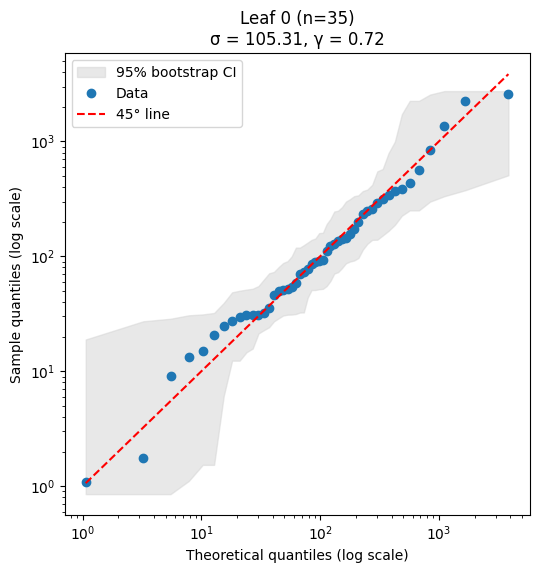

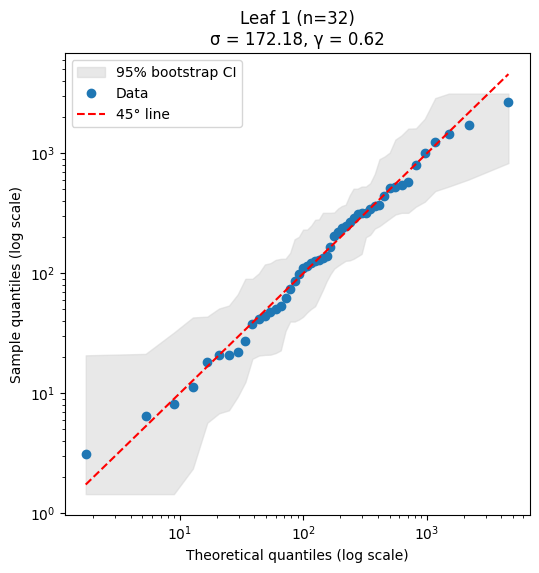

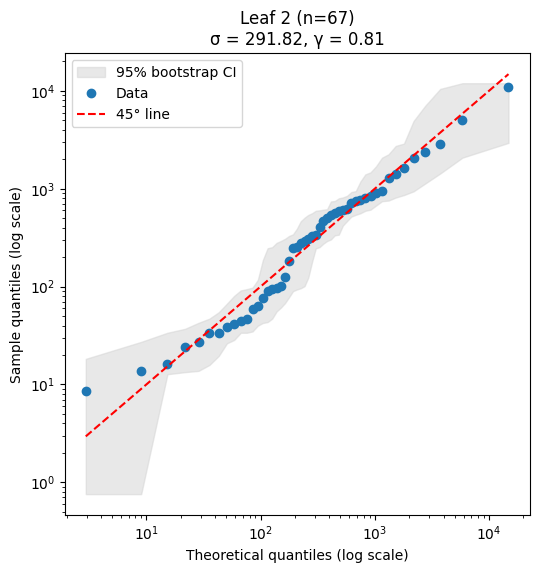

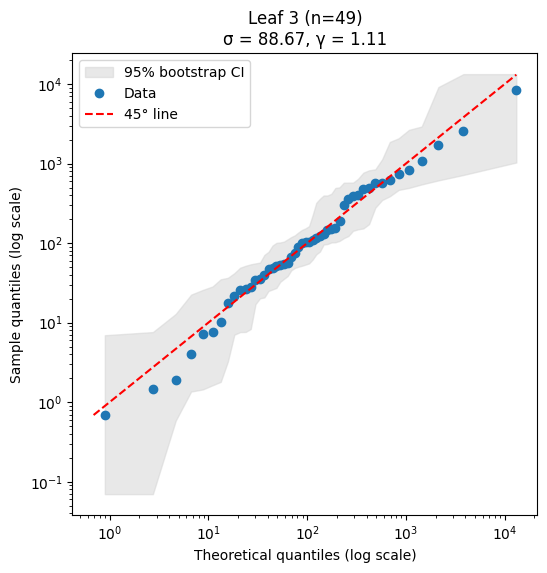

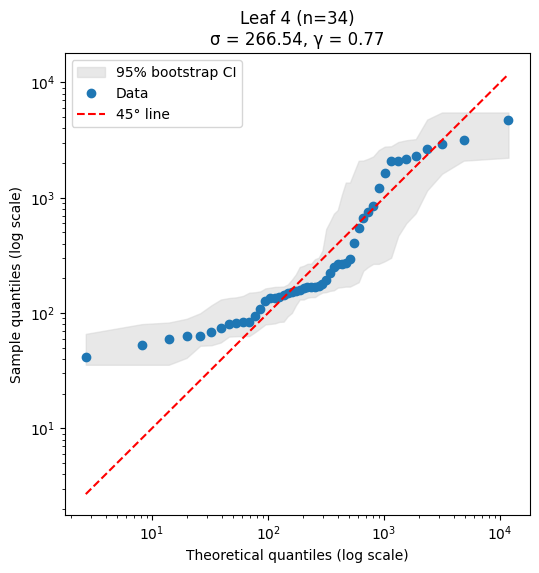

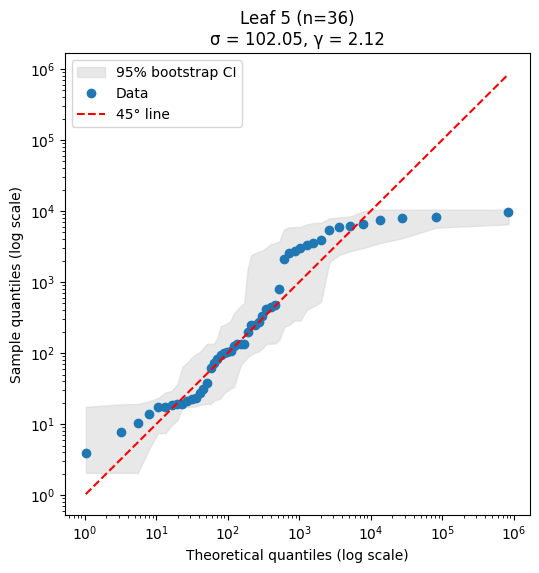

In [ ]:
graphs.plot_gp_tree_qq(gpd_tail_tree_pruned, X_tail, y_tail)


In [ ]:
importance=pd.DataFrame(importances)
importance.head()

,name,importance
0,8. Regulation_lag1,0.016438
1,"Category_Clients, Products & Business Practices",0.006175
2,Fiscal Policy (Taxes OR Spending)_lag1,0.001798
3,1. Economic Policy Uncertainty_lag1,0.000000
4,3. Taxes_lag1,0.000000


In [ ]:
# 모듈 헬퍼 준비
find_leaf = M.find_leaf
get_leaves = M._get_all_leaves

def _get_leaf_params(leaf):
    gp = getattr(leaf, "gpd_params", None)
    return (np.nan, np.nan) if gp is None else (float(gp[0]), float(gp[1]))

# CI 계산
cis = M.leaf_confidence_intervals(
    gpd_tail_tree_pruned, X_tail, y_tail,
    find_leaf=find_leaf, get_leaves=get_leaves, get_leaf_params=_get_leaf_params
)

# 보기 좋게 출력 (+ 리프별 샘플 수)
leaf_objs = np.array([find_leaf(gpd_tail_tree_pruned, X_tail[i]) for i in range(len(X_tail))], dtype=object)
leaves = get_leaves(gpd_tail_tree_pruned)

print("\n===== Leaf-wise γ 95% CI =====")
for i, rec in enumerate(cis):
    gamma = rec.get("gamma", np.nan)
    lo, hi = (rec.get("ci_95", [np.nan, np.nan]) + [np.nan, np.nan])[:2]
    n_i = int(np.sum(leaf_objs == leaves[i])) if i < len(leaves) else 0
    print(f"Leaf#{i:02d}  N={n_i:4d}   γ={gamma: .3f}   CI95=[{lo: .3f}, {hi: .3f}]")



===== Leaf-wise γ 95% CI =====
Leaf#00  N=  35   γ= 0.718   CI95=[ 0.166,  1.269]
Leaf#01  N=  32   γ= 0.622   CI95=[ 0.014,  1.229]
Leaf#02  N=  67   γ= 0.813   CI95=[ 0.332,  1.295]
Leaf#03  N=  49   γ= 1.109   CI95=[ 0.495,  1.723]
Leaf#04  N=  34   γ= 0.774   CI95=[ 0.216,  1.332]
Leaf#05  N=  36   γ= 2.123   CI95=[ 1.082,  3.164]


In [ ]:
import numpy as np
import scipy.stats as st

def hill_ci(gamma_hat, n_exceed, alpha=0.05):
    """Asymptotic normal CI for Hill estimator"""
    se = gamma_hat / np.sqrt(n_exceed)
    z = st.norm.ppf(1 - alpha/2)
    return gamma_hat - z*se, gamma_hat + z*se

print("\n===== Leaf-wise γ 95% CI (Asymptotic) =====")
for i, rec in enumerate(cis):
    gamma = rec.get("gamma", np.nan)
    n_i = int(np.sum(leaf_objs == leaves[i])) if i < len(leaves) else 0
    if np.isnan(gamma) or n_i < 30:  # 샘플 적으면 skip
        lo, hi = np.nan, np.nan
    else:
        lo, hi = hill_ci(gamma, n_i, alpha=0.05)
    print(f"Leaf#{i:02d}  N={n_i:4d}   γ={gamma: .3f}   CI95=[{lo: .3f}, {hi: .3f}]")



===== Leaf-wise γ 95% CI (Asymptotic) =====
Leaf#00  N=  35   γ= 0.718   CI95=[ 0.480,  0.955]
Leaf#01  N=  32   γ= 0.622   CI95=[ 0.406,  0.837]
Leaf#02  N=  67   γ= 0.813   CI95=[ 0.619,  1.008]
Leaf#03  N=  49   γ= 1.109   CI95=[ 0.799,  1.420]
Leaf#04  N=  34   γ= 0.774   CI95=[ 0.514,  1.034]
Leaf#05  N=  36   γ= 2.123   CI95=[ 1.429,  2.816]


##AIC

In [ ]:
# ================== POST-FIT EVAL: AIC/BIC, VaR, ES, GOF ==================

# ★ 1) raw y (초과치 아님) 준비
y_tail_raw = y_all_data[mask_tail]        # raw tail values
y_tail_excess = y_tail                    # (이미 있음) excess = y - u_threshold

# ★ 2) 네임스페이스 통일 (patched 모듈 함수 바인딩)
find_leaf_fn  = l1_l2_gpd_patched_new_catprune.find_leaf
get_leaves_fn = l1_l2_gpd_patched_new_catprune._get_all_leaves

# ★ 3) LN-only 트리도 patched 모듈로 생성 + 파라미터 부여
ln_only_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l1(
    X_all_data, y_all_data, feature_names_list, min_leaf=30, max_depth=4
)
l1_l2_gpd_patched_new_catprune.assign_lognorm_params(
    ln_only_tree, X_all_data, y_all_data, trunc_right=None
)

# 4) (선택) Bulk 모델로는 L2 트리 사용한 혼합 ln+gpd 성능을 보고 싶다면
tree_ln_for_mix  = l2_bulk_tree                      # bulk용 LN 트리
tree_gpd_for_mix = gpd_tail_tree_pruned              # tail용 GPD 트리 (없으면 None)

# 5) 모델 로그가능도/정보기준
ll_ln, k_ln, aic_ln, bic_ln = model_loglik_aic_bic(
    ln_only_tree, None,
    X_all_data, y_all_data,                      # LN-only: bulk=전체
    np.empty((0, X_all_data.shape[1])), np.empty(0),  # tail 없음
    u_threshold,
    find_leaf=find_leaf_fn, get_leaves=get_leaves_fn
)

if tree_gpd_for_mix is not None:
    ll_mix, k_mix, aic_mix, bic_mix = model_loglik_aic_bic(
        tree_ln_for_mix, tree_gpd_for_mix,
        X_bulk, y_bulk,                         # bulk set
        X_tail, y_tail_raw,                     # ★ raw tail 필요!
        u_threshold,
        find_leaf=find_leaf_fn, get_leaves=get_leaves_fn
    )
else:
    ll_mix, k_mix, aic_mix, bic_mix = (np.nan, np.nan, np.nan, np.nan)

print(f"[LN Only]  logL={ll_ln:.1f}, k={k_ln}, AIC={aic_ln:.1f}, BIC={bic_ln:.1f}")
if tree_gpd_for_mix is not None:
    print(f"[LN+GPD]  logL={ll_mix:.1f}, k={k_mix}, AIC={aic_mix:.1f}, BIC={bic_mix:.1f}")
else:
    print("[LN+GPD]  (tail 표본 부족으로 GPD 트리 없음)")

# 6) VaR / ES
var_ln  = unconditional_var_ln(ln_only_tree, get_leaves=get_leaves_fn, alpha=0.99)
es_ln   = unconditional_es_ln(ln_only_tree,  get_leaves=get_leaves_fn, alpha=0.99)

if tree_gpd_for_mix is not None:
    var_mix = unconditional_var_mix(tree_ln_for_mix, tree_gpd_for_mix, u_threshold,
                                    get_leaves=get_leaves_fn, alpha=0.99)
    es_mix  = unconditional_es_mix (tree_ln_for_mix, tree_gpd_for_mix, u_threshold,
                                    get_leaves=get_leaves_fn, alpha=0.99)
    print(f"99% VaR | LN Only = {var_ln:,.0f}   LN+GPD = {var_mix:,.0f}")
    print(f"99% ES  | LN Only = {es_ln:,.0f}   LN+GPD = {es_mix:,.0f}")
else:
    print(f"99% VaR | LN Only = {var_ln:,.0f}")
    print(f"99% ES  | LN Only = {es_ln:,.0f}")

# 7) GPD 리프별 GOF (KS/AD) — excess 필요
if tree_gpd_for_mix is not None:
    gof_df = gpd_gof_leafwise(
        tree_gpd_for_mix, X_tail, y_tail_excess,
        find_leaf=find_leaf_fn, get_leaves=get_leaves_fn, method="both"
    )
    pd.set_option('display.float_format', '{:,.3f}'.format)
    print("\n=== GPD Leaf-wise KS / AD Results ===")
    print(gof_df.to_string(index=False))


[LN Only]  logL=-14127.0, k=24, AIC=28302.0, BIC=28456.2
[LN+GPD]  logL=-14260.5, k=36, AIC=28593.0, BIC=28824.3
99% VaR | LN Only = 599   LN+GPD = 458
99% ES  | LN Only = 4,593   LN+GPD = inf

=== GPD Leaf-wise KS / AD Results ===
        leaf_id  n   sigma  gamma  KS stat  KS p  AD stat  AD p
132107675161024 36 102.051  2.123    0.149 0.366    0.677 0.077
132107675164224 32 172.177  0.622    0.068 0.996    0.165 1.000
132107675164608 49  88.668  1.109    0.071 0.949    0.354 0.486
132107675164992 35 105.314  0.718    0.068 0.993    0.209 1.000
132107675169088 34 266.540  0.774    0.152 0.376    1.285 0.002
132107675169600 67 291.820  0.813    0.096 0.533    0.732 0.056


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

# ──────────────────────────────────────────────
# 0) Monte-Carlo 기반 VaR/ES 계산 (ppf 사용 안 함)
# ──────────────────────────────────────────────
def mc_var_es(dist, params, alpha=0.99, n_mc=300_000, random_state=42):
    """
    dist   : scipy.stats 배포( .rvs 가능 )
    params : dist.fit(...) 결과 파라미터 (튜플)
    alpha  : 신뢰수준 (예: 0.99)
    n_mc   : MC 표본 수
    """
    rng = np.random.default_rng(random_state)
    samples = dist.rvs(*params, size=n_mc, random_state=rng)

    # 샘플 기반 VaR/ES
    var_alpha = np.quantile(samples, alpha)
    tail = samples[samples >= var_alpha]
    # tail이 비면 방어적 처리
    if tail.size == 0:
        k = max(1, int(np.ceil(0.001 * n_mc)))
        tail = np.partition(samples, -k)[-k:]
    es_alpha = float(tail.mean())
    return float(var_alpha), es_alpha

# ──────────────────────────────────────────────
# 1) 적합 + AIC/BIC + (MC) VaR + (MC) ES
# ──────────────────────────────────────────────
def fit_score_var_es(dist, data, name,
                     fix_loc0=True,    # NIG에는 False 권장
                     alpha=0.99,
                     n_es_mc=300_000,
                     random_state=42):
    """
    dist, data, name, alpha 동일.
    n_es_mc : ES/ VaR 추정을 위한 MC 표본 수
    """
    try:
        data = np.asarray(data, dtype=float)
        data = data[np.isfinite(data)]
        if data.size == 0:
            raise ValueError("No valid data points.")

        # ① 분포 적합 (MLE)
        if fix_loc0:
            params = dist.fit(data, floc=0)   # loc을 0으로 고정 (NIG에는 비권장)
            k = len(params) - 1
        else:
            params = dist.fit(data)           # loc/scale/shape 모두 추정
            k = len(params)

        # ② 로그 가능도
        logpdf = dist.logpdf(data, *params)
        logpdf = logpdf[np.isfinite(logpdf)]
        logL   = float(logpdf.sum())
        n      = int(data.size)

        # ③ AIC / BIC
        aic = 2*k - 2*logL
        bic = np.log(n)*k - 2*logL

        # ④~⑤ VaR/ES (모두 MC로 계산 → ppf 사용 안 함)
        var_alpha, es_alpha = mc_var_es(dist, params, alpha, n_es_mc, random_state)

        return {
            "Distribution": name,
            "Log-Likelihood": logL,
            "AIC": aic,
            "BIC": bic,
            f"VaR {int(alpha*100)}%": var_alpha,
            f"ES  {int(alpha*100)}%": es_alpha
        }

    except Exception as e:
        return {
            "Distribution": name,
            "Log-Likelihood": f"Fit failed: {e}",
            "AIC": np.nan,
            "BIC": np.nan,
            f"VaR {int(alpha*100)}%": np.nan,
            f"ES  {int(alpha*100)}%": np.nan
        }

# ──────────────────────────────────────────────
# 2) 후보 분포 지정 & 실행
# ──────────────────────────────────────────────
candidates = {
    "Log-Normal":     (stats.lognorm,     True),
    "Gamma":          (stats.gamma,       True),
    "Weibull":        (stats.weibull_min, True),
    # NIG는 scipy.stats.norminvgauss (shape: a, b; loc, scale)
    # ★ floc=0 고정하지 마세요 → 수치 불안정 완화
    "NIG":            (stats.norminvgauss, False),
}

alpha = 0.99
results = [fit_score_var_es(dist, y_all_data, name,
                            fix_loc0=fix_loc0,   # NIG는 False
                            alpha=alpha,
                            n_es_mc=300_000,
                            random_state=42)
           for name, (dist, fix_loc0) in candidates.items()]

results_df = (pd.DataFrame(results)
                .sort_values("AIC", key=lambda s: s.fillna(np.inf))
                .reset_index(drop=True))

print(results_df)


  Distribution  Log-Likelihood        AIC        BIC   VaR 99%   ES  99%
0   Log-Normal     -14,878.145 29,760.291 29,773.141   344.444 1,022.174
1          NIG     -15,128.433 30,264.865 30,290.566 1,134.276 3,762.512
2      Weibull     -15,718.249 31,440.497 31,453.347   318.883   525.077
3        Gamma     -17,131.011 34,266.022 34,278.872   568.440   763.471



================  Model Comparison  ================

  Distribution  Log-Likelihood        AIC        BIC   VaR 99%   ES  99%  \
0       LN+GPD     -14,260.504 28,593.008 28,824.310   457.549       inf   
1   Log-Normal     -14,878.145 29,760.291 29,773.141   344.444 1,022.174   
2          NIG     -15,128.433 30,264.865 30,290.566 1,134.276 3,762.512   
3      Weibull     -15,718.249 31,440.497 31,453.347   318.883   525.077   
4        Gamma     -17,131.011 34,266.022 34,278.872   568.440   763.471   

       k  
0 36.000  
1    NaN  
2    NaN  
3    NaN  
4    NaN  


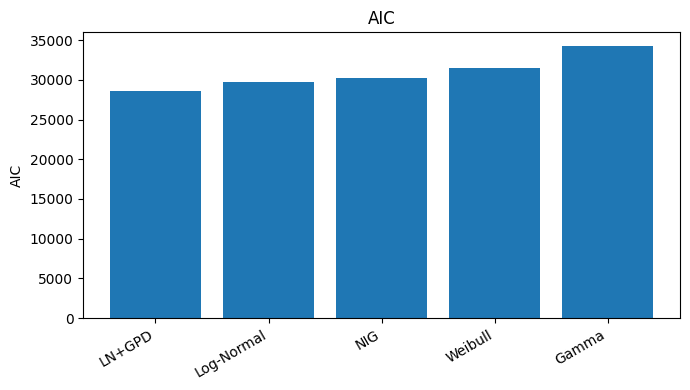

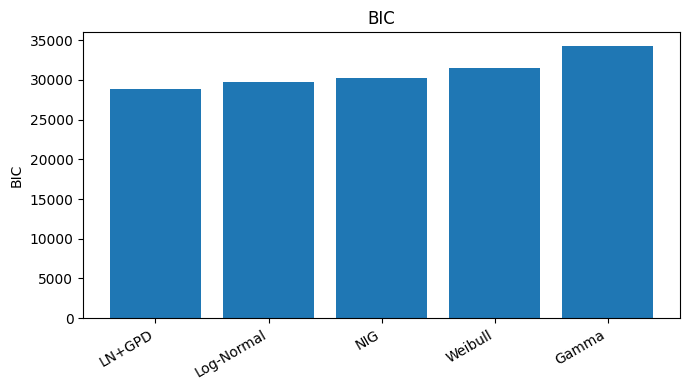

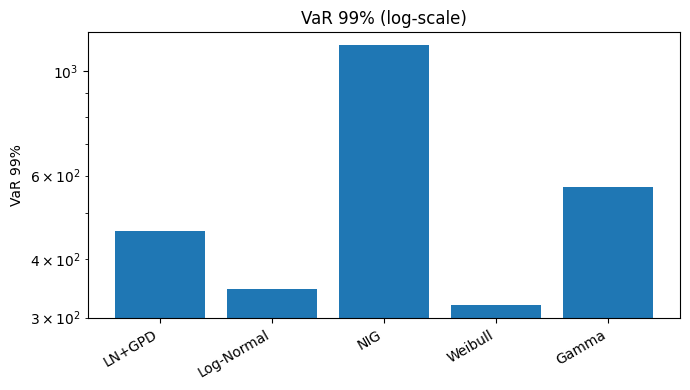

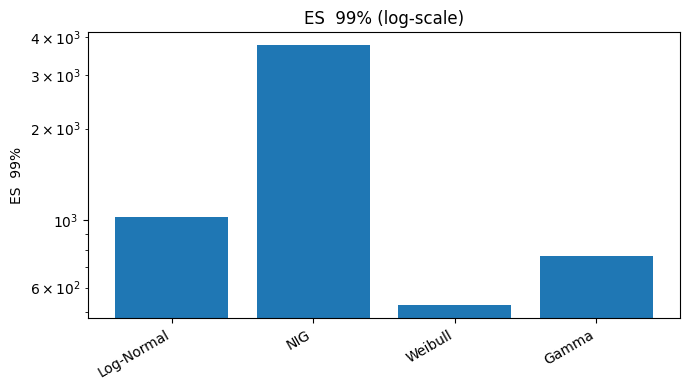

In [ ]:
# ──────────────────────────────────────────────
# 0) Tree 모델 행을 만들어 results_df 와 합치기
# ──────────────────────────────────────────────
tree_rows = pd.DataFrame([
#    {"Distribution": "LN‑Tree",  "Log-Likelihood": ll_ln,  "k": k_ln,
#     "AIC": aic_ln,  "BIC": bic_ln,
 #    "VaR 99%": var_ln,  "ES  99%": es_ln},
    {"Distribution": "LN+GPD",   "Log-Likelihood": ll_mix, "k": k_mix,
     "AIC": aic_mix, "BIC": bic_mix,
     "VaR 99%": var_mix, "ES  99%": es_mix}
])

full_df = (pd.concat([results_df, tree_rows], ignore_index=True)
             .sort_values("AIC")
             .reset_index(drop=True))

print("\n================  Model Comparison  ================\n")
print(full_df)

# ──────────────────────────────────────────────
# 1) AIC / BIC   (로그축 X)
# ──────────────────────────────────────────────
import matplotlib.pyplot as plt

for metric in ["AIC", "BIC"]:
    plt.figure(figsize=(7,4))
    plt.bar(full_df["Distribution"], full_df[metric])
    plt.title(f"{metric}")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

# ──────────────────────────────────────────────
# 2) VaR / ES   (log‑scale로 값 차이를 보기 좋게)
# ──────────────────────────────────────────────
for metric in ["VaR 99%", "ES  99%"]:
    y = pd.to_numeric(full_df[metric], errors="coerce").to_numpy(dtype=float)
    y_plot = np.where(np.isfinite(y) & (y > 0), y, np.nan)  # 🔧 inf/<=0 → NaN
    plt.figure(figsize=(7,4))
    plt.bar(full_df["Distribution"], y_plot)
    plt.yscale("log")
    plt.title(f"{metric} (log-scale)")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()



##Insurance

In [ ]:
loss_business_line = loss_df_finance[['Date', 'Current Value of Loss', 'Business_line']]

loss_by_business = (
    loss_business_line
    .groupby('Business_line', as_index=False)
    .agg({'Current Value of Loss': 'sum'}).sort_values('Current Value of Loss',ascending=False)  # Date 제외
)

print(loss_by_business)


                               Business_line  Current Value of Loss
14                             Manufacturing          560932.573185
6                                    Banking          302262.486954
15                        Markets & Treasury          213882.020350
12                                 Insurance          111524.404294
17                                    Mining          105680.455505
26                                 Utilities           92062.103355
11                               Information           90866.078612
4                        Asset & Wealth Mgmt           81127.211013
7                       Brokerage & Advisory           53847.653886
21                     Professional Services           45048.866263
20                                    Others           42964.901939
13                        Investment Banking           41731.369352
10           Health Care & Social Assistance           36589.189900
24                              Retail Trade    

In [ ]:
loss_manufacturing= loss_df_finance[loss_df_finance['Business_line'] == 'Insurance'].copy()


In [ ]:
loss_manufacturing.head()

,Date,Event Risk Category,Current Value of Loss,Business_line
1799,1979,"Clients, Products & Business Practices",8.844700,Banking
1282,1979,Internal Fraud,2.304687,Banking
1654,1979,Internal Fraud,12.408634,Banking
1707,1979,"Clients, Products & Business Practices",6.328597,Banking
7302,1979,"Clients, Products & Business Practices",11.329346,Banking


In [ ]:
loss_manufacturing['Event Risk Category'].value_counts()

,count
Event Risk Category,
External Fraud,1880
"Clients, Products & Business Practices",1449
Internal Fraud,1282
Employment Practices and Workplace Safety,131
"Execution, Delivery & Process Management",103
Damage to Physical Assets,40
Business Disruption and System Failures,6


In [ ]:
# Encode 'Event Risk Category'
df_encoded_a = pd.get_dummies(loss_manufacturing, columns=['Event Risk Category'], prefix='Category')

# Use the result of the first encoding as input for the second encoding
df_encoded_b = df_encoded_a.copy()
df_encoded_b.drop(columns=['Business_line'], inplace=True)

# Final encoded DataFrame
loss_manufacturing = df_encoded_b.copy()


In [ ]:
import re

# ① CSV 읽기
cpu = pd.read_csv('/content/drive/MyDrive/CPU index.csv')[['date', 'cpu_index']]

# ② 전처리 ── 공백 제거
cpu['date'] = cpu['date'].str.strip()

# ③ 'YY-Mon' → 'Mon-YY' 로 재배열
cpu['date'] = cpu['date'].str.replace(
    r'^(\d{2})-([A-Za-z]{3})$',   # 2자리 연도-3자리 월
    r'\2-\1',                     # 월-연도로 바꾸기
    regex=True, flags=re.IGNORECASE
)

# ④ datetime 파싱
cpu['date'] = pd.to_datetime(cpu['date'], format='%b-%y', errors='coerce')

# ⑤ 원하는 포맷(문자열)으로 출력하거나, 월 Period 로도 사용 가능
cpu['date'] = cpu['date'].dt.strftime('%Y-%m')      # 문자열 형태


In [ ]:
import pandas as pd
import numpy as np
from functools import reduce

file_paths = {
    "us_cpi": "/content/drive/MyDrive/us_cpi.csv",
    "us_unemp": "/content/drive/MyDrive/us_unemp.csv",
    "us_vix": "/content/drive/MyDrive/us_vix.csv",
    "us_m1": "/content/drive/MyDrive/us_m1.csv",
    "us_home_price": "/content/drive/MyDrive/us_home price index.csv",
    "us_T10Y2Y": "/content/drive/MyDrive/us_T10Y2Y.csv",
    "sp500": "/content/drive/MyDrive/sp500_monthly.csv",
}

# Load
us_cpi = pd.read_csv(file_paths["us_cpi"])
us_unemp = pd.read_csv(file_paths["us_unemp"])
us_m1 = pd.read_csv(file_paths["us_m1"])
us_home_price = pd.read_csv(file_paths["us_home_price"])
us_T10Y2Y = pd.read_csv(file_paths["us_T10Y2Y"])
sp500 = pd.read_csv(file_paths["sp500"], skiprows=2)

# Rename columns
us_T10Y2Y.rename(columns={'T10Y2Y': '10_2'}, inplace=True)
us_home_price.rename(columns={'USSTHPI': 'House Price Index'}, inplace=True)
us_m1.rename(columns={'WM1NS': 'M1'}, inplace=True)
us_cpi.rename(columns={'CPIAUCSL': 'CPI'}, inplace=True)
us_unemp.rename(columns={'UNRATE': 'Unemployment Rate'}, inplace=True)
sp500.rename(columns={'Unnamed: 1': 'Close'}, inplace=True)
sp500 = sp500.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4", "Unnamed: 5"])
cpu.rename(columns={'date': 'Date'}, inplace=True)


# Date 처리 및 연 단위 평균
for df in [us_cpi, us_unemp, us_m1, us_home_price, us_T10Y2Y, sp500,cpu]:
    df.rename(columns={df.columns[0]: "Date"}, inplace=True)
    df["Date"] = pd.to_datetime(df["Date"]).dt.year

us_T10Y2Y = us_T10Y2Y.groupby("Date").mean().reset_index()
us_home_price = us_home_price.groupby("Date").mean().reset_index()
us_m1 = us_m1.groupby("Date").mean().reset_index()
us_cpi = us_cpi.groupby("Date").mean().reset_index()
us_unemp = us_unemp.groupby("Date").mean().reset_index()
sp500 = sp500.groupby("Date").mean().reset_index()
cpu = cpu.groupby("Date").mean().reset_index()


# log-diff 처리
macro_dfs = {

    'Close_diff': (sp500, 'Close'),
}

# diff 열 추가
for diff_col, (df, col) in macro_dfs.items():
    df[diff_col] = np.log(df[col]).diff()

# sp500의 첫 번째 NaN만 특정 값으로 채움
sp500['Close_diff'].fillna(0.1635259493925565, inplace=True)

# 병합
dfs = [us_T10Y2Y, us_home_price, us_m1, us_cpi, us_unemp, sp500,cpu]
df_merged_macro = reduce(lambda left, right: pd.merge(left, right, on="Date", how="inner"), dfs)

# 최종 lag 데이터
df_merged_macro_lag = df_merged_macro[df_merged_macro["Date"] >= 1980].copy()
df_merged_macro_lag['Date'] = df_merged_macro_lag['Date'].astype(str)


/tmp/ipython-input-852055941.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sp500['Close_diff'].fillna(0.1635259493925565, inplace=True)


In [ ]:
import numpy as np
import pandas as pd
from functools import reduce
from sklearn.preprocessing import MinMaxScaler
from scipy.optimize import minimize
from scipy.stats import genpareto
import copy
#1986부터 사용
#############################################
# 1. 데이터 전처리 (연 단위)
#############################################
# (1) 엑셀 파일 읽기 및 날짜 정리
# 실제 파일 경로로 수정하세요.

epu_kr_path = '/content/drive/MyDrive/Korea_Overall_EPU.xlsx'
epu_kr_cat_path = '/content/drive/MyDrive/Korea_Categorical_PU_Indices.xlsx'
epu_usa_path = '/content/drive/MyDrive/US_Policy_Uncertainty_Data.xlsx'
epu_usa_cat_path = '/content/drive/MyDrive/Categorical_EPU_Data.xlsx'


# 미국 EPU 데이터
epu_usa = pd.read_excel(epu_usa_path)
epu_usa_cat = pd.read_excel(epu_usa_cat_path)
# 연도만 추출 (datetime 변환 후 정수형으로)
epu_usa['Year'] = pd.to_datetime(epu_usa['Year'], format='%Y').dt.year.astype(int)
epu_usa_cat['Year'] = pd.to_datetime(epu_usa_cat['Year'], format='%Y').dt.year.astype(int)
# 연도 필터링 (1985~2022)
epu_usa_cl = epu_usa[(epu_usa['Year'] < 2023)].copy()
epu_usa_cat_cl = epu_usa_cat[ (epu_usa_cat['Year'] < 2023)].copy()
# 최종적으로 'Date' 컬럼에 연도만(문자형) 저장
epu_usa_cl['Date'] = epu_usa_cl['Year'].astype(str)
epu_usa_cat_cl['Date'] = epu_usa_cat_cl['Year'].astype(str)
epu_usa_cl_lag = epu_usa_cl.copy()
epu_usa_cat_cl_lag = epu_usa_cat_cl.copy()


epu_usa_cl['Date'] = epu_usa_cl['Year'].astype(str)

epu_overall = (
    epu_usa_cl
    .groupby('Date')[['Three_Component_Index','News_Based_Policy_Uncert_Index']]
    .mean()
    .reset_index()
)

# 2) 범주형 EPU 연평균 집계
# ————————
cat_cols = [
    '1. Economic Policy Uncertainty','2. Monetary policy',
    'Fiscal Policy (Taxes OR Spending)','3. Taxes',
    '4. Government spending','5. Health care',
    '6. National security','7. Entitlement programs',
    '8. Regulation','Financial Regulation',
    '9. Trade policy','10. Sovereign debt, currency crises'
]
epu_usa_cat_cl['Date'] = epu_usa_cat_cl['Year'].astype(str)

epu_cats = (
    epu_usa_cat_cl
    .groupby('Date')[cat_cols]
    .mean()
    .reset_index()
)

# 3) 매크로 + EPU(전체+범주) 병합
# ———————————————
df_macro_epu = (
    df_merged_macro_lag
    .merge(epu_overall, on='Date', how='inner')
    .merge(epu_cats,    on='Date', how='inner')
)

# 4) 최종: 이벤트 손실(≈433행)과 1:1 병합
# ——————————————————————
final_df = df_macro_epu.merge(loss_manufacturing, on='Date', how='inner')




In [ ]:
df_merged=final_df.copy()
df_merged['Exceedance']=df_merged['Current Value of Loss']

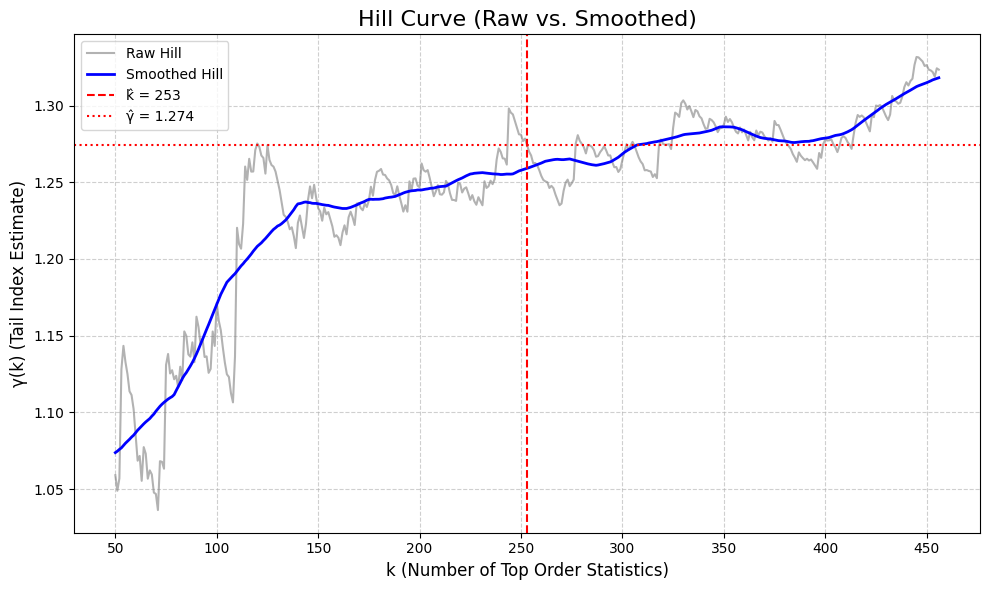

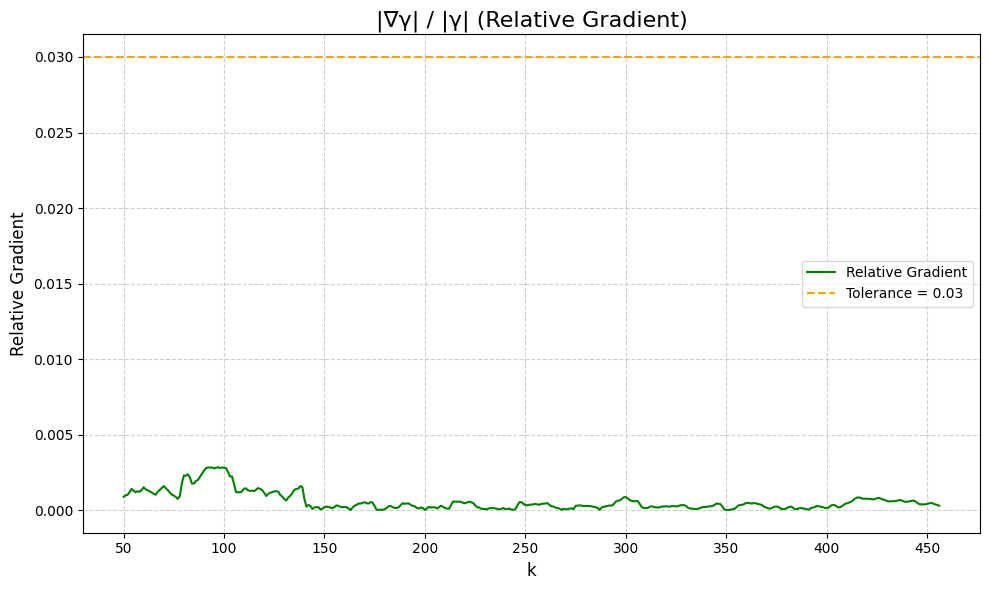

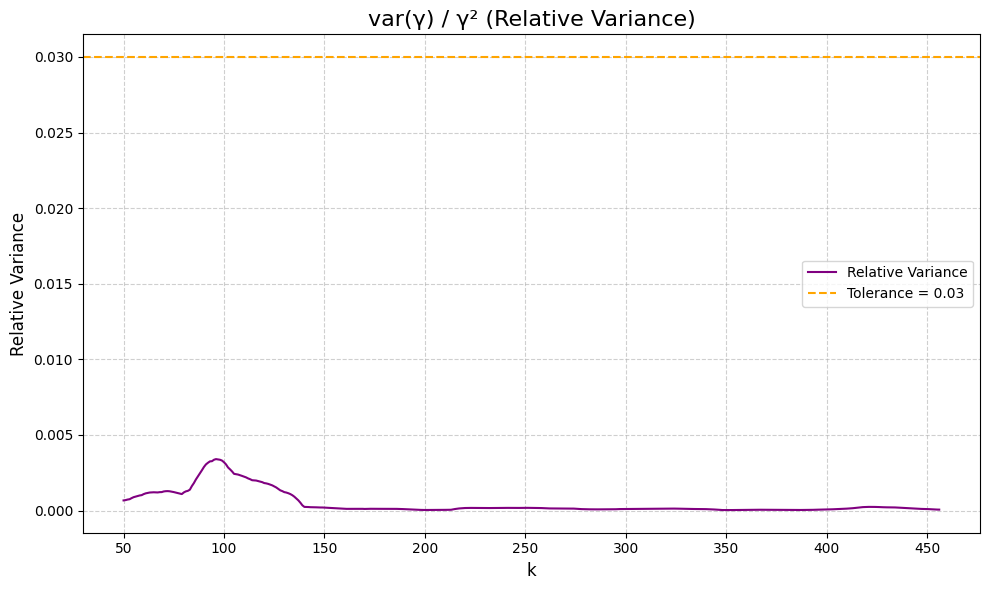

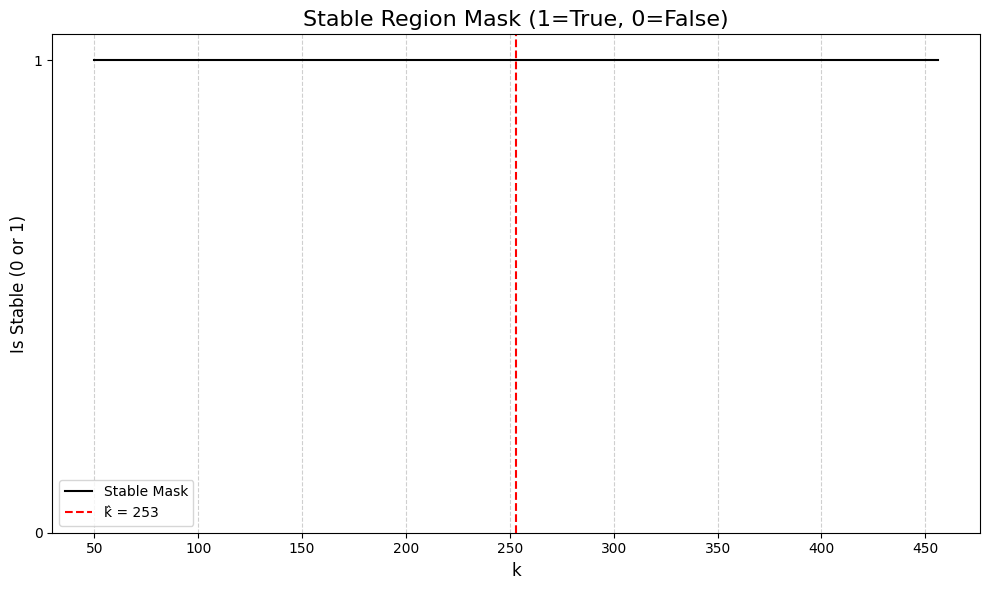


--- Results ---
Estimated Threshold (u_hat): 102.5392
Number of Exceedances (k_hat): 253
Estimated Tail Index (gamma_hat): 1.2741
----------------


In [ ]:
# hill_plots.py ─────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple, Dict, Any

# It's assumed that the 'thresholding' module you created is in the same folder.
from hill_plot_new_patched import select_threshold, HillDiag

def _compute_hill_raw_curve(y: np.ndarray, ks: np.ndarray) -> np.ndarray:
    """
    Computes the raw (unsmoothed) Hill curve.
    γ_k = mean( log Y_(1..k) - log Y_(k+1) ), where Y are sorted positive values.
    """
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]
    y_desc = np.sort(y)[::-1]
    y_pos = y_desc[y_desc > 0]
    if y_pos.size < 2 or ks.size == 0: # Need at least 2 points to compute log-differences
        return np.array([])

    # Ensure k does not exceed valid index
    max_k = y_pos.size - 1
    valid_ks = ks[ks < max_k]
    if valid_ks.size == 0:
        return np.array([])

    return np.array([np.mean(np.log(y_pos[:k]) - np.log(y_pos[k])) for k in valid_ks], dtype=float)

def plot_hill_curve(
    y: np.ndarray,
    diag: HillDiag,
    k_hat: int,
    gamma_hat: float,
    *,
    title: str = "Hill Curve (Raw vs. Smoothed)",
) -> None:
    """
    Plots the Hill curve (raw vs. smoothed) and the estimated point (k_hat, gamma_hat).
    """
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot Hill curve.")
        return

    gamma_raw = _compute_hill_raw_curve(y, diag.k_grid)

    plt.figure(figsize=(10, 6))
    if gamma_raw.size:
        # Match raw curve to its valid k-grid
        max_k_raw = y.size - 1
        valid_ks_raw = diag.k_grid[diag.k_grid < max_k_raw]
        plt.plot(valid_ks_raw, gamma_raw, label="Raw Hill", alpha=0.6, color='gray')

    plt.plot(diag.k_grid, diag.gamma_hat, label="Smoothed Hill", color='blue', linewidth=2)
    plt.axvline(k_hat, linestyle="--", color='red', label=f"k̂ = {k_hat}")
    plt.axhline(gamma_hat, linestyle=":", color='red', label=f"γ̂ = {gamma_hat:.3f}")

    plt.title(title, fontsize=16)
    # CHANGED: Korean -> English
    plt.xlabel("k (Number of Top Order Statistics)", fontsize=12)
    plt.ylabel("γ(k) (Tail Index Estimate)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_grad_norm(
    diag: HillDiag,
    *,
    rel_grad_tol: float,
    title: str = "|∇γ| / |γ| (Relative Gradient)"
) -> None:
    """Plots the relative gradient and the tolerance line."""
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot grad_norm.")
        return

    plt.figure(figsize=(10, 6))
    plt.plot(diag.k_grid, diag.grad_norm, label="Relative Gradient", color='green')
    plt.axhline(rel_grad_tol, linestyle="--", color='orange', label=f"Tolerance = {rel_grad_tol}")
    plt.title(title, fontsize=16)
    plt.xlabel("k", fontsize=12)
    plt.ylabel("Relative Gradient", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_var_rel(
    diag: HillDiag,
    *,
    rel_var_tol: float,
    title: str = "var(γ) / γ² (Relative Variance)"
) -> None:
    """Plots the relative variance and the tolerance line."""
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot var_rel.")
        return

    plt.figure(figsize=(10, 6))
    plt.plot(diag.k_grid, diag.var_rel, label="Relative Variance", color='purple')
    plt.axhline(rel_var_tol, linestyle="--", color='orange', label=f"Tolerance = {rel_var_tol}")
    plt.title(title, fontsize=16)
    plt.xlabel("k", fontsize=12)
    plt.ylabel("Relative Variance", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_stable_mask(
    diag: HillDiag,
    *,
    rel_grad_tol: float,
    rel_var_tol: float,
    gamma_min: float,
    k_hat: int,
    title: str = "Stable Region Mask (1=True, 0=False)"
) -> None:
    """
    Visualizes the stable region mask:
    stable = (grad_norm < rel_grad_tol) & (var_rel < rel_var_tol) & (gamma_hat > gamma_min)
    """
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot stable mask.")
        return

    stable = (diag.grad_norm < rel_grad_tol) & (diag.var_rel < rel_var_tol) & (diag.gamma_hat > gamma_min)

    plt.figure(figsize=(10, 6))
    plt.step(diag.k_grid, stable.astype(int), where="mid", label="Stable Mask", color='black')
    plt.axvline(k_hat, linestyle="--", color='red', label=f"k̂ = {k_hat}")
    plt.title(title, fontsize=16)
    plt.xlabel("k", fontsize=12)
    plt.ylabel("Is Stable (0 or 1)", fontsize=12)
    plt.yticks([0, 1])
    plt.legend()
    plt.grid(True, axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_hill_diagnostics(
    y: np.ndarray,
    *,
    # Parameters for thresholding._auto_hill
    k_min: int = 50,
    k_max_prop: float = 0.1,
    window: int = 61,
    rel_grad_tol: float = 0.04,
    rel_var_tol: float = 0.03,
    gamma_min: float = 0.02,
    min_plateau_len: int = 10,
    plateau_strategy: str = "longest",
    min_excess: Optional[int] = None,
    max_excess: Optional[int] = None,
    # Optional titles for individual plots
    titles: Optional[Dict[str, str]] = None,
    # For passing extra args to select_threshold
    extra_hill_kwargs: Optional[Dict[str, Any]] = None,
) -> Tuple[float, int, float, HillDiag]:
    """
    In a single call, this function:
      1) Runs select_threshold to get (u_hat, k_hat, gamma_hat, diag).
      2) Generates separate plots for Hill curve, grad_norm, var_rel, and stable mask.

    Returns: (u_hat, k_hat, gamma_hat, diag)
    """
    if titles is None:
        titles = {}
    if extra_hill_kwargs is None:
        extra_hill_kwargs = {}

    # Call select_threshold requesting the diagnostic data
    u_hat, k_hat, gamma_hat, diag = select_threshold(
        y,
        return_diag=True,
        k_min=k_min,
        k_max_prop=k_max_prop,
        window=window,
        rel_grad_tol=rel_grad_tol,
        rel_var_tol=rel_var_tol,
        gamma_min=gamma_min,
        min_plateau_len=min_plateau_len,
        plateau_strategy=plateau_strategy,
        min_excess=min_excess,
        max_excess=max_excess,
        **extra_hill_kwargs,
    )

    # 1) Hill Curve
    plot_hill_curve(
        y, diag, k_hat, gamma_hat,
        title=titles.get("hill", "Hill Curve (Raw vs. Smoothed)")
    )

    # 2) grad_norm
    plot_grad_norm(
        diag,
        rel_grad_tol=rel_grad_tol,
        title=titles.get("grad", "|∇γ| / |γ| (Relative Gradient)")
    )

    # 3) var_rel
    plot_var_rel(
        diag,
        rel_var_tol=rel_var_tol,
        title=titles.get("var", "var(γ) / γ² (Relative Variance)")
    )

    # 4) stable mask
    plot_stable_mask(
        diag,
        rel_grad_tol=rel_grad_tol,
        rel_var_tol=rel_var_tol,
        gamma_min=gamma_min,
        k_hat=k_hat,
        title=titles.get("stable", "Stable Region Mask (1=True, 0=False)")
    )

    return u_hat, k_hat, gamma_hat, diag


if __name__ == "__main__":

    # Run the diagnostic plotting function
    u_hat, k_hat, gamma_hat, diag = plot_hill_diagnostics(
        df_merged['Exceedance'],
        k_min=50,
        k_max_prop=0.1, # Use a larger proportion for better visualization
        window=61,
        rel_grad_tol=0.03,
        rel_var_tol=0.03, # Loosen var tolerance slightly for demo
        gamma_min=0.02,
        min_plateau_len=20,
        plateau_strategy="longest",
    )

    print("\n--- Results ---")
    print(f"Estimated Threshold (u_hat): {u_hat:.4f}")
    print(f"Number of Exceedances (k_hat): {k_hat}")
    print(f"Estimated Tail Index (gamma_hat): {gamma_hat:.4f}")
    print("----------------")

In [ ]:
n = len(df_merged['Exceedance'])
top_percent = (k_hat / n) * 100
print(f"Top {top_percent:.2f}% of data exceed threshold {u_hat:.2f}")


Top 5.55% of data exceed threshold 102.54


In [ ]:

df = df_merged.copy()

# 1) 연도 만들기
if not pd.api.types.is_integer_dtype(df['Date']):
    df['Year'] = pd.to_datetime(df['Date']).dt.year
else:
    df['Year'] = df['Date']

# 2) 대상/피처/카테고리 정의
target_col = 'Exceedance'  # 타깃은 연도 총합으로 집계
base_vars = ['10_2','House Price Index','M1','CPI','Unemployment Rate',
             'Close','Close_diff','Three_Component_Index',
             'News_Based_Policy_Uncert_Index','1. Economic Policy Uncertainty',
             '2. Monetary policy','Fiscal Policy (Taxes OR Spending)','3. Taxes',
             '4. Government spending','5. Health care','6. National security',
             '7. Entitlement programs','8. Regulation','Financial Regulation',
             '9. Trade policy','10. Sovereign debt, currency crises','cpu_index']

# 이미 차분된 컬럼(예: Close_diff)은 이중 차분 방지를 위해 제외 권장
base_vars_clean = [c for c in base_vars if c in df.columns and not c.endswith('_diff') and c != target_col]
cat_cols = [c for c in df.columns if c.startswith('Category_')]

# 3) 집계 규칙: 타깃=sum, 매크로(이미 연평균된 값)=first, 카테고리 더미=max
agg_dict = {
    target_col: 'sum',
    **{c: 'first' for c in base_vars_clean},
    **{c: 'max' for c in cat_cols}
}

# 4) 연도 단위로 집계 -> 정렬 -> 인덱스 리셋
df_year = (df.groupby('Year', as_index=False)
             .agg(agg_dict)
             .sort_values('Year')
             .reset_index(drop=True))

# 4-1) 연도별 사건 수(N_t) 계산 후 병합 (원하면 나중에 그랜저에 포함해서 테스트 가능)
cnt = df.groupby('Year').size().rename('N_t').reset_index()
df_year = df_year.merge(cnt, on='Year', how='left')

# 5) 타깃 안정화 (합은 스케일이 커서 log1p 권장; 음수 없을 때만)
if (df_year[target_col] >= 0).all():
    df_year[target_col] = np.log1p(df_year[target_col])

# 6) 숫자형 보정 및 결측 제거(Granger는 NaN 불가)
cols_to_numeric = [target_col] + base_vars_clean + cat_cols + ['N_t']
for col in cols_to_numeric:
    if col in df_year.columns:
        df_year[col] = pd.to_numeric(df_year[col], errors='coerce')

# 그랜저에 쓸 핵심 컬럼만 NaN 제거
df_granger = df_year.dropna(subset=[target_col] + base_vars_clean)

# 7) 그랜저 파이프라인 실행 (연 단위이므로 max_lag를 3으로 낮춤 권장)
res = granger_analysis.run_granger_analysis_pipeline(
    df_granger,
    base_vars=base_vars_clean,      # N_t도 원하면 base_vars에 추가해서 N_t→타깃 테스트 가능
    target_col=target_col,
    transform='auto',
    max_lag=3
)

summary_df = recent_lag.get_most_recent_granger_lags(
    granger_df=res,
    target_variable=target_col
)

print("--- 변수별 가장 빠른 유의미한 시차 (Lag) 요약 ---")
print(summary_df)


--- 1. Starting Analysis Pipeline ---

--- 2. Checking variable stationarity (ADF Test) ---
Stationary variables: ['10_2', '1. Economic Policy Uncertainty', '2. Monetary policy', 'Fiscal Policy (Taxes OR Spending)', '3. Taxes', '4. Government spending', '6. National security', '8. Regulation', '10. Sovereign debt, currency crises', 'Exceedance']
Non-stationary variables to be differenced: ['House Price Index', 'M1', 'CPI', 'Unemployment Rate', 'Close', 'Three_Component_Index', 'News_Based_Policy_Uncert_Index', '5. Health care', '7. Entitlement programs', 'Financial Regulation', '9. Trade policy', 'cpu_index']

--- 3. Applying 'auto' differencing ---

--- 4. Running Granger Causality Test on processed data ---
Base variables: ['10_2', 'House Price Index_diff', 'M1_diff', 'CPI_diff', 'Unemployment Rate_diff', 'Close_diff', 'Three_Component_Index_diff', 'News_Based_Policy_Uncert_Index_diff', '1. Economic Policy Uncertainty', '2. Monetary policy', 'Fiscal Policy (Taxes OR Spending)', '3. T

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print resul


--- 5. Analysis Complete ---
--- 변수별 가장 빠른 유의미한 시차 (Lag) 요약 ---
                          Causal_Var  Most_Recent_Lag
0     1. Economic Policy Uncertainty                1
1                           3. Taxes                1
2                      8. Regulation                1
3  Fiscal Policy (Taxes OR Spending)                1
4                            M1_diff                1


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print resul

In [ ]:
M = l1_l2_gpd_patched_new_catprune

# ---------- Main ----------
if __name__ == "__main__":

    # --- Configuration ---
    TARGET_VARIABLE = "Exceedance"
    DATE_COLUMN = "Date"
    START_YEAR = 1985

    # Granger Test based lags (example)
    selected_lags_dict = {
        '1. Economic Policy Uncertainty':[1],
        '3. Taxes':[1],
        '8. Regulation':[1],
        'Fiscal Policy (Taxes OR Spending)':[1],
        'M1_diff':[1]

    }

    # Categorical features (assumed to be 0/1 dummy encoded)
    categorical_cols_list = [
'Category_Business Disruption and System Failures',
       'Category_Clients, Products & Business Practices',
       'Category_Damage to Physical Assets',
       'Category_Employment Practices and Workplace Safety',
       'Category_Execution, Delivery & Process Management',
       'Category_External Fraud', 'Category_Internal Fraud'
    ]


    # --- Data Loading and Preparation ---
    # If df_merged is not defined, make a synthetic demo
    if 'df_merged' not in locals() or not isinstance(df_merged, pd.DataFrame):
        l1_l2_gpd_patched_new_catprune.logging.warning("'df_merged' DataFrame not found. Generating synthetic data.")
        n_years = 40
        dates = pd.date_range(start='1980-01-01', periods=n_years, freq='YS')
        data = {'Date': dates}
        all_needed_cols = list(selected_lags_dict.keys()) + categorical_cols_list + [TARGET_VARIABLE]
        rng = np.random.default_rng(42)
        for col in all_needed_cols:
            if col == TARGET_VARIABLE:  # positive, heavy-tailed-ish
                data[col] = rng.pareto(a=1.5, size=n_years) * 1000 + 1.0
            elif col.startswith("Category_"):
                data[col] = rng.integers(0, 2, size=n_years)
            else:
                data[col] = rng.standard_normal(n_years).cumsum() + 100.0
        df_merged = pd.DataFrame(data)

    # Create the dataset with lagged features
    try:
        df_model_ready, feature_names_list = l1_l2_gpd_patched_new_catprune.create_lagged_features(
            df=df_merged,
            target_col=TARGET_VARIABLE,
            lag_config=selected_lags_dict,
            date_col=DATE_COLUMN,
            start_year=START_YEAR,
            additional_features=categorical_cols_list
        )
    except Exception as e:
        l1_l2_gpd_patched_new_catprune.logging.error(f"Error creating lagged features: {e}")
        raise

    if df_model_ready.empty:
        l1_l2_gpd_patched_new_catprune.logging.error(
            "Resulting DataFrame is empty after processing. Check input data and parameters."
        )
        raise SystemExit(1)

        # ---------- Matrix build ----------
    features_df = (
        df_model_ready[feature_names_list]
          .apply(pd.to_numeric, errors='coerce')           # "0"/"1" → 0/1, non-numeric → NaN
          .replace([np.inf, -np.inf], np.nan)
    )

    # 간단한 결측 처리(중앙값 대체). 필요 시 본인 로직으로 교체 가능
    if features_df.isna().any().any():
        features_df = features_df.fillna(features_df.median(numeric_only=True))

    # 최종 설계: float 행렬로 강제
    X_all_data = features_df.to_numpy(dtype=float)

    # 타깃도 안전 변환
    y_all_data = (
        pd.to_numeric(df_model_ready[TARGET_VARIABLE], errors='coerce')
          .replace([np.inf, -np.inf], np.nan)
          .fillna(df_model_ready[TARGET_VARIABLE].median())
          .to_numpy(dtype=float)
    )

    # (선택) 디버그: 여전히 object가 섞였는지 체크
    if X_all_data.dtype != float:
        raise TypeError(f"Design matrix dtype must be float, got {X_all_data.dtype}")

    # ---------- Threshold (AS-IS from user) ----------
    # Do NOT touch user's threshold estimator; we expect u_hat to be defined by user.
    u_threshold = u_hat  # <-- as requested: use user-supplied threshold

    # ---------- Bulk / Tail split ----------
    mask_bulk = y_all_data <= u_threshold
    mask_tail = ~mask_bulk

    X_bulk, y_bulk = X_all_data[mask_bulk], y_all_data[mask_bulk]
    X_tail = X_all_data[mask_tail]
    y_tail = y_all_data[mask_tail] - u_threshold  # excesses for GPD

    l1_l2_gpd_patched_new_catprune.logging.info(
        f"Data split: Bulk = {len(y_bulk)} samples, Tail (Excesses) = {len(y_tail)} samples."
    )

    # Check tail size
    MIN_TAIL_SAMPLES = 50
    if len(y_tail) < MIN_TAIL_SAMPLES:
        l1_l2_gpd_patched_new_catprune.logging.warning(
            f"Tail dataset size ({len(y_tail)}) is small. GPD results may be unreliable."
        )

    # ---------- Model Fitting ----------

    # 1) L1 CART (Median) + LogNormal for Bulk
    l1_l2_gpd_patched_new_catprune.logging.info("Fitting L1 CART (Median) for Bulk Data...")
    l1_bulk_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l1(
        X_bulk, y_bulk, feature_names_list, min_leaf=20, max_depth=3
    )
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(l1_bulk_tree, X_bulk, y_bulk, trunc_right=u_threshold)

    print("\n===== L1 CART (Bulk, Median-based) =====")
    l1_l2_gpd_patched_new_catprune.print_tree_structure(l1_bulk_tree, feature_names_list)
    l1_l2_gpd_patched_new_catprune.validate_tree_structure(l1_bulk_tree)

    # 2) L2 CART (Mean) + LogNormal for Bulk
    l1_l2_gpd_patched_new_catprune.logging.info("Fitting L2 CART (Mean) for Bulk Data...")
    l2_bulk_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l2(
        X_bulk, y_bulk, feature_names_list, min_leaf=30, max_depth=4
    )
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(l2_bulk_tree, X_bulk, y_bulk, trunc_right=u_threshold)

    print("\n===== L2 CART (Bulk, Mean-based) =====")
    l1_l2_gpd_patched_new_catprune.print_tree_structure(l2_bulk_tree, feature_names_list)
    l1_l2_gpd_patched_new_catprune.validate_tree_structure(l2_bulk_tree)

    # 3) GPD CART for Tail (Excesses)
    gpd_tail_tree_pruned = None
    if len(y_tail) >= MIN_TAIL_SAMPLES:
        l1_l2_gpd_patched_new_catprune.logging.info("Fitting GPD CART for Tail Data (Excesses)...")

        # Grow initial large tree
        gpd_tail_tree_raw = l1_l2_gpd_patched_new_catprune.grow_tree_gpd(
            X_tail, y_tail, feature_names_list, min_leaf=max(30, int(0.05 * len(y_tail))), max_depth=4
        )

        # Repair, print, validate
        if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
            l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_raw)

        print("\n===== Raw GPD CART (Tail, Excesses) =====")
        l1_l2_gpd_patched_new_catprune.print_tree_structure(gpd_tail_tree_raw, feature_names_list)
        l1_l2_gpd_patched_new_catprune.validate_tree_structure(gpd_tail_tree_raw, min_samples_leaf=10)

        # CV pruning
        l1_l2_gpd_patched_new_catprune.logging.info("Pruning GPD CART using Cross-Validation...")
        try:
            cv_folds = min(5, max(2, len(y_tail) // 10))
            gpd_tail_tree_pruned, best_alpha_gpd = l1_l2_gpd_patched_new_catprune.prune_gpd_with_cv(
                gpd_tail_tree_raw, X_tail, y_tail,
                n_folds=cv_folds,
                cv_min_leaf_ratio=0.02,
                cv_min_leaf_floor=max(20, int(0.05 * len(y_tail))),  # robust floor
                use_one_se=True,
                use_mean_nll=True,
                guard_root=True
            )
            l1_l2_gpd_patched_new_catprune.logging.info(
                f"GPD CART Pruning complete. Best alpha = {best_alpha_gpd:.4g}"
            )

            if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
                l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_pruned)

            print("\n===== Pruned GPD CART (Tail, Excesses) =====")
            l1_l2_gpd_patched_new_catprune.print_tree_structure(gpd_tail_tree_pruned, feature_names_list)
            l1_l2_gpd_patched_new_catprune.validate_tree_structure(gpd_tail_tree_pruned, min_samples_leaf=10)

        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.error(
                f"GPD Tree Pruning failed: {e}. Using raw tree."
            )
            gpd_tail_tree_pruned = gpd_tail_tree_raw
            if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
                l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_pruned)
    else:
        l1_l2_gpd_patched_new_catprune.logging.warning(
            "Skipping GPD CART fitting due to insufficient tail data."
        )

    # ---------- Diagnostics: Moments, CI, Importance ----------
    if gpd_tail_tree_pruned is not None:
        # Warn if some leaves imply infinite mean (gamma >= 1)
        if hasattr(l1_l2_gpd_patched_new_catprune, "warn_leaf_moments"):
            l1_l2_gpd_patched_new_catprune.warn_leaf_moments(gpd_tail_tree_pruned, mean_guard=1.0, near_tol=0.95)

        # Leaf-wise CI for gamma
        try:
            # Many implementations use callbacks; we pass module's helpers if present
            ci_kwargs = {}
            if hasattr(l1_l2_gpd_patched_new_catprune, "find_leaf"):
                ci_kwargs["find_leaf"] = l1_l2_gpd_patched_new_catprune.find_leaf
            if hasattr(l1_l2_gpd_patched_new_catprune, "_get_all_leaves"):
                ci_kwargs["get_leaves"] = l1_l2_gpd_patched_new_catprune._get_all_leaves
            # Fallback getter for leaf params
            def _get_leaf_params(leaf):
                gp = getattr(leaf, "gpd_params", None)
                if gp is None:
                    return (np.nan, np.nan)
                return (float(gp[0]), float(gp[1]))
            ci_kwargs.setdefault("get_leaf_params", _get_leaf_params)

            cis = l1_l2_gpd_patched_new_catprune.leaf_confidence_intervals(
                gpd_tail_tree_pruned, X_tail, y_tail, **ci_kwargs
            )
            l1_l2_gpd_patched_new_catprune.logging.info(f"Leaf γ 95% CI (sample): {cis[:5] if isinstance(cis, list) else cis}")
        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.warning(f"Leaf CI computation skipped: {e}")

        # Permutation variable importance over tail
        try:
            imp_kwargs = {}
            if hasattr(l1_l2_gpd_patched_new_catprune, "find_leaf"):
                imp_kwargs["find_leaf"] = l1_l2_gpd_patched_new_catprune.find_leaf
            def _get_leaf_params2(leaf):
                gp = getattr(leaf, "gpd_params", None)
                if gp is None:
                    raise ValueError("Leaf has no GPD params")
                return (float(gp[0]), float(gp[1]))
            imp_kwargs["get_leaf_params"] = _get_leaf_params2

            importances = l1_l2_gpd_patched_new_catprune.permutation_variable_importance(
                gpd_tail_tree_pruned, X_tail, y_tail, feature_names_list, **imp_kwargs
            )
            # Sort & print top-10
            try:
                importances_sorted = sorted(importances, key=lambda t: t[1], reverse=True)
                topk = importances_sorted[:10]
                print("\n===== Permutation Variable Importance (Tail, top-10) =====")
                for name, score in topk:
                    print(f"{name:>40s} : {score: .6f}")
            except Exception:
                print("\n===== Permutation Variable Importance (Tail) =====")
                print(importances)
        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.warning(f"Permutation importance skipped: {e}")

    l1_l2_gpd_patched_new_catprune.logging.info("Script finished.")



    ln_only_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l1(
            X_all_data, y_all_data, feature_names_list,
            min_leaf=30, max_depth=4)
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(
            ln_only_tree, X_all_data, y_all_data, trunc_right=0.0)
    if gpd_tail_tree_pruned is not None:
      comparison_results =run_gpd_comparison()


===== L1 CART (Bulk, Median-based) =====
[Category_Clients, Products & Business Practices ≤ 0.5] (Gain=1698.460) N=4307
  [Category_Internal Fraud ≤ 0.5] (Gain=97.834) N=3188
    [Category_External Fraud ≤ 0.5] (Gain=86.082) N=2042
      Leaf: N=245, median=3.77, LN(mu=1.45, sigma=1.72)
      Leaf: N=1797, median=1.71, LN(mu=0.59, sigma=1.52)
    [3. Taxes_lag1 ≤ 117.1] (Gain=34.919) N=1146
      Leaf: N=718, median=1.32, LN(mu=0.43, sigma=1.64)
      Leaf: N=428, median=0.61, LN(mu=-0.20, sigma=1.40)
  [3. Taxes_lag1 ≤ 49.98] (Gain=100.177) N=1119
    [1. Economic Policy Uncertainty_lag1 ≤ 57.31] (Gain=9.131) N=118
      Leaf: N=59, median=5.89, LN(mu=2.13, sigma=1.95)
      Leaf: N=59, median=3.51, LN(mu=1.27, sigma=1.34)
    [8. Regulation_lag1 ≤ 105] (Gain=84.009) N=1001
      Leaf: N=511, median=9.90, LN(mu=2.58, sigma=1.73)
      Leaf: N=490, median=6.66, LN(mu=2.07, sigma=1.77)



===== L2 CART (Bulk, Mean-based) =====
[Category_Clients, Products & Business Practices ≤ 0.5] (Gain=104907.815) N=4307
  [Category_Employment Practices and Workplace Safety ≤ 0.5] (Gain=3767.651) N=3188
    [Category_Execution, Delivery & Process Management ≤ 0.5] (Gain=3007.205) N=3068
      [Fiscal Policy (Taxes OR Spending)_lag1 ≤ 46.98] (Gain=2139.384) N=2972
        Leaf: N=622, mean=3.67, LN(mu=0.11, sigma=1.41)
        Leaf: N=2350, mean=5.75, LN(mu=0.53, sigma=1.59)
      [1. Economic Policy Uncertainty_lag1 ≤ 121.5] (Gain=207.835) N=96
        Leaf: N=65, mean=9.99, LN(mu=1.26, sigma=1.85)
        Leaf: N=31, mean=13.13, LN(mu=1.56, sigma=1.91)
    [8. Regulation_lag1 ≤ 125.6] (Gain=640.922) N=120
      [1. Economic Policy Uncertainty_lag1 ≤ 68.35] (Gain=266.018) N=82
        Leaf: N=34, mean=10.64, LN(mu=1.54, sigma=1.30)
        Leaf: N=48, mean=14.29, LN(mu=1.75, sigma=1.80)
      Leaf: N=38, mean=7.81, LN(mu=1.32, sigma=1.45)
  [8. Regulation_lag1 ≤ 51.78] (Gain=6713.945


===== Pruned GPD CART (Tail, Excesses) =====
[8. Regulation_lag1 ≤ 159.3] (PenalizedGain=4.211) N=253
  [Category_Clients, Products & Business Practices ≤ 0.5] (PenalizedGain=2.553) N=217
    Leaf: N=35, GPD(σ=105.314, γ=0.718), NLL=223.1
    [8. Regulation_lag1 ≤ 89.67] (PenalizedGain=1.328) N=182
      [Fiscal Policy (Taxes OR Spending)_lag1 ≤ 50.54] (PenalizedGain=1.838) N=99
        Leaf: N=32, GPD(σ=172.177, γ=0.622), NLL=216.6
        Leaf: N=67, GPD(σ=291.820, γ=0.813), NLL=501.8
      [8. Regulation_lag1 ≤ 112.5] (PenalizedGain=3.459) N=83
        Leaf: N=49, GPD(σ=88.668, γ=1.109), NLL=323.1
        Leaf: N=34, GPD(σ=266.540, γ=0.774), NLL=250.2
  Leaf: N=36, GPD(σ=102.051, γ=2.123), NLL=278.9

===== Permutation Variable Importance (Tail) =====
[{'name': '8. Regulation_lag1', 'importance': 0.01643819666514845}, {'name': 'Category_Clients, Products & Business Practices', 'importance': 0.006174673503455161}, {'name': 'Fiscal Policy (Taxes OR Spending)_lag1', 'importance': 0.001

In [ ]:
graphs.gp_tree_lrt(gpd_tail_tree_pruned, X_tail, y_tail)

GP 트리 vs 단일 GP 적합 LRT 결과:
  GP 트리 로그우도 합: -1793.82
  단일 GP 로그우도: -1807.21
  LRT statistic = 26.78 (df = 10)
  p‑value = 2.825e-03 -> reject single GP model
  AIC (GP 트리) = 3611.64, AIC (단일 GP) = 3618.41


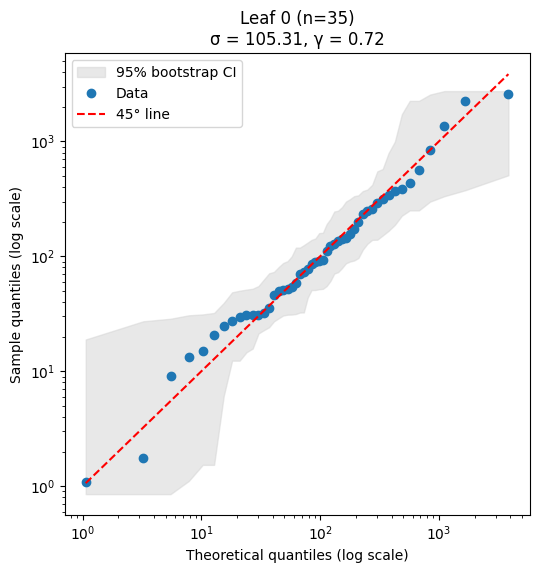

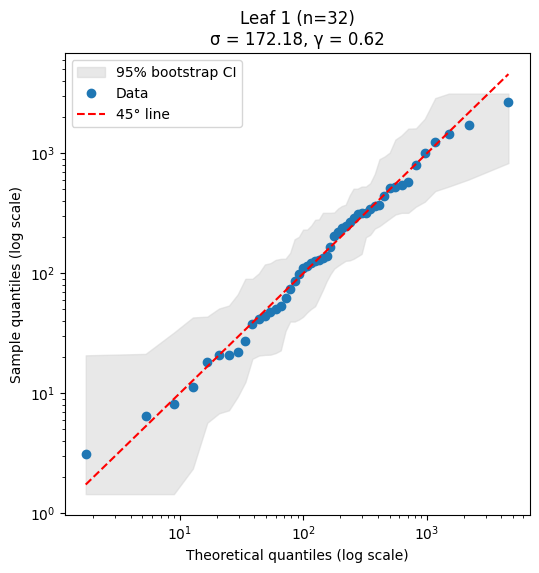

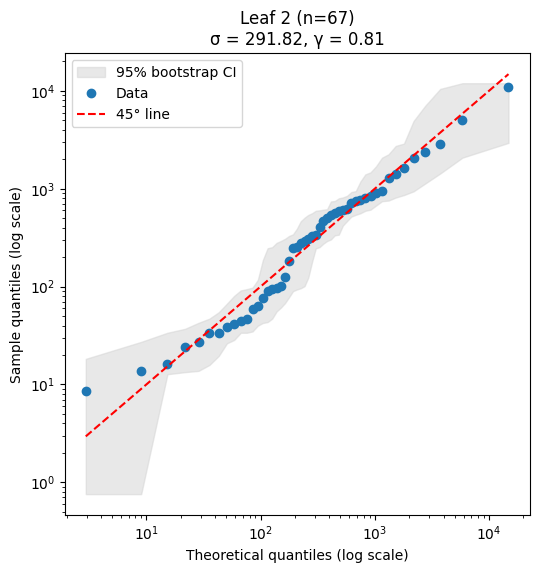

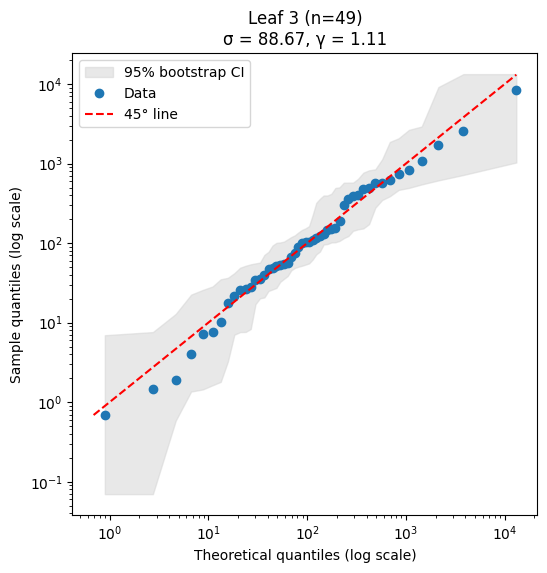

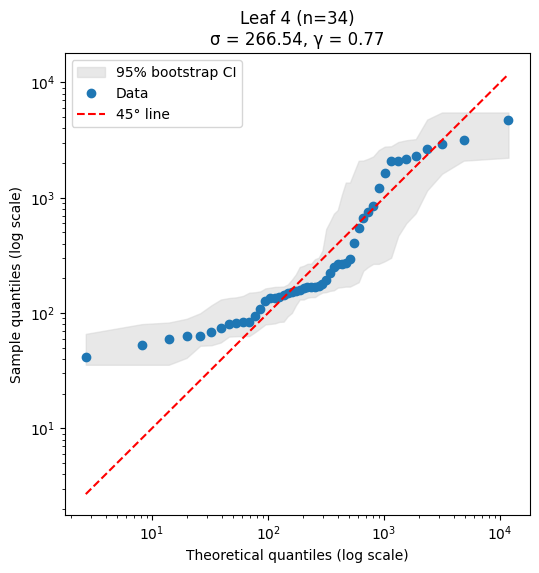

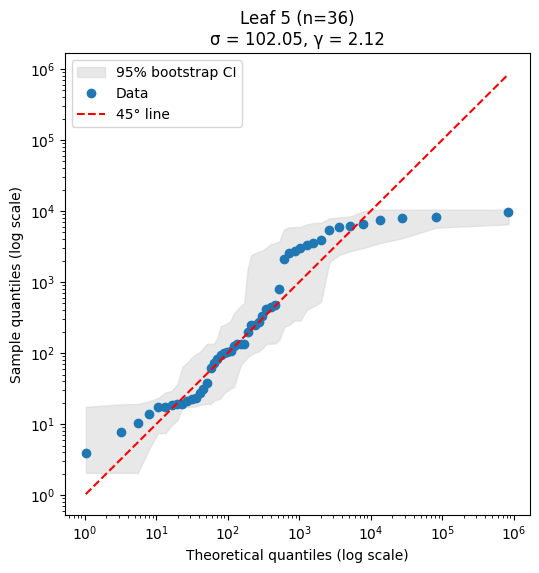

In [ ]:
graphs.plot_gp_tree_qq(gpd_tail_tree_pruned, X_tail, y_tail)


In [ ]:
importance=pd.DataFrame(importances)
importance.head()

,name,importance
0,8. Regulation_lag1,0.016438
1,"Category_Clients, Products & Business Practices",0.006175
2,Fiscal Policy (Taxes OR Spending)_lag1,0.001798
3,1. Economic Policy Uncertainty_lag1,0.000000
4,3. Taxes_lag1,0.000000


In [ ]:
# 모듈 헬퍼 준비
find_leaf = M.find_leaf
get_leaves = M._get_all_leaves

def _get_leaf_params(leaf):
    gp = getattr(leaf, "gpd_params", None)
    return (np.nan, np.nan) if gp is None else (float(gp[0]), float(gp[1]))

# CI 계산
cis = M.leaf_confidence_intervals(
    gpd_tail_tree_pruned, X_tail, y_tail,
    find_leaf=find_leaf, get_leaves=get_leaves, get_leaf_params=_get_leaf_params
)

# 보기 좋게 출력 (+ 리프별 샘플 수)
leaf_objs = np.array([find_leaf(gpd_tail_tree_pruned, X_tail[i]) for i in range(len(X_tail))], dtype=object)
leaves = get_leaves(gpd_tail_tree_pruned)

print("\n===== Leaf-wise γ 95% CI =====")
for i, rec in enumerate(cis):
    gamma = rec.get("gamma", np.nan)
    lo, hi = (rec.get("ci_95", [np.nan, np.nan]) + [np.nan, np.nan])[:2]
    n_i = int(np.sum(leaf_objs == leaves[i])) if i < len(leaves) else 0
    print(f"Leaf#{i:02d}  N={n_i:4d}   γ={gamma: .3f}   CI95=[{lo: .3f}, {hi: .3f}]")



===== Leaf-wise γ 95% CI =====
Leaf#00  N=  35   γ= 0.718   CI95=[ 0.166,  1.269]
Leaf#01  N=  32   γ= 0.622   CI95=[ 0.014,  1.229]
Leaf#02  N=  67   γ= 0.813   CI95=[ 0.332,  1.295]
Leaf#03  N=  49   γ= 1.109   CI95=[ 0.495,  1.723]
Leaf#04  N=  34   γ= 0.774   CI95=[ 0.216,  1.332]
Leaf#05  N=  36   γ= 2.123   CI95=[ 1.082,  3.164]


In [ ]:
import numpy as np
import scipy.stats as st

def hill_ci(gamma_hat, n_exceed, alpha=0.05):
    """Asymptotic normal CI for Hill estimator"""
    se = gamma_hat / np.sqrt(n_exceed)
    z = st.norm.ppf(1 - alpha/2)
    return gamma_hat - z*se, gamma_hat + z*se

print("\n===== Leaf-wise γ 95% CI (Asymptotic) =====")
for i, rec in enumerate(cis):
    gamma = rec.get("gamma", np.nan)
    n_i = int(np.sum(leaf_objs == leaves[i])) if i < len(leaves) else 0
    if np.isnan(gamma) or n_i < 30:  # 샘플 적으면 skip
        lo, hi = np.nan, np.nan
    else:
        lo, hi = hill_ci(gamma, n_i, alpha=0.05)
    print(f"Leaf#{i:02d}  N={n_i:4d}   γ={gamma: .3f}   CI95=[{lo: .3f}, {hi: .3f}]")



===== Leaf-wise γ 95% CI (Asymptotic) =====
Leaf#00  N=  35   γ= 0.718   CI95=[ 0.480,  0.955]
Leaf#01  N=  32   γ= 0.622   CI95=[ 0.406,  0.837]
Leaf#02  N=  67   γ= 0.813   CI95=[ 0.619,  1.008]
Leaf#03  N=  49   γ= 1.109   CI95=[ 0.799,  1.420]
Leaf#04  N=  34   γ= 0.774   CI95=[ 0.514,  1.034]
Leaf#05  N=  36   γ= 2.123   CI95=[ 1.429,  2.816]


##AIC

In [ ]:
# ================== POST-FIT EVAL: AIC/BIC, VaR, ES, GOF ==================

# ★ 1) raw y (초과치 아님) 준비
y_tail_raw = y_all_data[mask_tail]        # raw tail values
y_tail_excess = y_tail                    # (이미 있음) excess = y - u_threshold

# ★ 2) 네임스페이스 통일 (patched 모듈 함수 바인딩)
find_leaf_fn  = l1_l2_gpd_patched_new_catprune.find_leaf
get_leaves_fn = l1_l2_gpd_patched_new_catprune._get_all_leaves

# ★ 3) LN-only 트리도 patched 모듈로 생성 + 파라미터 부여
ln_only_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l1(
    X_all_data, y_all_data, feature_names_list, min_leaf=30, max_depth=4
)
l1_l2_gpd_patched_new_catprune.assign_lognorm_params(
    ln_only_tree, X_all_data, y_all_data, trunc_right=None
)

# 4) (선택) Bulk 모델로는 L2 트리 사용한 혼합 ln+gpd 성능을 보고 싶다면
tree_ln_for_mix  = l2_bulk_tree                      # bulk용 LN 트리
tree_gpd_for_mix = gpd_tail_tree_pruned              # tail용 GPD 트리 (없으면 None)

# 5) 모델 로그가능도/정보기준
ll_ln, k_ln, aic_ln, bic_ln = model_loglik_aic_bic(
    ln_only_tree, None,
    X_all_data, y_all_data,                      # LN-only: bulk=전체
    np.empty((0, X_all_data.shape[1])), np.empty(0),  # tail 없음
    u_threshold,
    find_leaf=find_leaf_fn, get_leaves=get_leaves_fn
)

if tree_gpd_for_mix is not None:
    ll_mix, k_mix, aic_mix, bic_mix = model_loglik_aic_bic(
        tree_ln_for_mix, tree_gpd_for_mix,
        X_bulk, y_bulk,                         # bulk set
        X_tail, y_tail_raw,                     # ★ raw tail 필요!
        u_threshold,
        find_leaf=find_leaf_fn, get_leaves=get_leaves_fn
    )
else:
    ll_mix, k_mix, aic_mix, bic_mix = (np.nan, np.nan, np.nan, np.nan)

print(f"[LN Only]  logL={ll_ln:.1f}, k={k_ln}, AIC={aic_ln:.1f}, BIC={bic_ln:.1f}")
if tree_gpd_for_mix is not None:
    print(f"[LN+GPD]  logL={ll_mix:.1f}, k={k_mix}, AIC={aic_mix:.1f}, BIC={bic_mix:.1f}")
else:
    print("[LN+GPD]  (tail 표본 부족으로 GPD 트리 없음)")

# 6) VaR / ES
var_ln  = unconditional_var_ln(ln_only_tree, get_leaves=get_leaves_fn, alpha=0.99)
es_ln   = unconditional_es_ln(ln_only_tree,  get_leaves=get_leaves_fn, alpha=0.99)

if tree_gpd_for_mix is not None:
    var_mix = unconditional_var_mix(tree_ln_for_mix, tree_gpd_for_mix, u_threshold,
                                    get_leaves=get_leaves_fn, alpha=0.99)
    es_mix  = unconditional_es_mix (tree_ln_for_mix, tree_gpd_for_mix, u_threshold,
                                    get_leaves=get_leaves_fn, alpha=0.99)
    print(f"99% VaR | LN Only = {var_ln:,.0f}   LN+GPD = {var_mix:,.0f}")
    print(f"99% ES  | LN Only = {es_ln:,.0f}   LN+GPD = {es_mix:,.0f}")
else:
    print(f"99% VaR | LN Only = {var_ln:,.0f}")
    print(f"99% ES  | LN Only = {es_ln:,.0f}")

# 7) GPD 리프별 GOF (KS/AD) — excess 필요
if tree_gpd_for_mix is not None:
    gof_df = gpd_gof_leafwise(
        tree_gpd_for_mix, X_tail, y_tail_excess,
        find_leaf=find_leaf_fn, get_leaves=get_leaves_fn, method="both"
    )
    pd.set_option('display.float_format', '{:,.3f}'.format)
    print("\n=== GPD Leaf-wise KS / AD Results ===")
    print(gof_df.to_string(index=False))


[LN Only]  logL=-14127.0, k=24, AIC=28302.0, BIC=28456.2
[LN+GPD]  logL=-14260.5, k=36, AIC=28593.0, BIC=28824.3
99% VaR | LN Only = 599   LN+GPD = 458
99% ES  | LN Only = 4,593   LN+GPD = inf

=== GPD Leaf-wise KS / AD Results ===
        leaf_id  n   sigma  gamma  KS stat  KS p  AD stat  AD p
132107675161024 36 102.051  2.123    0.149 0.366    0.677 0.077
132107675164224 32 172.177  0.622    0.068 0.996    0.165 1.000
132107675164608 49  88.668  1.109    0.071 0.949    0.354 0.486
132107675164992 35 105.314  0.718    0.068 0.993    0.209 1.000
132107675169088 34 266.540  0.774    0.152 0.376    1.285 0.002
132107675169600 67 291.820  0.813    0.096 0.533    0.732 0.056


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

# ──────────────────────────────────────────────
# 0) Monte-Carlo 기반 VaR/ES 계산 (ppf 사용 안 함)
# ──────────────────────────────────────────────
def mc_var_es(dist, params, alpha=0.99, n_mc=300_000, random_state=42):
    """
    dist   : scipy.stats 배포( .rvs 가능 )
    params : dist.fit(...) 결과 파라미터 (튜플)
    alpha  : 신뢰수준 (예: 0.99)
    n_mc   : MC 표본 수
    """
    rng = np.random.default_rng(random_state)
    samples = dist.rvs(*params, size=n_mc, random_state=rng)

    # 샘플 기반 VaR/ES
    var_alpha = np.quantile(samples, alpha)
    tail = samples[samples >= var_alpha]
    # tail이 비면 방어적 처리
    if tail.size == 0:
        k = max(1, int(np.ceil(0.001 * n_mc)))
        tail = np.partition(samples, -k)[-k:]
    es_alpha = float(tail.mean())
    return float(var_alpha), es_alpha

# ──────────────────────────────────────────────
# 1) 적합 + AIC/BIC + (MC) VaR + (MC) ES
# ──────────────────────────────────────────────
def fit_score_var_es(dist, data, name,
                     fix_loc0=True,    # NIG에는 False 권장
                     alpha=0.99,
                     n_es_mc=300_000,
                     random_state=42):
    """
    dist, data, name, alpha 동일.
    n_es_mc : ES/ VaR 추정을 위한 MC 표본 수
    """
    try:
        data = np.asarray(data, dtype=float)
        data = data[np.isfinite(data)]
        if data.size == 0:
            raise ValueError("No valid data points.")

        # ① 분포 적합 (MLE)
        if fix_loc0:
            params = dist.fit(data, floc=0)   # loc을 0으로 고정 (NIG에는 비권장)
            k = len(params) - 1
        else:
            params = dist.fit(data)           # loc/scale/shape 모두 추정
            k = len(params)

        # ② 로그 가능도
        logpdf = dist.logpdf(data, *params)
        logpdf = logpdf[np.isfinite(logpdf)]
        logL   = float(logpdf.sum())
        n      = int(data.size)

        # ③ AIC / BIC
        aic = 2*k - 2*logL
        bic = np.log(n)*k - 2*logL

        # ④~⑤ VaR/ES (모두 MC로 계산 → ppf 사용 안 함)
        var_alpha, es_alpha = mc_var_es(dist, params, alpha, n_es_mc, random_state)

        return {
            "Distribution": name,
            "Log-Likelihood": logL,
            "AIC": aic,
            "BIC": bic,
            f"VaR {int(alpha*100)}%": var_alpha,
            f"ES  {int(alpha*100)}%": es_alpha
        }

    except Exception as e:
        return {
            "Distribution": name,
            "Log-Likelihood": f"Fit failed: {e}",
            "AIC": np.nan,
            "BIC": np.nan,
            f"VaR {int(alpha*100)}%": np.nan,
            f"ES  {int(alpha*100)}%": np.nan
        }

# ──────────────────────────────────────────────
# 2) 후보 분포 지정 & 실행
# ──────────────────────────────────────────────
candidates = {
    "Log-Normal":     (stats.lognorm,     True),
    "Gamma":          (stats.gamma,       True),
    "Weibull":        (stats.weibull_min, True),
    # NIG는 scipy.stats.norminvgauss (shape: a, b; loc, scale)
    # ★ floc=0 고정하지 마세요 → 수치 불안정 완화
    "NIG":            (stats.norminvgauss, False),
}

alpha = 0.99
results = [fit_score_var_es(dist, y_all_data, name,
                            fix_loc0=fix_loc0,   # NIG는 False
                            alpha=alpha,
                            n_es_mc=300_000,
                            random_state=42)
           for name, (dist, fix_loc0) in candidates.items()]

results_df = (pd.DataFrame(results)
                .sort_values("AIC", key=lambda s: s.fillna(np.inf))
                .reset_index(drop=True))

print(results_df)


  Distribution  Log-Likelihood        AIC        BIC   VaR 99%   ES  99%
0   Log-Normal     -14,878.145 29,760.291 29,773.141   344.444 1,022.174
1          NIG     -15,128.433 30,264.865 30,290.566 1,134.276 3,762.512
2      Weibull     -15,718.249 31,440.497 31,453.347   318.883   525.077
3        Gamma     -17,131.011 34,266.022 34,278.872   568.440   763.471



================  Model Comparison  ================

  Distribution  Log-Likelihood        AIC        BIC   VaR 99%   ES  99%  \
0       LN+GPD     -14,260.504 28,593.008 28,824.310   457.549       inf   
1   Log-Normal     -14,878.145 29,760.291 29,773.141   344.444 1,022.174   
2          NIG     -15,128.433 30,264.865 30,290.566 1,134.276 3,762.512   
3      Weibull     -15,718.249 31,440.497 31,453.347   318.883   525.077   
4        Gamma     -17,131.011 34,266.022 34,278.872   568.440   763.471   

       k  
0 36.000  
1    NaN  
2    NaN  
3    NaN  
4    NaN  


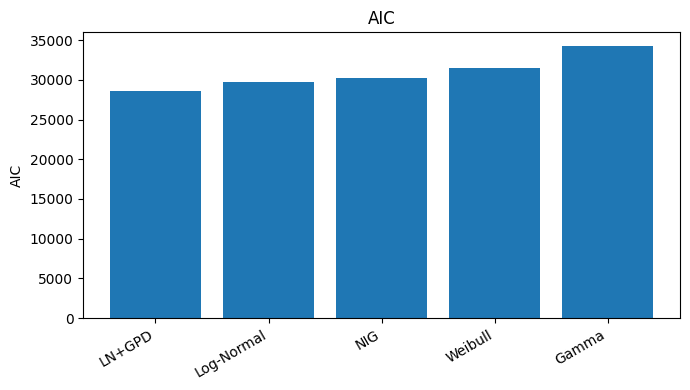

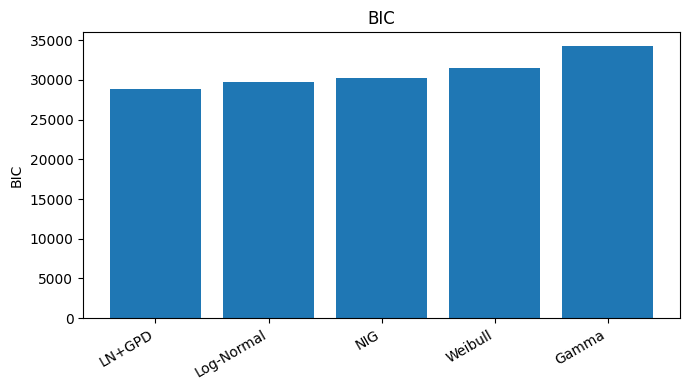

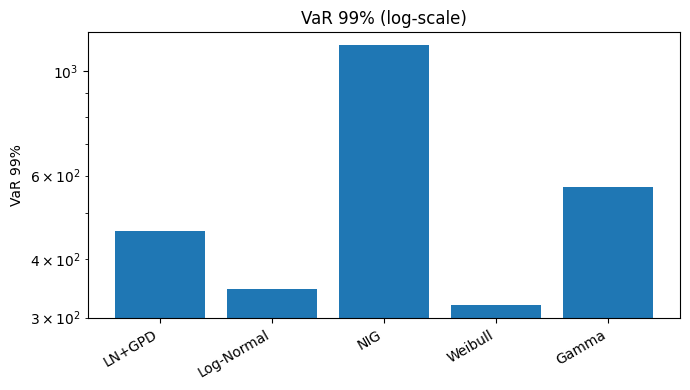

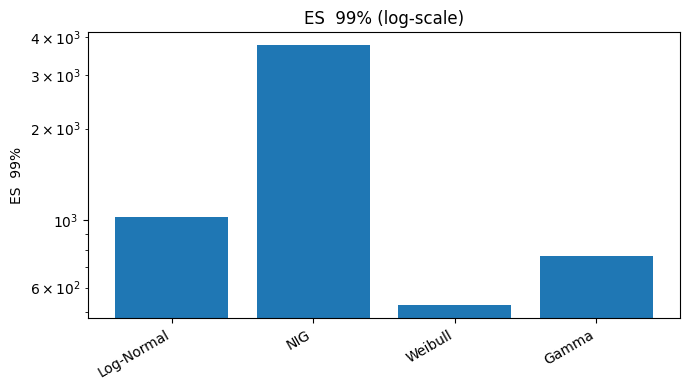

In [ ]:
# ──────────────────────────────────────────────
# 0) Tree 모델 행을 만들어 results_df 와 합치기
# ──────────────────────────────────────────────
tree_rows = pd.DataFrame([
#    {"Distribution": "LN‑Tree",  "Log-Likelihood": ll_ln,  "k": k_ln,
#     "AIC": aic_ln,  "BIC": bic_ln,
 #    "VaR 99%": var_ln,  "ES  99%": es_ln},
    {"Distribution": "LN+GPD",   "Log-Likelihood": ll_mix, "k": k_mix,
     "AIC": aic_mix, "BIC": bic_mix,
     "VaR 99%": var_mix, "ES  99%": es_mix}
])

full_df = (pd.concat([results_df, tree_rows], ignore_index=True)
             .sort_values("AIC")
             .reset_index(drop=True))

print("\n================  Model Comparison  ================\n")
print(full_df)

# ──────────────────────────────────────────────
# 1) AIC / BIC   (로그축 X)
# ──────────────────────────────────────────────
import matplotlib.pyplot as plt

for metric in ["AIC", "BIC"]:
    plt.figure(figsize=(7,4))
    plt.bar(full_df["Distribution"], full_df[metric])
    plt.title(f"{metric}")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

# ──────────────────────────────────────────────
# 2) VaR / ES   (log‑scale로 값 차이를 보기 좋게)
# ──────────────────────────────────────────────
for metric in ["VaR 99%", "ES  99%"]:
    y = pd.to_numeric(full_df[metric], errors="coerce").to_numpy(dtype=float)
    y_plot = np.where(np.isfinite(y) & (y > 0), y, np.nan)  # 🔧 inf/<=0 → NaN
    plt.figure(figsize=(7,4))
    plt.bar(full_df["Distribution"], y_plot)
    plt.yscale("log")
    plt.title(f"{metric} (log-scale)")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()



In [ ]:
import pickle

# --- __main__ 블록 마지막에 추가 ---
save_path = '/content/drive/MyDrive/Operational_risk/'
# 1) 저장할 객체들 모으기
output = {
    # Bulk 트리
    'l1_bulk_tree' : l1_bulk_tree,
    'l2_bulk_tree' : l2_bulk_tree,
    # Tail 트리
    'gpd_raw_tree' : gpd_tail_tree_raw,
    'gpd_pruned_tree' : gpd_tail_tree_pruned,
    # 데이터
    'X_bulk'       : X_bulk,
    'y_bulk'       : y_bulk,
    'X_tail'       : X_tail,
    'y_tail'       : y_tail,
    'X_all_data'   : X_all_data,
    'y_all_data'   : y_all_data,
    'df_model_ready':df_model_ready,
    # (선택) 피처 이름
    'feature_names': feature_names_list,
    # (선택) 임계값
    'u_threshold'  : u_threshold
}

# 2) 피클 파일로 저장
with open(save_path + 'EPU_Category_Banking.pkl', 'wb') as f:
    pickle.dump(output, f)



In [ ]:
import pickle

# --- __main__ 블록 마지막에 추가 ---
save_path = '/content/drive/MyDrive/Operational_risk/'
# 1) 저장할 객체들 모으기
output = {
    # Bulk 트리
    'l1_bulk_tree' : l1_bulk_tree,
    'l2_bulk_tree' : l2_bulk_tree,
    # Tail 트리
    'gpd_raw_tree' : gpd_tail_tree_raw,
    'gpd_pruned_tree' : gpd_tail_tree_pruned,
    # 데이터
    'X_bulk'       : X_bulk,
    'y_bulk'       : y_bulk,
    'X_tail'       : X_tail,
    'y_tail'       : y_tail,
    'X_all_data'   : X_all_data,
    'y_all_data'   : y_all_data,
    'df_model_ready':df_model_ready,
    # (선택) 피처 이름
    'feature_names': feature_names_list,
    # (선택) 임계값
    'u_threshold'  : u_threshold
}

# 2) 피클 파일로 저장
with open(save_path + 'EPU_Category_Banking.pkl', 'wb') as f:
    pickle.dump(output, f)



In [ ]:
import pickle

# --- __main__ 블록 마지막에 추가 ---
save_path = '/content/drive/MyDrive/Operational_risk/'
# 1) 저장할 객체들 모으기
output = {
    # Bulk 트리
    'l1_bulk_tree' : l1_bulk_tree,
    'l2_bulk_tree' : l2_bulk_tree,
    # Tail 트리
    'gpd_raw_tree' : gpd_tail_tree_raw,
    'gpd_pruned_tree' : gpd_tail_tree_pruned,
    # 데이터
    'X_bulk'       : X_bulk,
    'y_bulk'       : y_bulk,
    'X_tail'       : X_tail,
    'y_tail'       : y_tail,
    'X_all_data'   : X_all_data,
    'y_all_data'   : y_all_data,
    'df_model_ready':df_model_ready,
    # (선택) 피처 이름
    'feature_names': feature_names_list,
    # (선택) 임계값
    'u_threshold'  : u_threshold
}

# 2) 피클 파일로 저장
with open(save_path + 'EPU_Category_insurance.pkl', 'wb') as f:
    pickle.dump(output, f)

